# Simulations Results
From: Entanglement generation and characterization using metamaterial resonators

Alessandro S. Santana

In [1]:
%matplotlib inline
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MaxNLocator, FixedLocator, FixedFormatter, FuncFormatter
from matplotlib.gridspec import GridSpec
from numpy import *
from qutip import *
from IPython.display import Image
from numpy.linalg import *
import multiprocessing  
from multiprocessing import Pool, cpu_count
import scipy.constants as sc
import time
import datetime
import os
import glob
from matplotlib import cm
from matplotlib import gridspec
from matplotlib.lines import Line2D
import matplotlib as mpl

ls = 30.0   # tick label size
fs = 30.0   # axis label size

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    # ===== Fonts =====
    "font.size": 30,
    "axes.labelsize": fs,
    "axes.titlesize": 30,
    # ===== Lines =====
    "lines.linewidth": 2.5,
    # ===== Ticks =====
    "xtick.labelsize": ls,
    "ytick.labelsize": ls,
    "xtick.direction": "in",  
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    # Tick size 
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    # ===== Axes =====
    "axes.linewidth": 2.5,
    "axes.grid": False, 
    # ===== Legend =====
    "legend.frameon": False,
    "legend.fontsize": 15,
    # ===== Figure =====
    "figure.figsize": (16, 6),
    "figure.dpi": 100
})

saveResults = True

def load_result(folder):
    #files = glob.glob(os.path.join(folder, "Results_*.npy"))
    files = glob.glob(os.path.join(folder, "*.npy"))
    
    if not files:
        raise FileNotFoundError("No result files found.")
    
    # Sort by modification time (newest first)
    files_sorted = sorted(files, key=os.path.getmtime, reverse=True)
    
    print("\nAvailable files:")
    for i, f in enumerate(files_sorted):
        print(f"[{i}] {os.path.basename(f)}")
    
    choice = input("\nLoad most recent file? (y/n): ").strip().lower()

    if choice in ['', 'y']:
        selected_file = files_sorted[0]
    else:
        idx = int(input("Enter file index: "))
        if idx < 0 or idx >= len(files_sorted):
            raise ValueError("Invalid index.")
        selected_file = files_sorted[idx]
    
    print(f"\nLoading: {selected_file}\n")
    
    return load(selected_file, allow_pickle=True)

def save_figure(fig, folder, name, formats=("pdf", "png"), time_stamp=True, dpi=300):
    
    choice = input("\nSave figure? (y/N): ").strip().lower()
    if choice not in ['y', 'yes']:
        print("Figure not saved.")
        return
    
    os.makedirs(folder, exist_ok=True)
    
    if time_stamp:
        time_str = datetime.datetime.now().strftime("_[%Y-%m-%d]_[%Hh%Mm]")
    else:
        time_str = ""
    
    base_path = os.path.join(folder, name + time_str)
    
    saved_files = []
    
    for fmt in formats:
        fmt = fmt.lower()
        
        if fmt == "png":
            fig.savefig(base_path + ".png", dpi=dpi, bbox_inches='tight')
        else:
            fig.savefig(base_path + f".{fmt}", bbox_inches='tight')
        
        saved_files.append(base_path + f".{fmt}")
    
    print("\nSaved:")
    for f in saved_files:
        print(f)

## Simulation 1

In [2]:
# Results_[2026-07-06]_[23h47m].npy
folder_1 = "Results\Sim1_DeltaA_vs_ga"

data_1 = load_result(folder_1)

time_index = datetime.datetime.now().strftime("_[%Y-%m-%d]_[%Hh%Mm]")
date_index = datetime.datetime.now().strftime("_[%Y-%m-%d]")

x_list_1 = data_1[0]    # Delta_a_list
y_list_1 = data_1[1]    # galist
rho_grid = data_1[2]    # rho_ss grid

N_a = data_1[3]         # Fock dimension Mode 1/A
N_b = data_1[4]         # Fock dimension Mode 2/B
N_r = data_1[5]         # Fock dimension Mechanical Mode/R
wr = data_1[6]          # Mechanical Frequency

computation_time = data_1[7]

print(f"Computation time: {computation_time:.2f} seconds")
print(f"Computation time: {computation_time/60:.2f} minutes")
print(f"Computation time: {computation_time/3600:.2f} hours")

##############################################################
g2 = 10

shift_n0 = [-(k**2)/(wr) for k in y_list_1]
shift_n1 = [(-(k**2)/(wr))-((2* k * g2)/(wr)) for k in y_list_1]
shift_n2 = array([-(1 / wr) * (k**2 + 4*k*g2) for k in y_list_1])

##############################################################
x0 =  x_list_1[0].round()
xf = x_list_1[-1].round()
y0 =  y_list_1[0].round()
yf = y_list_1[-1].round()
delta_x = xf - x0
delta_y = yf - y0
Ny = len(y_list_1)
Nx = len(x_list_1)
##############################################################
a = tensor(destroy(N_a), qeye(N_b), qeye(N_r))
b = tensor(qeye(N_a), destroy(N_b), qeye(N_r))
r = tensor(qeye(N_a), qeye(N_b), destroy(N_r))

Na = a.dag() * a
Nb = b.dag() * b
Nr = r.dag() * r

fieldAmp_A1 = empty((Ny, Nx), dtype=float)

Re_A1 = empty((Ny, Nx), dtype=float)
Im_A1 = empty((Ny, Nx), dtype=float)
for i in range(Ny):
    for j in range(Nx):
        fieldAmp_A1[i, j] = abs(expect(a, rho_grid[i, j]))
        Re_A1[i, j] = real(expect(a, rho_grid[i, j]))
        Im_A1[i, j] = imag(expect(a, rho_grid[i, j]))


Available files:
[0] Results_[2026-07-17]_[13h47m].npy
[1] Results_[2026-07-06]_[23h47m].npy
[2] Results_[2026-07-06]_[18h22m].npy
[3] Results_[2026-07-06]_[11h50m].npy
[4] Results_[2026-07-06]_[11h49m].npy
[5] Results_[2026-07-06]_[11h48m].npy
[6] Results_[2026-07-06]_[11h43m].npy
[7] Results_[2026-07-06]_[10h05m].npy
[8] Results_[2026-07-06]_[08h34m].npy
[9] Results_[2026-07-06]_[08h30m].npy
[10] Results_[2026-07-06]_[08h26m].npy
[11] Results_[2026-07-06]_[08h24m].npy
[12] Results_[2026-07-06]_[08h22m].npy
[13] Results_[2026-07-06]_[08h20m].npy
[14] Results_[2026-07-06]_[07h09m].npy
[15] Results_[2026-07-05]_[23h45m].npy
[16] Results_[2026-07-05]_[23h40m].npy
[17] Results_[2026-07-05]_[14h38m].npy
[18] Results_[2026-07-05]_[14h29m].npy
[19] Results_[2026-07-05]_[13h30m].npy

Loading: Results\Sim1_DeltaA_vs_ga\Results_[2026-07-06]_[23h47m].npy

Computation time: 7486.99 seconds
Computation time: 124.78 minutes
Computation time: 2.08 hours


### 1) Average field amplitude $\langle\hat{a}_1\rangle_{ss}$ for cavity 1 


Saved:
Thesis_Figures\chap4_sim1_averagefield_amp_ss_part1.pdf


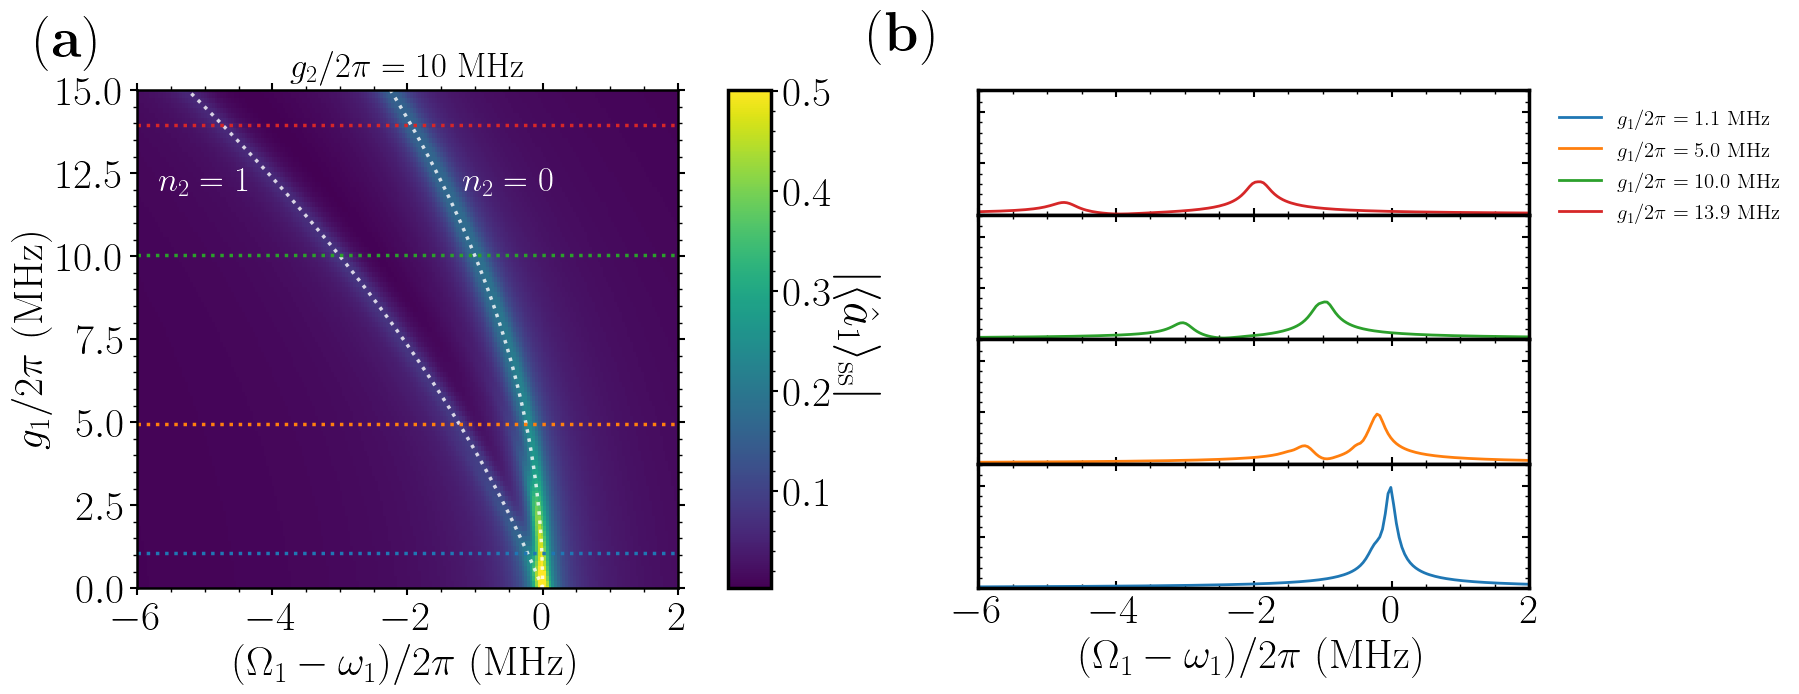

In [3]:
fig = plt.figure(figsize=(16, 6))

gs = fig.add_gridspec(
    1, 2,
    width_ratios=[1.15, 1],
    wspace=0.35)               # Plots distance

ax0 = fig.add_subplot(gs[0, 0])

gs_right = gs[0, 1].subgridspec(
    4, 1,
    hspace=0.0)                 # Stacked plots vertical dsitance

axes_right = []
for i in range(4):
    if i == 0:
        ax = fig.add_subplot(gs_right[i, 0])
    else:
        ax = fig.add_subplot(gs_right[i, 0], sharex=axes_right[0])
    axes_right.append(ax)

##############################################################
# ---- Heatmap ----
##############################################################
nrm = mpl.colors.Normalize(fieldAmp_A1.min(), 0.8*fieldAmp_A1.max())

im1 = ax0.pcolormesh(x_list_1, y_list_1, fieldAmp_A1,cmap=cm.viridis,norm=nrm,shading='auto')

ax0.set_xlabel(r'$(\Omega_1 - \omega_1)/2\pi$ (MHz)')
ax0.set_ylabel(r'$g_1/2\pi$ (MHz)')
ax0.set_title(r'$g_2/2\pi = 10$ MHz', fontsize=25, pad=10)

ax0.xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
ax0.yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

ax0.set_xlim(x0, xf)
ax0.set_ylim(y0, yf)

ax0.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax0.yaxis.set_major_locator(MaxNLocator(nbins=6))

ax0.tick_params(axis='both', which='both', direction='out')

for spine in ax0.spines.values():
    spine.set_linewidth(1.8)

##### Colorbar settings #####
divider = make_axes_locatable(ax0)

cax = divider.append_axes(
    "right",
    size="8%",  # <-- width of colorbar
    pad=0.5     # <-- distance to plot
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label(r'$\vert\langle \hat{a}_1\rangle_{\rm ss}\vert$',rotation=270,labelpad=35, fontsize=35)

cbar.ax.tick_params(which='both', direction='out')

##### Overlays #####
ax0.text(-5.7, 12, r"$n_2 = 1$", color='white', fontsize=25)
ax0.text(-1.2, 12, r"$n_2 = 0$", color='white', fontsize=25)

ax0.plot(shift_n0, y_list_1, ':', color='white', lw=2.5, alpha=0.8)
ax0.plot(shift_n1, y_list_1, ':', color='white', lw=2.5, alpha=0.8)

cut_values = [1.0, 5.0, 10.0, 14.0] # MHz

cut_indices = [argmin(abs(array(y_list_1) - value)) for value in cut_values]

cut_colors = ['C0', 'C1', 'C2', 'C3']

##############################################################
# Sort cuts by actual selected g1 value
##############################################################
cut_info = sorted([(y_list_1[i], i, c) for i, c in zip(cut_indices, cut_colors)],
                  key=lambda x: x[0])

##############################################################
# Horizontal lines on heatmap
##############################################################
for g_val, i, c in cut_info:
    ax0.axhline(y=g_val, color=c, linestyle=':')

##############################################################
# ---- Right stacked cut plots ----
##############################################################
start = 0
end   = round(fieldAmp_A1.max(), 1)

legend_handles = []
legend_labels  = []

for ax, (g_val, i, c) in zip(axes_right[::-1], cut_info):

    ax.plot(x_list_1, fieldAmp_A1[i],color=c,lw=2)

    ax.set_xlim(x0, xf)
    ax.set_ylim(0, 1.01*end)

    ax.xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))

    ax.tick_params(axis='both', which='both',direction='in',top=True,right=True)

    ax.tick_params(axis='y', labelleft=False)

    if ax is not axes_right[-1]:
        ax.tick_params(axis='x', labelbottom=False)

    for spine in ax.spines.values():
        spine.set_linewidth(2.5) # Frame thickness

    legend_handles.append(Line2D([0], [0], color=c, lw=2))
    legend_labels.append(r'$g_1/2\pi = %.1f$ MHz' % g_val)


axes_right[-1].set_xlabel(r'$(\Omega_1 - \omega_1)/2\pi$ (MHz)')

axes_right[0].legend(legend_handles, legend_labels,
                     frameon=False,loc='upper left', bbox_to_anchor=(1.02, 1))

##############################################################
# Overlay labels
##############################################################
ax0.text(-0.19,1.15,r'$\mathbf{(a)}$',transform=ax0.transAxes,ha='left',va='top',fontsize=40,color='black')

axes_right[0].text(-0.20,1.65,r'$\mathbf{(b)}$',transform=axes_right[0].transAxes,ha='left',va='top',fontsize=40,color='black')

##############################################################
# ---- Global spacing ----
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.95
)

save_figure(fig, "Thesis_Figures", "chap4_sim1_averagefield_amp_ss_part1", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

### 2) Real and Imaginary parts of the average field $\langle \hat a_1 \rangle$ for cavity 1


Saved:
Thesis_Figures\chap4_sim1_averagefield_amp_ss_part2.pdf


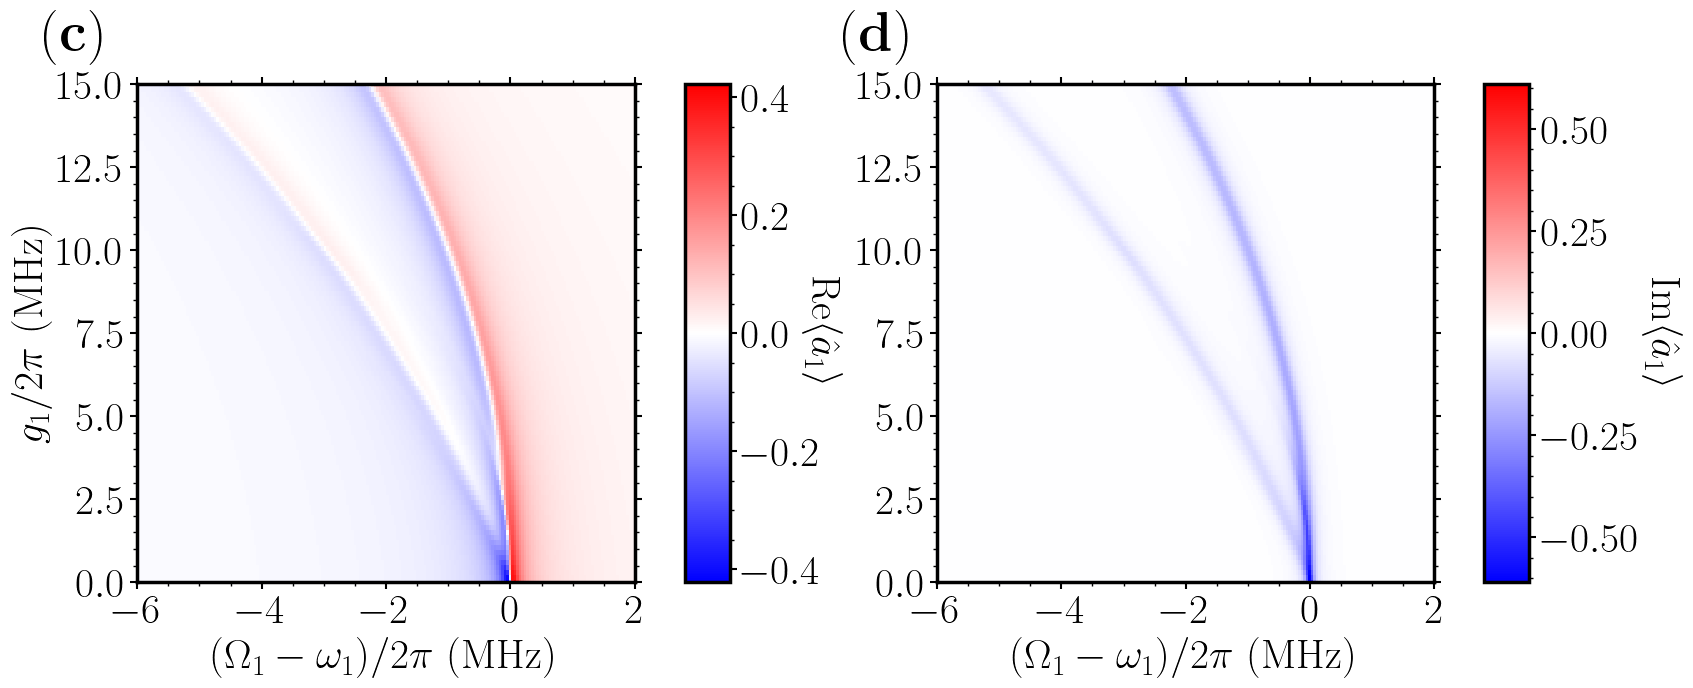

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
##############################################################
# ---- Heatmap ----
##############################################################
re_a1_abs_max = 0.99 * max(abs(Re_A1.min()),abs(Re_A1.max()))
nrm1 = mpl.colors.Normalize(-re_a1_abs_max, re_a1_abs_max)

im1 = axes[0].pcolormesh(x_list_1, y_list_1, Re_A1,
                         cmap=cm.bwr,
                         norm=nrm1,
                         shading='auto')

axes[0].set_xlabel(r'$(\Omega_1 - \omega_1)/2\pi$ (MHz)')
axes[0].set_ylabel(r'$g_1/2\pi$ (MHz)')

axes[0].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[0].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[0].set_xlim(x0, xf)
axes[0].set_ylim(y0, yf)

axes[0].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=6))

axes[0].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[0])

cax = divider.append_axes(
    "right",
    size="9%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label(r'Re$\langle \hat{a}_1\rangle$',
               rotation=270,
               labelpad=15)

cbar.ax.tick_params(which='both', direction='out')

##############################################################
# ---- Heatmap 2 ----
##############################################################
im_a1_abs_max = 0.99 * max(abs(Im_A1.min()),abs(Im_A1.max()))
nrm2 = mpl.colors.Normalize(-im_a1_abs_max, im_a1_abs_max)

im2 = axes[1].pcolormesh(x_list_1, y_list_1, Im_A1,
                         cmap=cm.bwr,
                         norm=nrm2,
                         shading='auto')

axes[1].set_xlabel(r'$(\Omega_1 - \omega_1)/2\pi$ (MHz)')

axes[1].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[1].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[1].set_xlim(x0, xf)
axes[1].set_ylim(y0, yf)

axes[1].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=6))

axes[1].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[1])

cax = divider.append_axes(
    "right",
    size="9%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im2, cax=cax)

cbar.set_label(r'Im$ \langle \hat{a}_1\rangle $',
               rotation=270,
               labelpad=30)

cbar.ax.tick_params(which='both', direction='out')

#############################################################
# Panel labels
#############################################################
panel_labels = [r'$\mathbf{(c)}$',r'$\mathbf{(d)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.19,
        1.15,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )
##############################################################
# ---- Global spacing ----
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.95,
    wspace=0.35   # spacing between the TWO plots only
)

save_figure(fig, "Thesis_Figures", "chap4_sim1_averagefield_amp_ss_part2", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

### 3) Average photon numbers $\langle \hat{N}_k \rangle_{ss} $ for cavity 1 and 2

In [5]:
mean_N1 = empty((Ny, Nx), dtype=float)
mean_N2 = empty((Ny, Nx), dtype=float)

for i in range(Ny):
    for j in range(Nx):
        mean_N1[i, j] = abs(expect(a.dag() * a, rho_grid[i, j]))
        mean_N2[i, j] = abs(expect(b.dag() * b, rho_grid[i, j]))

<N2> along n2 = 0 branch: 0.1812 ± 0.0164
<N2> along n2 = 1 branch: 0.2601 ± 0.0028

Saved:
Thesis_Figures\chap4_sim1_average_number_photons_ss.pdf


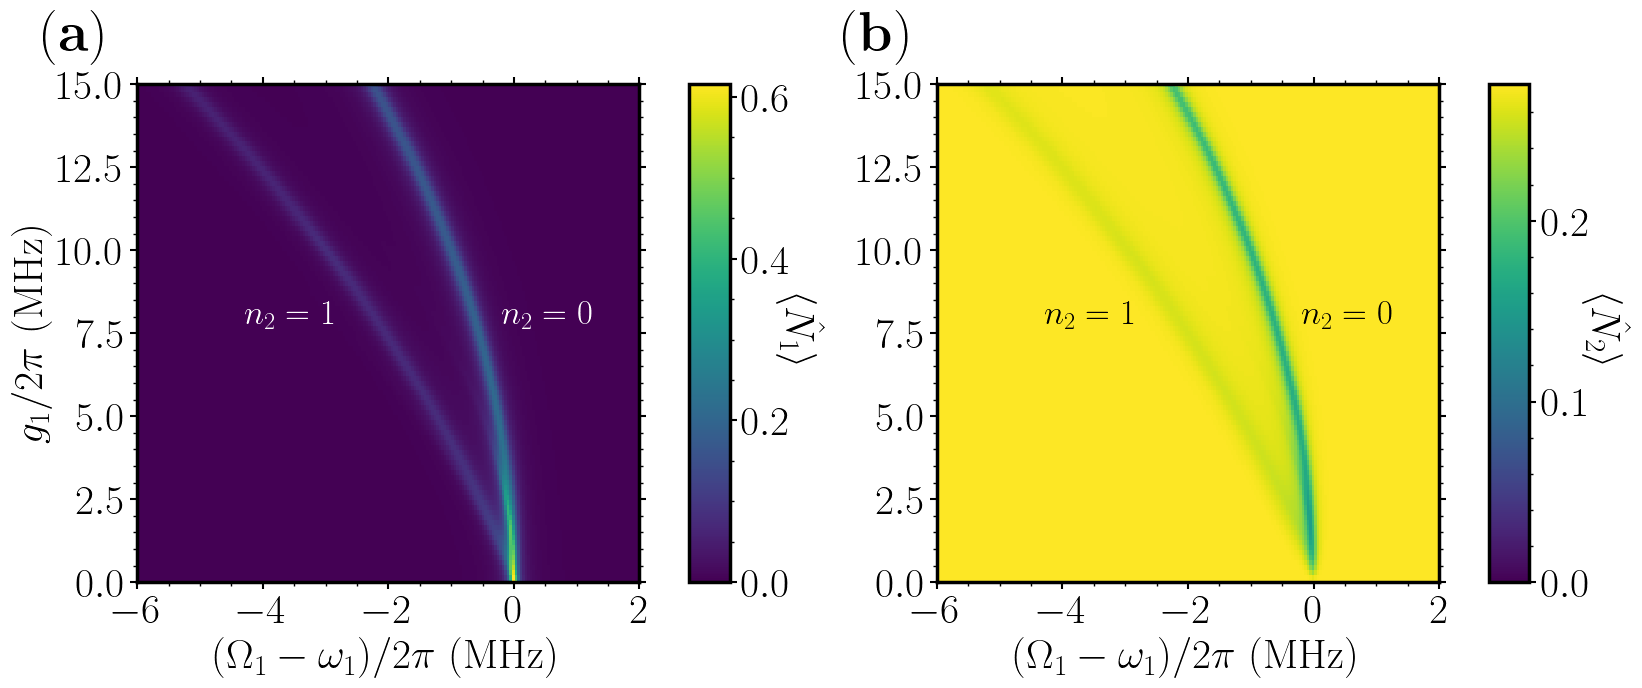

In [11]:
##############################################################
# ---- <N2> along the n2 = 0 resonance line ----
##############################################################
N2_along_n0 = empty(Ny, dtype=float)

for i in range(Ny):

    j = argmin(
        abs(array(x_list_1) - shift_n0[i])
    )

    N2_along_n0[i] = mean_N2[i, j]

##############################################################
# ---- <N2> along the n2 = 1 resonance line ----
##############################################################
N2_along_n1 = empty(Ny, dtype=float)

for i in range(Ny):

    j = argmin(
        abs(array(x_list_1) - shift_n1[i])
    )

    N2_along_n1[i] = mean_N2[i, j]

##############################################################
# ---- Mean values and variation ----
##############################################################
print(
    r"<N2> along n2 = 0 branch: "
    f"{mean(N2_along_n0):.4f} ± {std(N2_along_n0):.4f}"
)

print(
    r"<N2> along n2 = 1 branch: "
    f"{mean(N2_along_n1):.4f} ± {std(N2_along_n1):.4f}"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
##############################################################
# ---- Heatmap ----
##############################################################
nrm1 = mpl.colors.Normalize(0, mean_N1.max())

im1 = axes[0].pcolormesh(x_list_1, y_list_1, mean_N1,
                         cmap=cm.viridis,
                         norm=nrm1,
                         shading='auto')

axes[0].set_xlabel(r'$(\Omega_1 - \omega_1)/2\pi$ (MHz)')
axes[0].set_ylabel(r'$g_1/2\pi$ (MHz)')

axes[0].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[0].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[0].set_xlim(x0, xf)
axes[0].set_ylim(y0, yf)

axes[0].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=6))

axes[0].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[0])

cax = divider.append_axes(
    "right",
    size="8%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label(r'$\langle \hat N_1\rangle$',
               rotation=270,
               labelpad=25)

cbar.ax.tick_params(which='both', direction='out')

##############################################################
# ---- Heatmap 2 ----
##############################################################
nrm2 = mpl.colors.Normalize(0, mean_N2.max())

im2 = axes[1].pcolormesh(x_list_1, y_list_1, mean_N2,
                         cmap=cm.viridis,
                         norm=nrm2,
                         shading='auto')

axes[1].set_xlabel(r'$(\Omega_1 - \omega_1)/2\pi$ (MHz)')

axes[1].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[1].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[1].set_xlim(x0, xf)
axes[1].set_ylim(y0, yf)

axes[1].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=6))

axes[1].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[1])

cax = divider.append_axes(
    "right",
    size="8%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im2, cax=cax)

cbar.set_label(r'$\langle \hat N_2\rangle$',
               rotation=270,
               labelpad=30)

cbar.ax.tick_params(which='both', direction='out')

# Overlays
axes[0].text(-4.3, 7.8, r"$n_2 = 1$", color='white', fontsize=25)
axes[0].text(-0.2, 7.8, r"$n_2 = 0$", color='white', fontsize=25)
axes[1].text(-4.3, 7.8, r"$n_2 = 1$", color='black', fontsize=25)
axes[1].text(-0.2, 7.8, r"$n_2 = 0$", color='black', fontsize=25)
#############################################################
# Panel labels
#############################################################
panel_labels = [r'$\mathbf{(a)}$',r'$\mathbf{(b)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.19,
        1.15,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )
##############################################################
# ---- Global spacing ----
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.95,
    wspace=0.35   # spacing between the TWO plots only
)

save_figure(fig, "Thesis_Figures", "chap4_sim1_average_number_photons_ss", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

#### 3.1) Alternate version

Figure not saved.


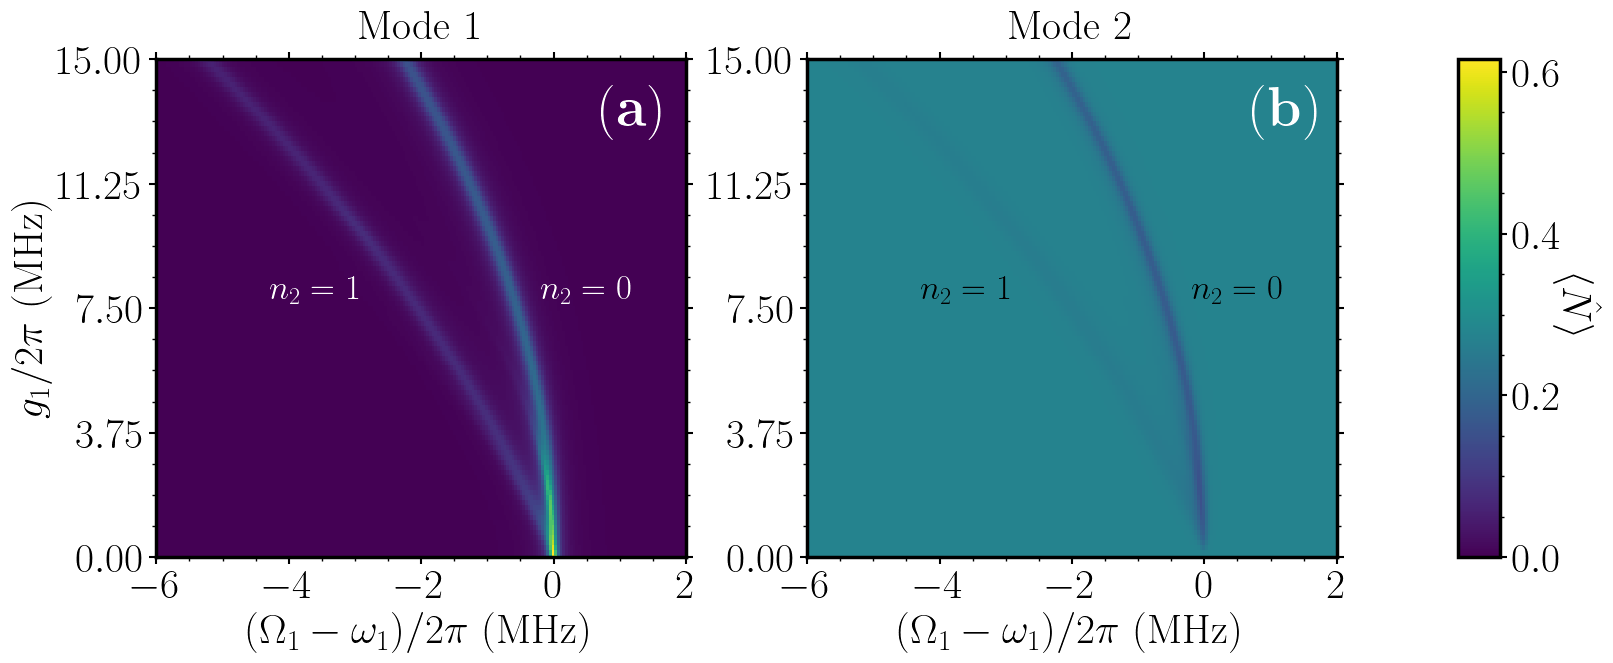

In [12]:
# ---- Figure + GridSpec ----
fig = plt.figure(figsize=(16, 6))

gs = gridspec.GridSpec(
    1, 3,
    width_ratios=[1, 1, 0.08],  
    wspace=0.33
)

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
cax = fig.add_subplot(gs[2])  # colorbar axis

##############################################################
# ---- Shared normalization ----
vmin = 0
vmax = max(mean_N1.max(), mean_N2.max())
nrm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

##############################################################
# ---- First plot ----
im1 = ax0.pcolormesh(
    x_list_1, y_list_1, mean_N1,
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax0.set_xlabel(r'$(\Omega_1 - \omega_1)/2\pi$ (MHz)')
ax0.set_ylabel(r'$g_1/2\pi$ (MHz)')
ax0.set_xlim(x0, xf)
ax0.set_ylim(y0, yf)
ax0.xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
ax0.yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))
ax0.set_title(r'Mode 1', pad=15)

ax0.tick_params(axis='both', which='both', direction='out')

# overlays
ax0.text(-7.5, 12.5, r"$\mathbf{a}$", color='white', fontsize=50)
ax0.text(-4.3, 7.8, r"$n_2 = 1$", color='white', fontsize=25)
ax0.text(-0.2, 7.8, r"$n_2 = 0$", color='white', fontsize=25)

##############################################################
# ---- Second plot ----
im2 = ax1.pcolormesh(
    x_list_1, y_list_1, mean_N2,
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax1.set_xlabel(r'$(\Omega_1 - \omega_1)/2\pi$ (MHz)')
ax1.set_xlim(x0, xf)
ax1.set_ylim(y0, yf)
ax1.xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
ax1.yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))
ax1.set_title(r'Mode 2', pad=15)

ax1.tick_params(axis='both', which='both', direction='out')

# overlays
ax0.text(0.7, 13., r"$\mathbf{(a)}$", color='white', fontsize=40)
ax1.text(0.7, 13., r"$\mathbf{(b)}$", color='white', fontsize=40)
ax1.text(-4.3, 7.8, r"$n_2 = 1$", color='black', fontsize=25)
ax1.text(-0.2, 7.8, r"$n_2 = 0$", color='black', fontsize=25)

##############################################################
# ---- Colorbar ----
cbar = fig.colorbar(im1, cax=cax)

cbar.ax.tick_params(labelsize=ls, which='both', direction='out')
cbar.set_label(r'$\langle \hat{N} \rangle$', rotation=270, labelpad=30, fontsize=fs)

##############################################################
# ---- Final spacing tweak ----
plt.subplots_adjust(
    left=0.08,
    right=0.92,
    bottom=0.12,
    top=0.95
)
save_figure(fig, "Thesis_Figures", "chap4_sim1_average_number_photons_ss_alt", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

### Correlation Data

In [24]:
## Correlations 
N1_grid = empty((Ny, Nx), dtype=float)
N2_grid = empty((Ny, Nx), dtype=float)
N12_grid = empty((Ny, Nx), dtype=float)

C12_grid = empty((Ny, Nx), dtype=complex)
C21_grid = empty((Ny, Nx), dtype=complex)
Csym_grid = empty((Ny, Nx), dtype=float)

X1_grid = empty((Ny, Nx), dtype=complex)
X2_grid = empty((Ny, Nx), dtype=complex)

negativity_grid = empty((Ny, Nx), dtype=float)

HZ1_grid = empty((Ny, Nx), dtype=float)
HZ2_grid = empty((Ny, Nx), dtype=float)

for i in range(Ny):
    ga_i = y_list_1[i]
    for j in range(Nx):
        rho_ss = rho_grid[i, j]

        N1_grid[i, j] = real(expect(Na, rho_ss))
        N2_grid[i, j] = real(expect(Nb, rho_ss))
        N12_grid[i, j] = real(expect(Na * Nb, rho_ss))

        C12_grid[i, j] = (expect(a*Nb, rho_ss) - expect(a, rho_ss) * expect(Nb, rho_ss))

        C21_grid[i, j] = (expect(b * Na, rho_ss) - expect(b, rho_ss) * expect(Na, rho_ss))

        Csym_grid[i, j] = sqrt(abs(C12_grid[i, j])**2 + abs(C21_grid[i, j])**2)

        X1_grid[i, j] = ((2 * ga_i * g2 / wr) * C12_grid[i, j])

        X2_grid[i, j] = ((2 * ga_i * g2 / wr) * C21_grid[i, j])

        ##############################################################
        # Two-mode negativity
        ##############################################################
        rho_AB = ptrace(rho_ss, [0, 1])

        neg_aux = real(negativity(rho_AB, 0, method='eigenvalues'))

        if neg_aux > 0:
            negativity_grid[i, j] = neg_aux
        else:
            negativity_grid[i, j] = 0.0

        ##############################################################
        # Hillery-Zubairy criteria
        ##############################################################
        HZ1_grid[i, j] = real(expect(Na * Nb, rho_ss)- abs(expect(a * b.dag(), rho_ss))**2)

        HZ2_grid[i, j] = real(expect(Na, rho_ss) * expect(Nb, rho_ss) - abs(expect(a * b, rho_ss))**2)

### 5) Covariance parameters $C_{12}$, $C_{21}$


Saved:
Thesis_Figures\chap4_sim1_connected_correlations_part1.pdf


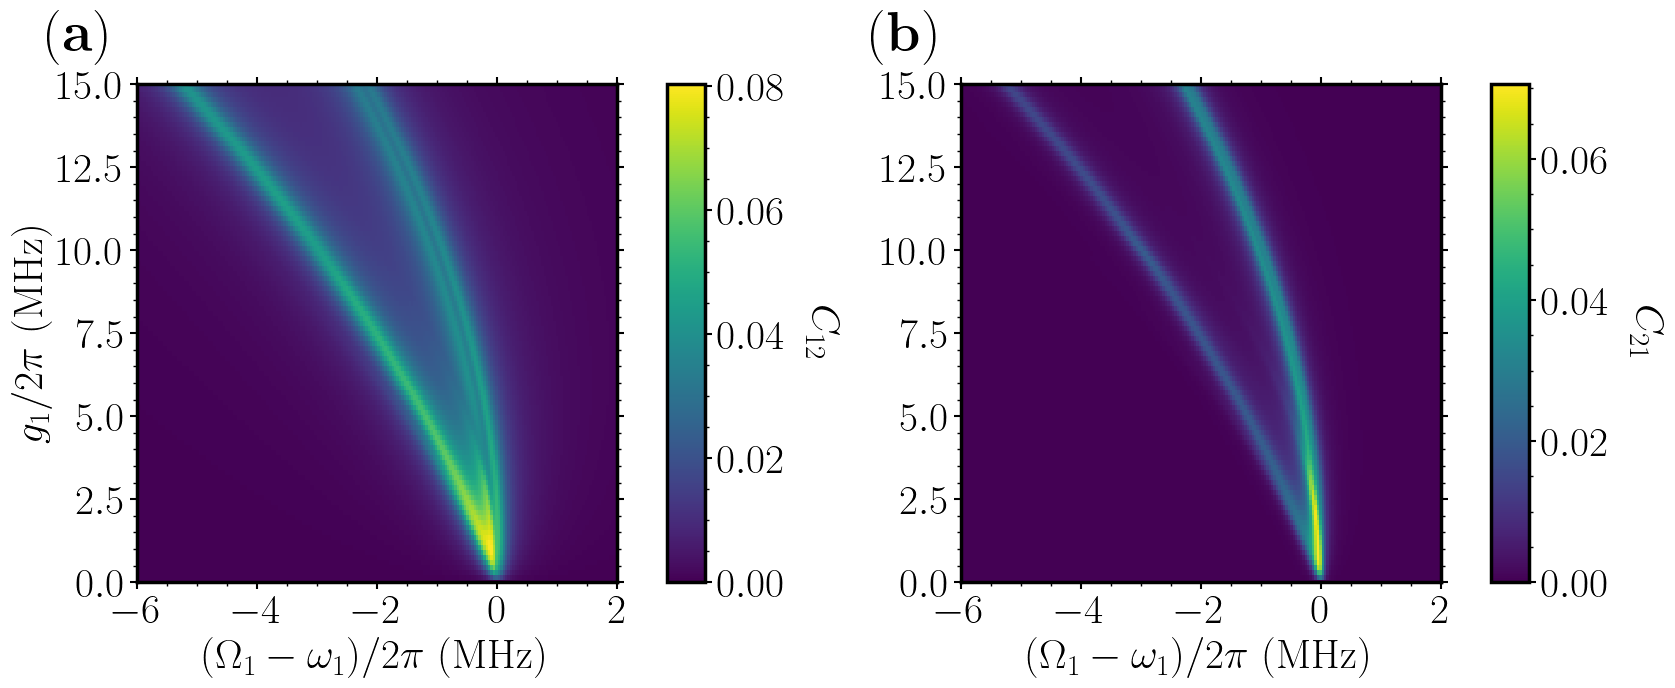

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
##############################################################
# ---- Heatmap ----
##############################################################
nrm1 = mpl.colors.Normalize(0, abs(C12_grid).max())

im1 = axes[0].pcolormesh(x_list_1, y_list_1, abs(C12_grid),
                         cmap=cm.viridis,
                         norm=nrm1,
                         shading='auto')

axes[0].set_xlabel(r'$(\Omega_1 - \omega_1)/2\pi$ (MHz)')
axes[0].set_ylabel(r'$g_1/2\pi$ (MHz)')

axes[0].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[0].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[0].set_xlim(x0, xf)
axes[0].set_ylim(y0, yf)

axes[0].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=6))

axes[0].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[0])

cax = divider.append_axes(
    "right",
    size="8%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label(r'$C_{12}$',
               rotation=270,
               labelpad=40)

cbar.ax.tick_params(which='both', direction='out')

##############################################################
# ---- Heatmap 2 ----
##############################################################
nrm2 = mpl.colors.Normalize(0, abs(C21_grid).max())

im2 = axes[1].pcolormesh(x_list_1, y_list_1, abs(C21_grid),
                         cmap=cm.viridis,
                         norm=nrm2,
                         shading='auto')

axes[1].set_xlabel(r'$(\Omega_1 - \omega_1)/2\pi$ (MHz)')

axes[1].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[1].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[1].set_xlim(x0, xf)
axes[1].set_ylim(y0, yf)

axes[1].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=6))

axes[1].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[1])

cax = divider.append_axes(
    "right",
    size="8%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im2, cax=cax)

cbar.set_label(r'$C_{21}$',
               rotation=270,
               labelpad=40)

cbar.ax.tick_params(which='both', direction='out')

#############################################################
# Panel labels
#############################################################
panel_labels = [r'$\mathbf{(a)}$',r'$\mathbf{(b)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.19,
        1.15,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )
##############################################################
# ---- Global spacing ----
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.95,
    wspace=0.45   # spacing between the TWO plots only
)

save_figure(fig, "Thesis_Figures", "chap4_sim1_connected_correlations_part1", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

### 6) Comparison between $C_\text{sym}$ and the negativity between cavity 1 and cavity 2


Saved:
Thesis_Figures\chap4_sim1_connected_correlations_part2.pdf


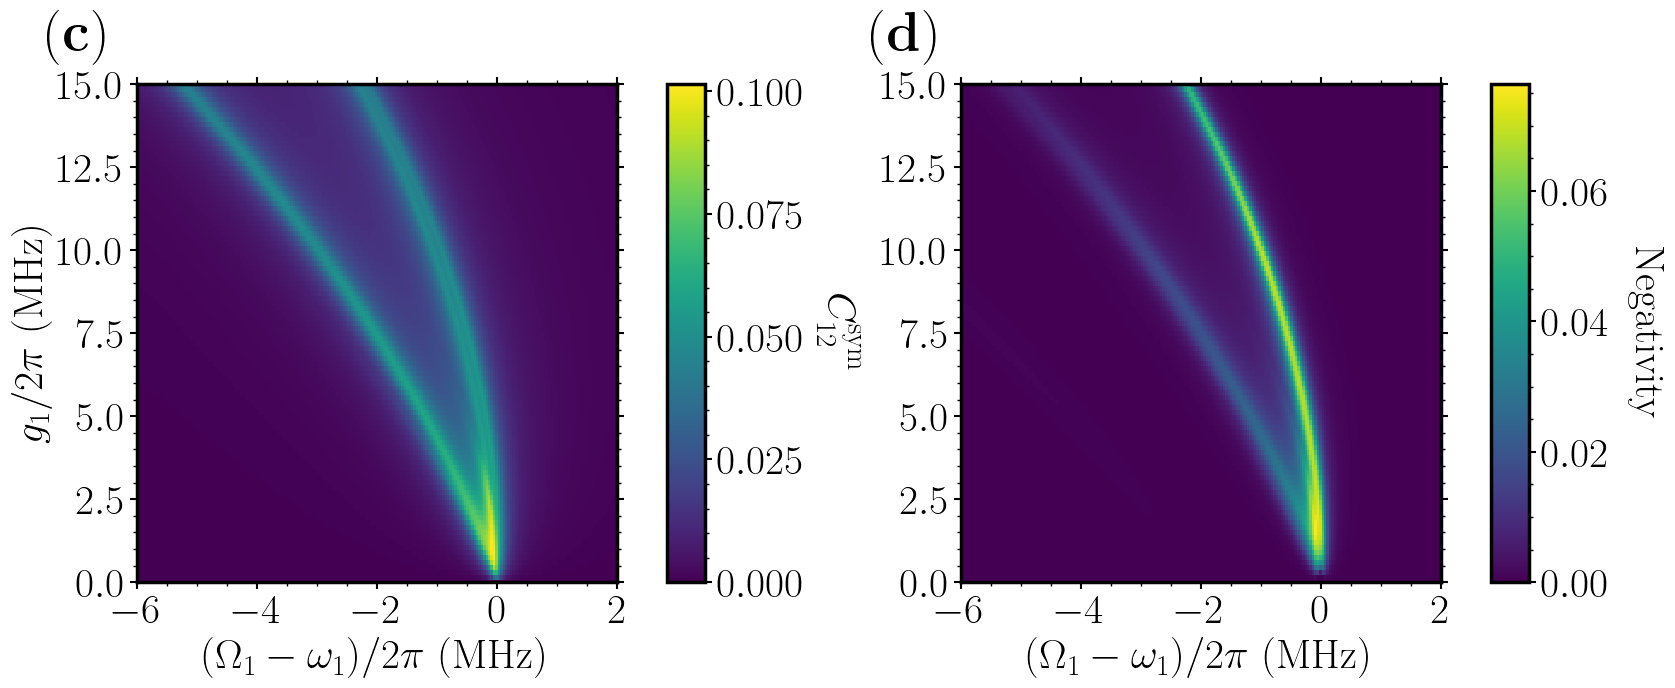

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
##############################################################
# ---- Heatmap ----
##############################################################
nrm1 = mpl.colors.Normalize(0, abs(Csym_grid).max())

im1 = axes[0].pcolormesh(x_list_1, y_list_1, abs(Csym_grid),
                         cmap=cm.viridis,
                         norm=nrm1,
                         shading='auto')

axes[0].set_xlabel(r'$(\Omega_1 - \omega_1)/2\pi$ (MHz)')
axes[0].set_ylabel(r'$g_1/2\pi$ (MHz)')

axes[0].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[0].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[0].set_xlim(x0, xf)
axes[0].set_ylim(y0, yf)

axes[0].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=6))

axes[0].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[0])

cax = divider.append_axes(
    "right",
    size="8%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label(r'$C^{\rm sym}_{12}$',
               rotation=270,
               labelpad=40)

cbar.ax.tick_params(which='both', direction='out')

##############################################################
# ---- Heatmap 2 ----
##############################################################
nrm2 = mpl.colors.Normalize(0, abs(negativity_grid).max())

im2 = axes[1].pcolormesh(x_list_1, y_list_1, abs(negativity_grid),
                         cmap=cm.viridis,
                         norm=nrm2,
                         shading='auto')

axes[1].set_xlabel(r'$(\Omega_1 - \omega_1)/2\pi$ (MHz)')

axes[1].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[1].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[1].set_xlim(x0, xf)
axes[1].set_ylim(y0, yf)

axes[1].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=6))

axes[1].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[1])

cax = divider.append_axes(
    "right",
    size="8%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im2, cax=cax)

cbar.set_label(r'Negativity',
               rotation=270,
               labelpad=40)

cbar.ax.tick_params(which='both', direction='out')

#############################################################
# Panel labels
#############################################################
panel_labels = [r'$\mathbf{(c)}$',r'$\mathbf{(d)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.19,
        1.15,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )
##############################################################
# ---- Global spacing ----
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.95,
    wspace=0.45   # spacing between the TWO plots only
)

save_figure(fig, "Thesis_Figures", "chap4_sim1_connected_correlations_part2", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

### 7) Scatterplot comparison


Saved:
Thesis_Figures\chap4_sim1_negativity_vs_covariance.pdf


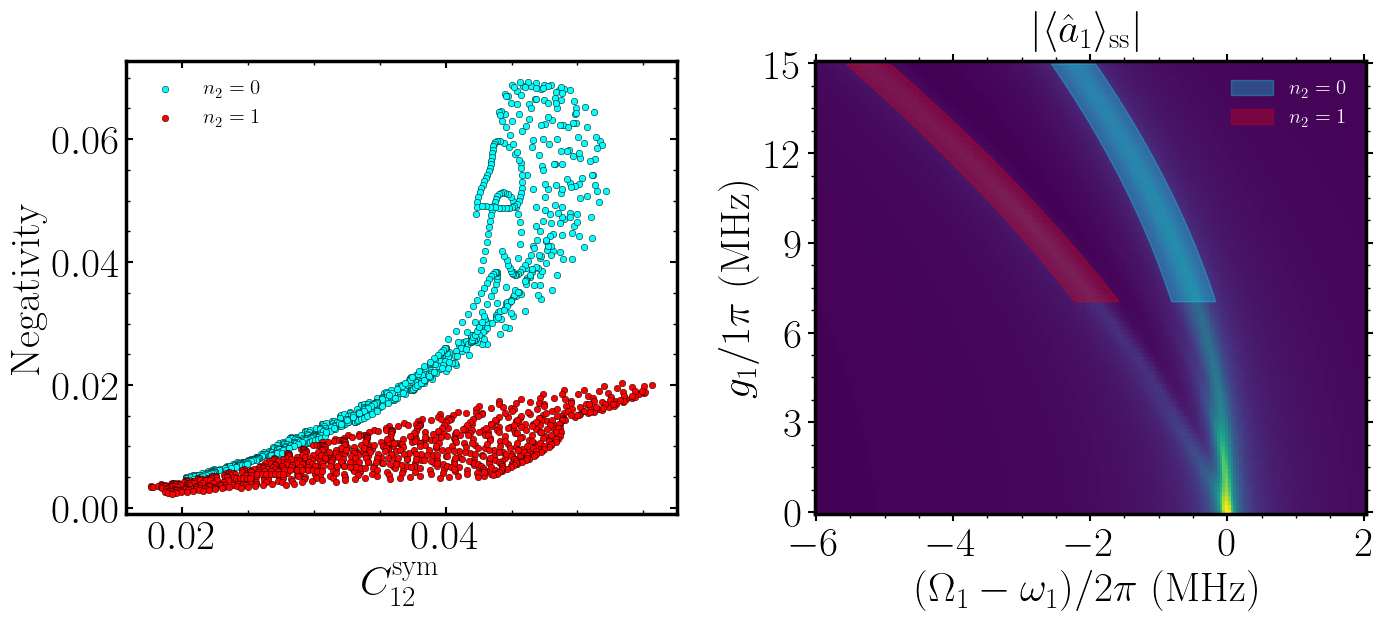

In [19]:
##############################################################
# Parameters you can tune
##############################################################
ga_min_branch = 7.0

# branch half-widths in units of x-index
branch_half_width_nb0_idx = 8
branch_half_width_nb1_idx = 8

region_alpha = 0.28

branch_point_size = 22

##############################################################
# Useful arrays
##############################################################
Delta_mesh, ga_mesh = meshgrid(x_list_1,y_list_1)
x_array = array(x_list_1)
dx = abs(x_array[1] - x_array[0])

##############################################################
# Convert branch widths from index units to MHz
##############################################################
branch_half_width_nb0 = branch_half_width_nb0_idx * dx
branch_half_width_nb1 = branch_half_width_nb1_idx * dx

##############################################################
# Predicted branch centers
#
# n_b = 0:
#   Delta_a = - g_a^2 / wr
#
# n_b = 1:
#   Delta_a = - g_a^2 / wr - 2 g_a g_b / wr
#
# (using the left-shifted branch you wanted before)
##############################################################
Delta_nb0_center = - array(y_list_1)**2 / wr
Delta_nb1_center = (- array(y_list_1)**2 / wr - 2 * array(y_list_1) * g2 / wr)

##############################################################
# Masks selecting only the branch regions
##############################################################
ga_mask = array(y_list_1) > ga_min_branch

mask_nb0 = (ga_mask[:, None] & (abs(Delta_mesh - Delta_nb0_center[:, None]) <= branch_half_width_nb0))
mask_nb1 = (ga_mask[:, None] & (abs(Delta_mesh - Delta_nb1_center[:, None]) <= branch_half_width_nb1))

##############################################################
# Optional: remove overlaps if they ever happen
##############################################################
mask_nb1 = mask_nb1 & (~mask_nb0)

##############################################################
# Keep only finite points
##############################################################
mask_nb0 = (mask_nb0 & isfinite(Csym_grid) & isfinite(negativity_grid))

mask_nb1 = (mask_nb1 & isfinite(Csym_grid) & isfinite(negativity_grid))

##############################################################
# Extract scatter-plot branch points
##############################################################
Csym_nb0 = Csym_grid[mask_nb0]
Neg_nb0  = negativity_grid[mask_nb0]

Csym_nb1 = Csym_grid[mask_nb1]
Neg_nb1  = negativity_grid[mask_nb1]

##############################################################
# Figure
##############################################################
fig, axes = plt.subplots(1,2, figsize=(16, 6))

##############################################################
# LEFT: scatter plot with ONLY the two branches
##############################################################
ax0 = axes[0]

ax0.scatter(Csym_nb0,Neg_nb0,
            s=branch_point_size,
            c='cyan',
            edgecolors='black',
            linewidths=0.35,
            label=r'$n_2=0$')

ax0.scatter(Csym_nb1,Neg_nb1,
            s=branch_point_size,
            c='red',
            edgecolors='black',
            linewidths=0.35,
            label=r'$n_2=1$')

ax0.set_xlabel(r"$C_{12}^{\mathrm{sym}}$")

ax0.set_ylabel(r"Negativity")

ax0.legend(loc='best')

##############################################################
# RIGHT: |<a1>| heatmap with branch REGIONS highlighted
##############################################################
ax1 = axes[1]

im1 = ax1.pcolormesh(x_list_1,y_list_1,abs(fieldAmp_A1),shading="auto",cmap="viridis")

##############################################################
# Highlight the n_b = 0 region (cyan band)
##############################################################
ga_region = array(y_list_1)[ga_mask]
Delta_nb0_region = Delta_nb0_center[ga_mask]

ax1.fill_betweenx(
    ga_region,
    Delta_nb0_region - branch_half_width_nb0,
    Delta_nb0_region + branch_half_width_nb0,
    color='cyan',
    alpha=region_alpha,
    label=r'$n_2=0$'
)

##############################################################
# Highlight the n_b = 1 region (red band)
##############################################################
Delta_nb1_region = Delta_nb1_center[ga_mask]

ax1.fill_betweenx(
    ga_region,
    Delta_nb1_region - branch_half_width_nb1,
    Delta_nb1_region + branch_half_width_nb1,
    color='red',
    alpha=region_alpha,
    label=r'$n_2=1$'
)

ax1.set_xlabel(r'$(\Omega_1 - \omega_1)/2\pi$ (MHz)')
ax1.set_ylabel(r'$g_1/1\pi$ (MHz)')

ax1.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax1.yaxis.set_major_locator(MaxNLocator(nbins=6))

ax1.tick_params(axis='both', which='both', direction='out')

ax1.set_title(r'$$\vert\langle \hat{a}_1\rangle_{\rm ss}\vert$$', pad=15)

leg = ax1.legend(loc='best')
for t in leg.get_texts():
    t.set_color('white')

plt.subplots_adjust(wspace=0.25)

save_figure(fig, "Thesis_Figures", "chap4_sim1_negativity_vs_covariance", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

### 8) HZ Criterias


Saved:
Thesis_Figures\chap4_sim1_HZ_criteria.pdf


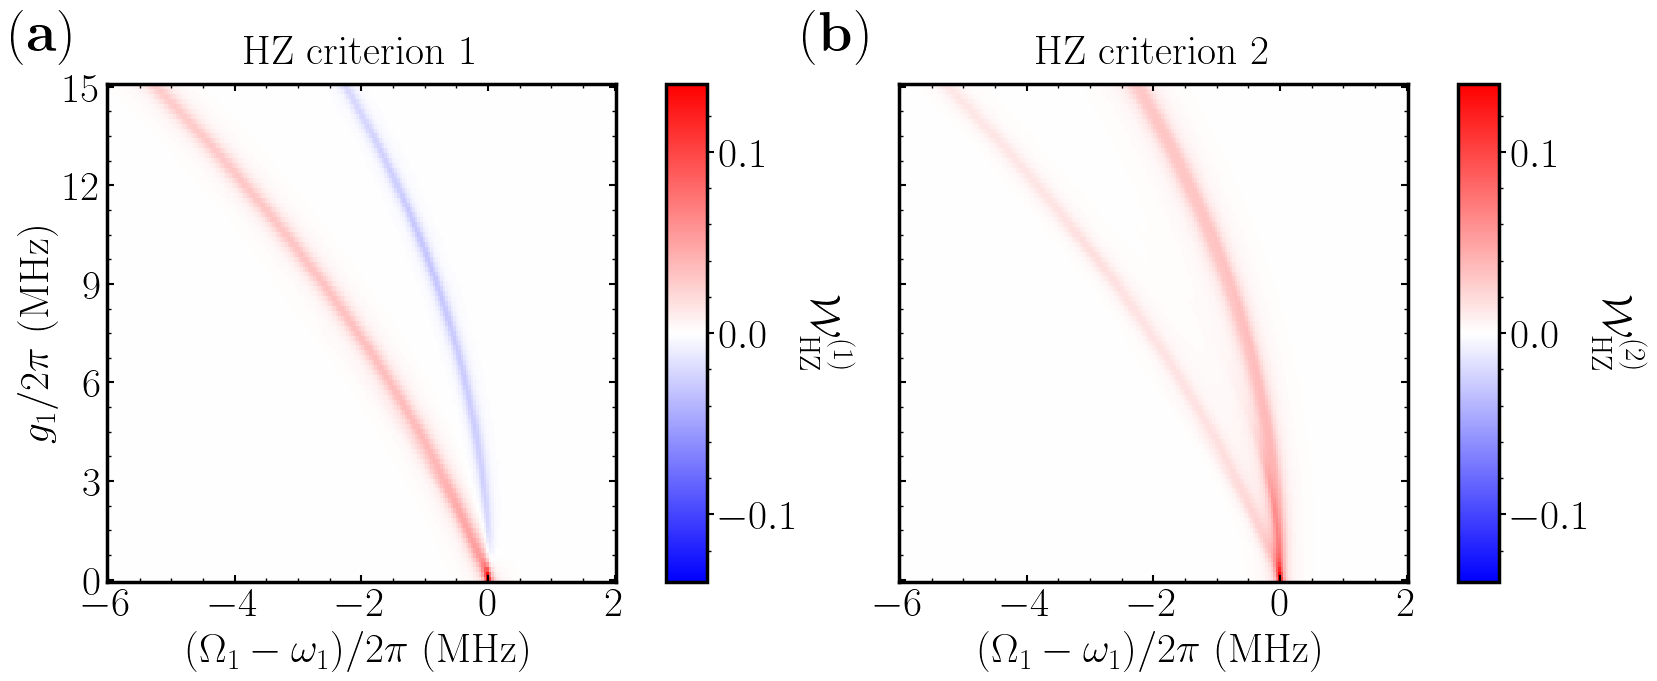

In [26]:
##############################################################
# Hillery-Zubairy criteria
##############################################################
HZ1_lim = nanmax(abs(HZ1_grid))
HZ2_lim = nanmax(abs(HZ2_grid))

if HZ1_lim == 0:
    HZ1_lim = 1

if HZ2_lim == 0:
    HZ2_lim = 1

nrm_HZ1 = mpl.colors.TwoSlopeNorm(vmin=-HZ1_lim,vcenter=0,vmax=HZ1_lim)
nrm_HZ2 = mpl.colors.TwoSlopeNorm(vmin=-HZ2_lim,vcenter=0,vmax=HZ2_lim)

fig, axes = plt.subplots(1,2,figsize=(16, 6),sharey=True)

##############################################################
# HZ criterion 1
##############################################################
im0 = axes[0].pcolormesh(x_list_1, y_list_1, HZ1_grid, shading="auto",  cmap="bwr", norm=nrm_HZ1)

axes[0].set_title(r"HZ criterion 1", pad=15)
axes[0].set_xlabel(r'$(\Omega_1 - \omega_1)/2\pi$ (MHz)')
axes[0].set_ylabel(r"$g_1/2\pi$ (MHz)")

axes[0].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=6))

axes[0].tick_params(axis='both', which='both', direction='in')

##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[0])

cax = divider.append_axes(
    "right",
    size="8%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im0, cax=cax)

cbar.set_label(r"$\mathcal{W}_{\mathrm{HZ}}^{(1)}$",
               rotation=270,
               labelpad=40)

cbar.ax.tick_params(which='both', direction='out')

##############################################################
# HZ criterion 2
##############################################################
im1 = axes[1].pcolormesh(x_list_1,y_list_1,HZ2_grid,shading="auto",cmap="bwr",norm=nrm_HZ2)

if nanmin(HZ2_grid) < 0 and nanmax(HZ2_grid) > 0:
    axes[1].contour(x_list_1,y_list_1,HZ2_grid,levels=[0],colors="black",linewidths=2)

axes[1].set_title(r"HZ criterion 2",pad=15)
axes[1].set_xlabel(r'$(\Omega_1 - \omega_1)/2\pi$ (MHz)')

axes[1].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=6))

axes[1].tick_params(axis='both', which='both', direction='in')

##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[1])

cax = divider.append_axes(
    "right",
    size="8%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label(r"$\mathcal{W}_{\mathrm{HZ}}^{(2)}$",
               rotation=270,
               labelpad=40)

cbar.ax.tick_params(which='both', direction='out')

#############################################################
# Panel labels
#############################################################
panel_labels = [r'$\mathbf{(a)}$',r'$\mathbf{(b)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.19,
        1.15,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )
    
##############################################################
# ---- Global spacing ----
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.95,
    wspace=0.32   # spacing between the TWO plots only
)

save_figure(fig, "Thesis_Figures", "chap4_sim1_HZ_criteria", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

Selected cut: ga = 13.65 MHz
Figure not saved.


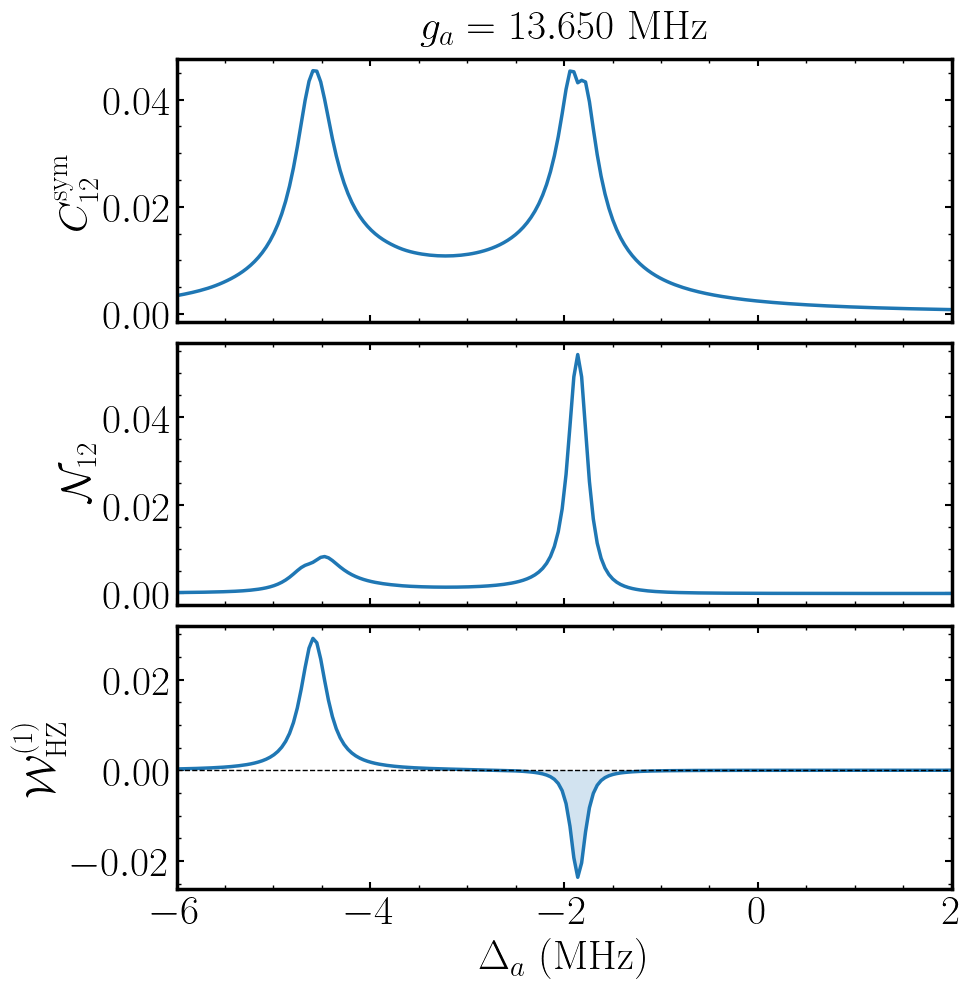

In [33]:
##############################################################
# Select the cut with the maximum negativity
##############################################################
neg_tol = 1e-8
if nanmax(negativity_grid) > neg_tol:
    i_cut, j_cut = unravel_index(nanargmax(negativity_grid),negativity_grid.shape)
else:
    i_cut, j_cut = unravel_index(nanargmax(Csym_grid),Csym_grid.shape)
i_cut = 91
ga_cut = y_list_1[i_cut]

print("Selected cut: ga =", ga_cut, "MHz")

##############################################################
# Line cuts
##############################################################
fig, axes = plt.subplots(3,1,figsize=(10, 11),sharex=True)

##############################################################
# Correlation
##############################################################
axes[0].plot(x_list_1,Csym_grid[i_cut],linestyle="-")
axes[0].set_ylabel(r"$C_{12}^{\mathrm{sym}}$")

axes[0].set_xlim(x0, xf)

axes[0].set_title(rf"$g_a={ga_cut:.3f}$ MHz",pad=15)

##############################################################
# Negativity
##############################################################
axes[1].plot(x_list_1,negativity_grid[i_cut],linestyle="-")

axes[1].set_xlim(x0, xf)

axes[1].set_ylabel(r"$\mathcal{N}_{12}$")

##############################################################
# HZ criterion
##############################################################
axes[2].plot(x_list_1,HZ1_grid[i_cut],linestyle="-")

axes[2].axhline(0,linestyle="--",linewidth=1, color="black")

axes[2].fill_between(x_list_1, HZ1_grid[i_cut],0,
                     where=HZ1_grid[i_cut] < 0,
                     alpha=0.2)

axes[2].set_xlabel(r"$\Delta_a$ (MHz)")

axes[2].set_xlim(x0, xf)

axes[2].set_ylabel(r"$\mathcal{W}_{\mathrm{HZ}}^{(1)}$")

plt.subplots_adjust(hspace=0.08)

save_figure(fig,"Thesis_Figures","Sim1_Correlation_Negativity_HZ_LineCut", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

## Simulation 2

In [108]:
folder_2 = "Results\Sim2_ga_vs_gb"

data_2 = load_result(folder_2)

time_index = datetime.datetime.now().strftime("_[%Y-%m-%d]_[%Hh%Mm]")
date_index = datetime.datetime.now().strftime("_[%Y-%m-%d]")

x_list_2 = data_2[0]    # galist
rho_grid = data_2[2]    # rho_ss grid
y_list_2 = data_2[1]    # gblist

N_a = data_2[3]         # Fock dimension Mode 1/A
N_b = data_2[4]         # Fock dimension Mode 2/B
N_r = data_2[5]         # Fock dimension Mechanical Mode/R
wr  = data_2[6]         # Mechanical Frequency

computation_time = data_2[7]

print(f"Computation time: {computation_time:.2f} seconds")
print(f"Computation time: {computation_time/60:.2f} minutes")
print(f"Computation time: {computation_time/3600:.2f} hours")

##############################################################
x0 =  x_list_2[0].round()
xf = x_list_2[-1].round()
y0 =  y_list_2[0].round()
yf = y_list_2[-1].round()
delta_x = xf - x0
delta_y = yf - y0
Ny = len(y_list_2)
Nx = len(x_list_2)
##############################################################
a = tensor(destroy(N_a), qeye(N_b), qeye(N_r))
b = tensor(qeye(N_a), destroy(N_b), qeye(N_r))
r = tensor(qeye(N_a), qeye(N_b), destroy(N_r))

Nop_A1 = a.dag()*a
Nop_A2 = b.dag()*b

g2op_A1 = a.dag()*a.dag()*a*a
g2op_A1_A2 = a.dag()*b.dag()*b*a

fieldAmp_A1 = empty((Ny, Nx), dtype=float)
Re_A1 = empty((Ny, Nx), dtype=float)
Im_A1 = empty((Ny, Nx), dtype=float)

fieldAmp_A2 = empty((Ny, Nx), dtype=float)

g2_A1 = empty((Ny, Nx), dtype=float)
g2_A1_A2 = empty((Ny, Nx), dtype=float)

for i in range(Ny):
    for j in range(Nx):

        fieldAmp_A1[i, j] = abs(expect(a, rho_grid[i, j]))
        fieldAmp_A2[i, j] = abs(expect(b, rho_grid[i, j]))
        Re_A1[i, j] = real(expect(a, rho_grid[i, j]))
        Im_A1[i, j] = imag(expect(a, rho_grid[i, j]))

        N1 = real(expect(Nop_A1, rho_grid[i, j]))
        N2 = real(expect(Nop_A2, rho_grid[i, j]))

        if N1 > 1e-12:

            g2_A1[i, j] = real(
                expect(g2op_A1, rho_grid[i, j])
            )/(N1**2)

        else:

            g2_A1[i, j] = nan

        if N1 > 1e-12 and N2 > 1e-12:

            g2_A1_A2[i, j] = real(
                expect(g2op_A1_A2, rho_grid[i, j])
            )/(N1*N2)

        else:

            g2_A1_A2[i, j] = nan 


Available files:
[0] Results_[2026-07-22]_[06h03m].npy
[1] Results_[2026-07-07]_[05h16m].npy
[2] PhotonBlockade_[2026-07-07]_[03h08m].npy
[3] PhotonBlockade_[2026-07-07]_[03h00m].npy
[4] Results_[2026-07-07]_[01h56m].npy

Loading: Results\Sim2_ga_vs_gb\Results_[2026-07-22]_[06h03m].npy

Computation time: 11667.56 seconds
Computation time: 194.46 minutes
Computation time: 3.24 hours


### 1) Antibunching and photon blockade


Saved:
Results\Sim1_DeltaA_vs_gaFigures\chap4_sim2_antibunching_g(2)1_g(2)12.pdf


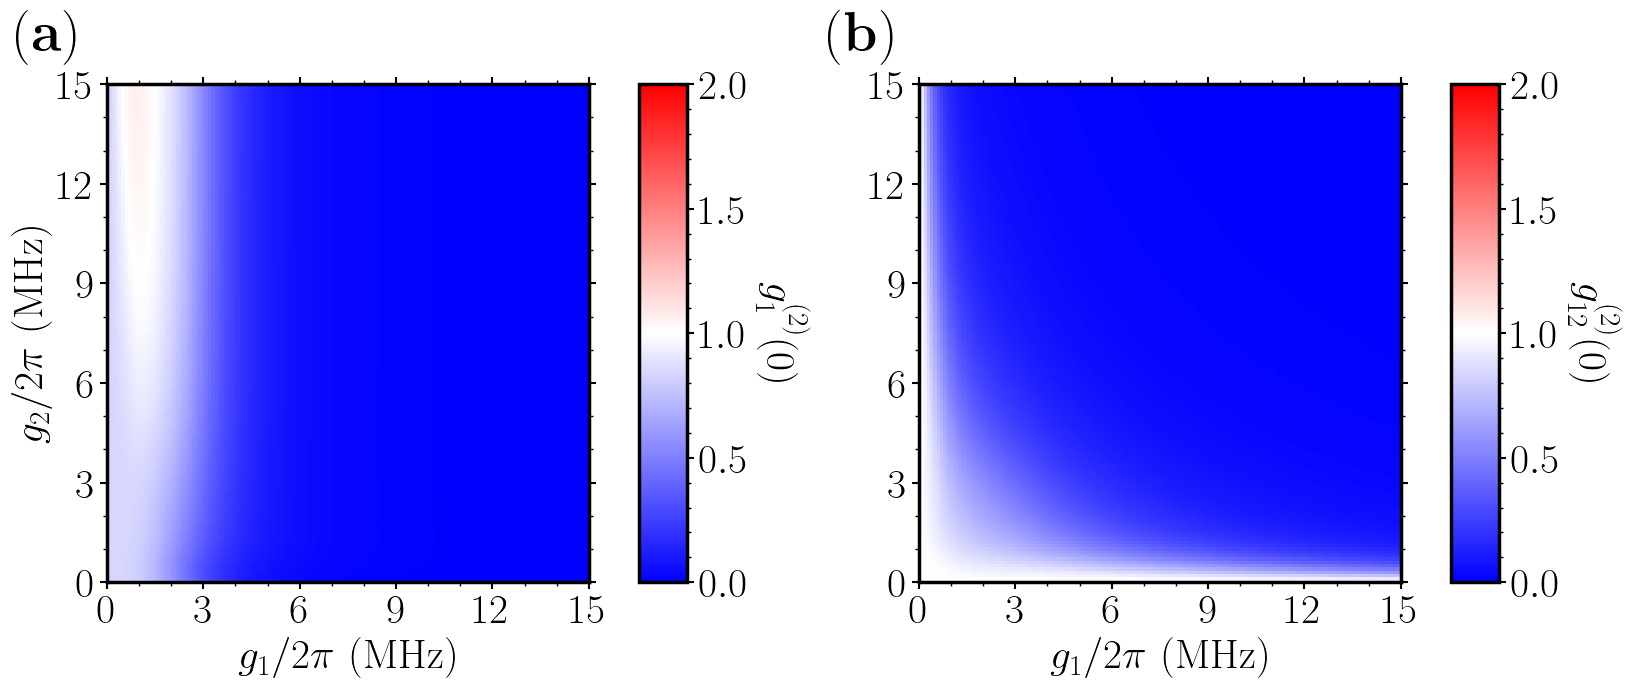

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
##############################################################
# ---- Heatmap ----
##############################################################
nrm = mpl.colors.Normalize(0., 2.0)

im1 = axes[0].pcolormesh(x_list_2, y_list_2, g2_A1,
                         cmap=cm.bwr,
                         norm=nrm,
                         shading='auto')

axes[0].set_xlabel(r'$g_1/2\pi$ (MHz)')
axes[0].set_ylabel(r'$g_2/2\pi$ (MHz)')

axes[0].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[0].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[0].set_xlim(x0, xf)
axes[0].set_ylim(y0, yf)

axes[0].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[0].yaxis.set_minor_locator(AutoMinorLocator(3))
axes[0].xaxis.set_minor_locator(AutoMinorLocator(3))

axes[0].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[0])

cax = divider.append_axes(
    "right",
    size="10%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label(r'$g_1^{(2)}(0)$',
               rotation=270,
               labelpad=45)

cbar.ax.tick_params(which='both', direction='out')

##############################################################
# ---- Heatmap 2 ----
##############################################################
im2 = axes[1].pcolormesh(x_list_2, y_list_2, g2_A1_A2,
                         cmap=cm.bwr,
                         norm=nrm,
                         shading='auto')

axes[1].set_xlabel(r'$g_1/2\pi$ (MHz)')

axes[1].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[1].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[1].set_xlim(x0, xf)
axes[1].set_ylim(y0, yf)

axes[1].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[1].yaxis.set_minor_locator(AutoMinorLocator(3))
axes[1].xaxis.set_minor_locator(AutoMinorLocator(3))

axes[1].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[1])

cax = divider.append_axes(
    "right",
    size="10%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im2, cax=cax)

cbar.set_label(r'$g_{12}^{(2)}(0)$',
               rotation=270,
               labelpad=45)

cbar.ax.tick_params(which='both', direction='out')

#############################################################
# Panel labels
#############################################################
panel_labels = [r'$\mathbf{(a)}$',r'$\mathbf{(b)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.19,
        1.15,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )
##############################################################
# ---- Global spacing ----
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.95,
    wspace=0.4   # spacing between the TWO plots only
)

save_figure(fig, "Thesis_Figures", "chap4_sim2_antibunching_g(2)1_g(2)12", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

### 2) Colormap for cavity 1 average field amplitude $g_1 \times g_2 \times \vert\langle\hat{a}_k\rangle_{ss}\vert$ at different cut offs


Saved:
Results\Sim1_DeltaA_vs_gaFigures\chap4_sim2_averagefield_amp_ss_part1.pdf


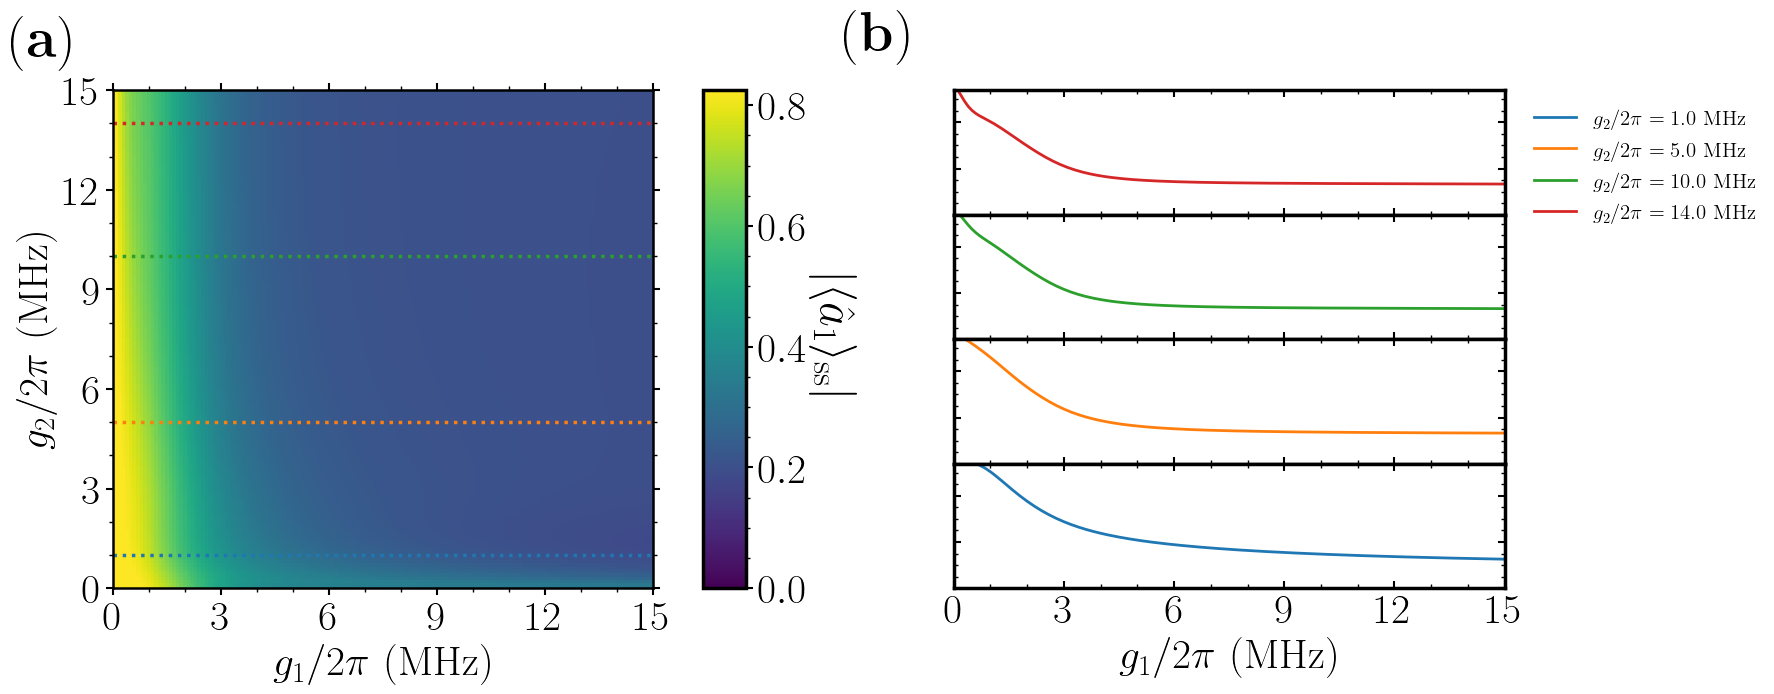

In [119]:
fig = plt.figure(figsize=(16, 6))

gs = fig.add_gridspec(
    1, 2,
    width_ratios=[1.15, 1],
    wspace=0.35)               # Plots distance

ax0 = fig.add_subplot(gs[0, 0])

gs_right = gs[0, 1].subgridspec(
    4, 1,
    hspace=0.0)                 # Stacked plots vertical dsitance

axes_right = []
for i in range(4):
    if i == 0:
        ax = fig.add_subplot(gs_right[i, 0])
    else:
        ax = fig.add_subplot(gs_right[i, 0], sharex=axes_right[0])
    axes_right.append(ax)

##############################################################
# ---- Heatmap ----
##############################################################
nrm = mpl.colors.Normalize(0, 0.99*fieldAmp_A1.max())

im1 = ax0.pcolormesh(x_list_2, y_list_2, fieldAmp_A1,cmap=cm.viridis,norm=nrm,shading='auto')

ax0.set_xlabel(r'$g_1/2\pi$ (MHz)')
ax0.set_ylabel(r'$g_2/2\pi$ (MHz)')
#ax0.set_title(r'$g_2/2\pi = 10$ MHz', fontsize=25, pad=10)

ax0.xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
ax0.yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

ax0.set_xlim(x0, xf)
ax0.set_ylim(y0, yf)

ax0.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax0.yaxis.set_major_locator(MaxNLocator(nbins=5))

ax0.xaxis.set_minor_locator(AutoMinorLocator(3))
ax0.yaxis.set_minor_locator(AutoMinorLocator(3))

ax0.tick_params(axis='both', which='both', direction='out')

for spine in ax0.spines.values():
    spine.set_linewidth(1.8)

##### Colorbar settings #####
divider = make_axes_locatable(ax0)

cax = divider.append_axes(
    "right",
    size="8%",  # <-- width of colorbar
    pad=0.5     # <-- distance to plot
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label(r'$\vert\langle \hat{a}_1\rangle_{\rm ss}\vert$',rotation=270,labelpad=35, fontsize=35)

cbar.ax.tick_params(which='both', direction='out')

##### Overlays #####
cut_values = [1.0, 5.0, 10.0, 14.0] # MHz

cut_indices = [argmin(abs(array(y_list_2) - value)) for value in cut_values]

cut_colors = ['C0', 'C1', 'C2', 'C3']

##############################################################
# Sort cuts by actual selected g1 value
##############################################################
cut_info = sorted([(y_list_2[i], i, c) for i, c in zip(cut_indices, cut_colors)],
                  key=lambda x: x[0])

##############################################################
# Horizontal lines on heatmap
##############################################################
for g_val, i, c in cut_info:
    ax0.axhline(y=g_val, color=c, linestyle=':')

##############################################################
# ---- Right stacked cut plots ----
##############################################################
start = 0
end   = round(fieldAmp_A1.max(), 1)

legend_handles = []
legend_labels  = []

for ax, (g_val, i, c) in zip(axes_right[::-1], cut_info):

    ax.plot(x_list_2, fieldAmp_A1[i],color=c,lw=2)

    ax.set_xlim(x0, xf)
    ax.set_ylim(0, 1.01*end)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.xaxis.set_minor_locator(AutoMinorLocator(3))

    ax.tick_params(axis='both', which='both',direction='in',top=True,right=True)

    ax.tick_params(axis='y', labelleft=False)

    if ax is not axes_right[-1]:
        ax.tick_params(axis='x', labelbottom=False)

    for spine in ax.spines.values():
        spine.set_linewidth(2.5) # Frame thickness

    legend_handles.append(Line2D([0], [0], color=c, lw=2))
    legend_labels.append(r'$g_2/2\pi = %.1f$ MHz' % g_val)


axes_right[-1].set_xlabel(r'$g_1/2\pi$ (MHz)')

axes_right[0].legend(legend_handles, legend_labels,
                     frameon=False,loc='upper left', bbox_to_anchor=(1.02, 1))

##############################################################
# Overlay labels
##############################################################
ax0.text(-0.19,1.15,r'$\mathbf{(a)}$',transform=ax0.transAxes,ha='left',va='top',fontsize=40,color='black')

axes_right[0].text(-0.20,1.65,r'$\mathbf{(b)}$',transform=axes_right[0].transAxes,ha='left',va='top',fontsize=40,color='black')

##############################################################
# ---- Global spacing ----
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.95
)

save_figure(fig,"Thesis_Figures", "chap4_sim2_averagefield_amp_ss_part1", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

### 3) Colormap for cavity 1 and 2 average field amplitude $g_1 \times g_2 \times \vert\langle\hat{a}_k\rangle_{ss}\vert$


Saved:
Results\Sim1_DeltaA_vs_gaFigures\chap4_sim2_averagefield_amp_ss_part2.pdf


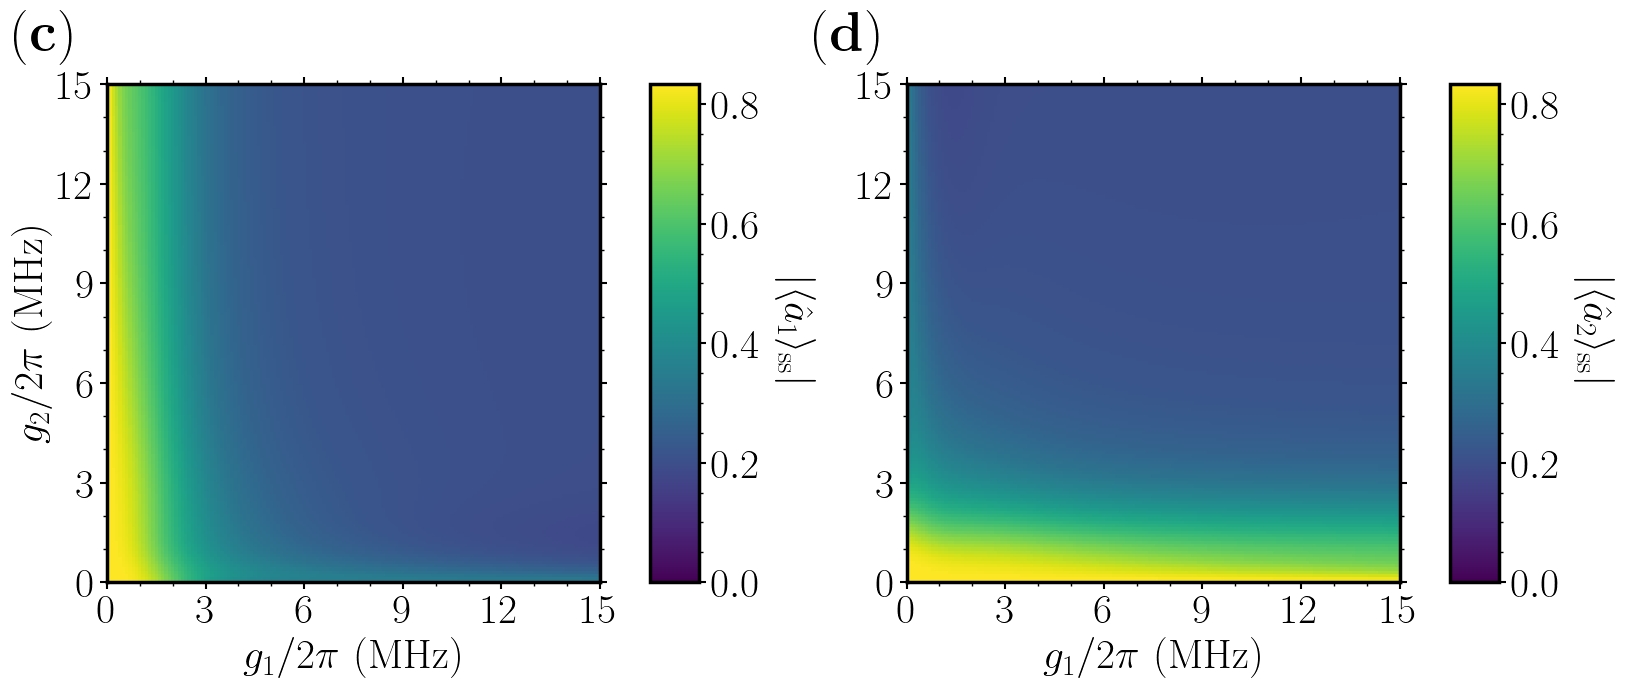

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
##############################################################
# ---- Heatmap ----
##############################################################
nrm1 = mpl.colors.Normalize(0, fieldAmp_A1.max())

im1 = axes[0].pcolormesh(x_list_2, y_list_2, fieldAmp_A1,
                         cmap=cm.viridis,
                         norm=nrm1,
                         shading='auto')

axes[0].set_xlabel(r'$g_1/2\pi$ (MHz)')
axes[0].set_ylabel(r'$g_2/2\pi$ (MHz)')

axes[0].set_xlim(x0, xf)
axes[0].set_ylim(y0, yf)

axes[0].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[0].xaxis.set_minor_locator(AutoMinorLocator(3))
axes[0].yaxis.set_minor_locator(AutoMinorLocator(3))

axes[0].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[0])

cax = divider.append_axes(
    "right",
    size="10%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label(r'$\vert\langle \hat a_1\rangle_{\rm ss}\vert$',
               rotation=270,
               labelpad=40)

cbar.ax.tick_params(which='both', direction='out')

##############################################################
# ---- Heatmap 2 ----
##############################################################
nrm2 = mpl.colors.Normalize(0, fieldAmp_A2.max())

im2 = axes[1].pcolormesh(x_list_2, y_list_2, fieldAmp_A2,
                         cmap=cm.viridis,
                         norm=nrm2,
                         shading='auto')

axes[1].set_xlabel(r'$g_1/2\pi$ (MHz)')

axes[1].set_xlim(x0, xf)
axes[1].set_ylim(y0, yf)

axes[1].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[1].xaxis.set_minor_locator(AutoMinorLocator(3))
axes[1].yaxis.set_minor_locator(AutoMinorLocator(3))

axes[1].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[1])

cax = divider.append_axes(
    "right",
    size="10%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im2, cax=cax)

cbar.set_label(r'$\vert\langle \hat a_2\rangle_{\rm ss}\vert$',
               rotation=270,
               labelpad=40)

cbar.ax.tick_params(which='both', direction='out')

#############################################################
# Panel labels
#############################################################
panel_labels = [r'$\mathbf{(c)}$',r'$\mathbf{(d)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.19,
        1.15,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )
##############################################################
# ---- Global spacing ----
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.95,
    wspace=0.35   # spacing between the TWO plots only
)

save_figure(fig,"Thesis_Figures", "chap4_sim2_averagefield_amp_ss_part2", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

### 4) Average photon numbers $\langle \hat{N}_k \rangle_{ss} $ for cavity 1 and 2

In [123]:
mean_N1 = empty((Ny, Nx), dtype=float)
mean_N2 = empty((Ny, Nx), dtype=float)

for i in range(Ny):
    for j in range(Nx):
        mean_N1[i, j] = abs(expect(a.dag() * a, rho_grid[i, j]))
        mean_N2[i, j] = abs(expect(b.dag() * b, rho_grid[i, j]))


Saved:
Results\Sim1_DeltaA_vs_gaFigures\chap4_sim2_avg_number_photons.pdf


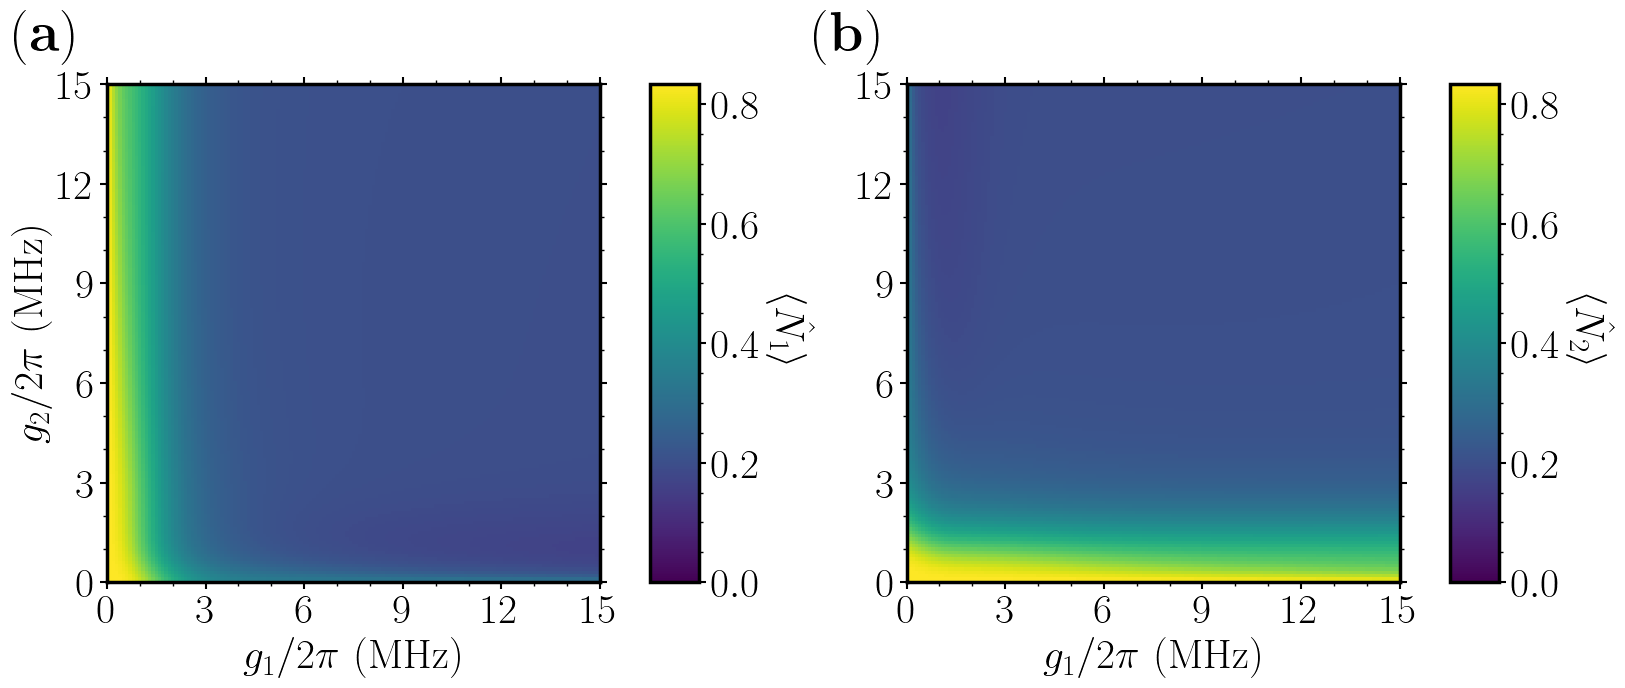

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
##############################################################
# ---- Heatmap ----
##############################################################
nrm1 = mpl.colors.Normalize(0, mean_N1.max())

im1 = axes[0].pcolormesh(x_list_2, y_list_2, mean_N1,
                         cmap=cm.viridis,
                         norm=nrm1,
                         shading='auto')

axes[0].set_xlabel(r'$g_1/2\pi$ (MHz)')
axes[0].set_ylabel(r'$g_2/2\pi$ (MHz)')

axes[0].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[0].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[0].set_xlim(x0, xf)
axes[0].set_ylim(y0, yf)

axes[0].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[0].xaxis.set_minor_locator(AutoMinorLocator(3))
axes[0].yaxis.set_minor_locator(AutoMinorLocator(3))

axes[0].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[0])

cax = divider.append_axes(
    "right",
    size="10%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label(r'$\langle \hat N_1\rangle$',
               rotation=270,
               labelpad=40)

cbar.ax.tick_params(which='both', direction='out')

##############################################################
# ---- Heatmap 2 ----
##############################################################
nrm2 = mpl.colors.Normalize(0, mean_N2.max())

im2 = axes[1].pcolormesh(x_list_2, y_list_2, mean_N2,
                         cmap=cm.viridis,
                         norm=nrm2,
                         shading='auto')

axes[1].set_xlabel(r'$g_1/2\pi$ (MHz)')

axes[1].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[1].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[1].set_xlim(x0, xf)
axes[1].set_ylim(y0, yf)

axes[1].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[1].xaxis.set_minor_locator(AutoMinorLocator(3))
axes[1].yaxis.set_minor_locator(AutoMinorLocator(3))

axes[1].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[1])

cax = divider.append_axes(
    "right",
    size="10%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im2, cax=cax)

cbar.set_label(r'$\langle \hat N_2\rangle$',
               rotation=270,
               labelpad=40)

cbar.ax.tick_params(which='both', direction='out')

#############################################################
# Panel labels
#############################################################
panel_labels = [r'$\mathbf{(a)}$',r'$\mathbf{(b)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.19,
        1.15,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )
##############################################################
# ---- Global spacing ----
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.95,
    wspace=0.35   # spacing between the TWO plots only
)

save_figure(fig,"Thesis_Figures", "chap4_sim2_avg_number_photons", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

In [126]:
P2_A1 = empty((Ny, Nx), dtype=float)
P2_A2 = empty((Ny, Nx), dtype=float)

for i in range(Ny):
    for j in range(Nx):

        rho_A1 = rho_grid[i, j].ptrace(0)
        rho_A2 = rho_grid[i, j].ptrace(1)

        P2_A1[i, j] = real(rho_A1.diag()[2])
        P2_A2[i, j] = real(rho_A2.diag()[2])


Saved:
Results\Sim1_DeltaA_vs_gaFigures\chap4_sim2_two_photons_pop.pdf


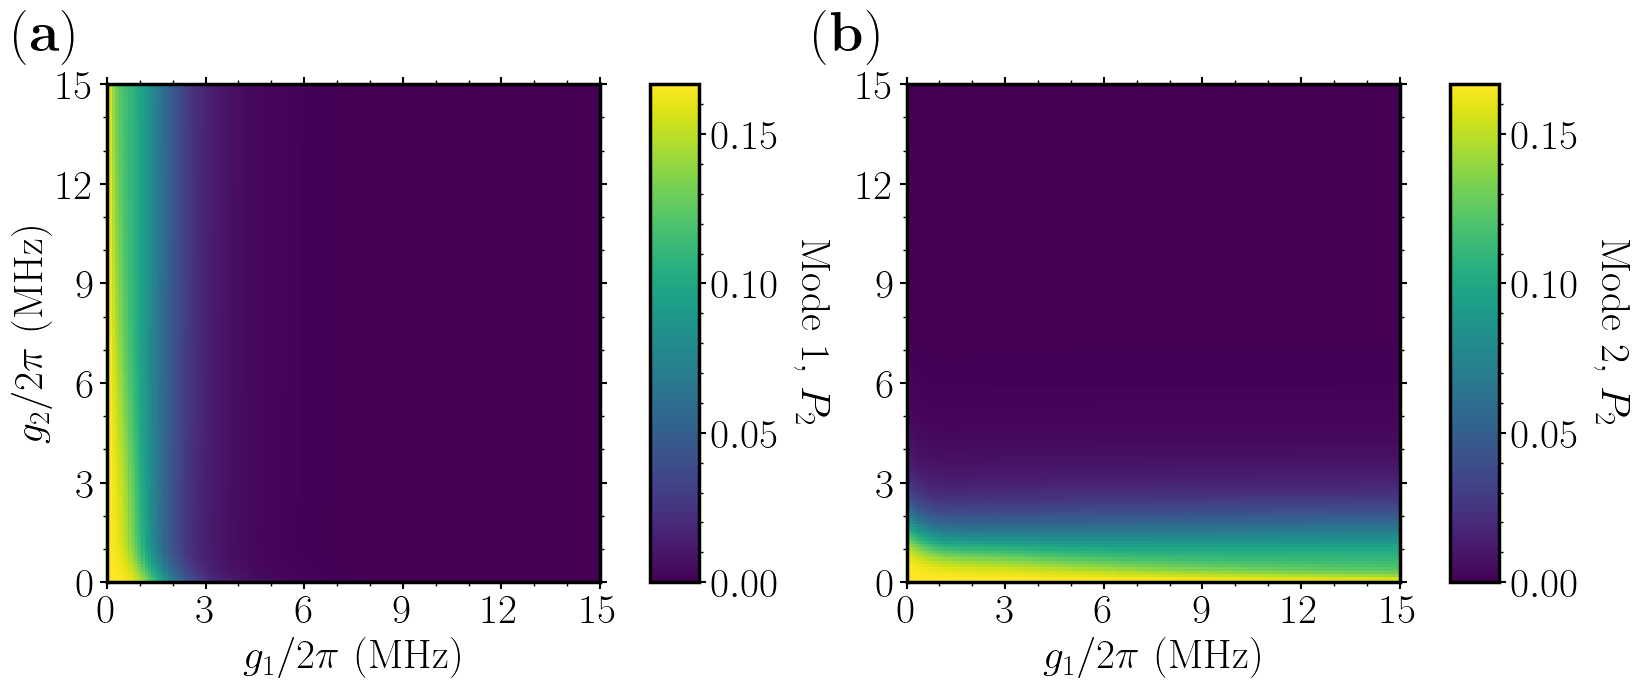

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
##############################################################
# ---- Heatmap ----
##############################################################
nrm1 = mpl.colors.Normalize(0, P2_A1.max())

im1 = axes[0].pcolormesh(x_list_2, y_list_2, P2_A1,
                         cmap=cm.viridis,
                         norm=nrm1,
                         shading='auto')

axes[0].set_xlabel(r'$g_1/2\pi$ (MHz)')
axes[0].set_ylabel(r'$g_2/2\pi$ (MHz)')

axes[0].set_xlim(x0, xf)
axes[0].set_ylim(y0, yf)

axes[0].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[0].xaxis.set_minor_locator(AutoMinorLocator(3))
axes[0].yaxis.set_minor_locator(AutoMinorLocator(3))

axes[0].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[0])

cax = divider.append_axes(
    "right",
    size="10%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label(r'Mode 1, $P_2$',
               rotation=270,
               labelpad=37)

cbar.ax.tick_params(which='both', direction='out')

##############################################################
# ---- Heatmap 2 ----
##############################################################
nrm2 = mpl.colors.Normalize(0, P2_A2.max())

im2 = axes[1].pcolormesh(x_list_2, y_list_2, P2_A2,
                         cmap=cm.viridis,
                         norm=nrm2,
                         shading='auto')

axes[1].set_xlabel(r'$g_1/2\pi$ (MHz)')

axes[1].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[1].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[1].set_xlim(x0, xf)
axes[1].set_ylim(y0, yf)

axes[1].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[1].xaxis.set_minor_locator(AutoMinorLocator(3))
axes[1].yaxis.set_minor_locator(AutoMinorLocator(3))

axes[1].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[1])

cax = divider.append_axes(
    "right",
    size="10%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im2, cax=cax)

cbar.set_label(r'Mode 2, $P_2$',
               rotation=270,
               labelpad=37)

cbar.ax.tick_params(which='both', direction='out')

#############################################################
# Panel labels
#############################################################
panel_labels = [r'$\mathbf{(a)}$',r'$\mathbf{(b)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.19,
        1.15,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )
##############################################################
# ---- Global spacing ----
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.95,
    wspace=0.35   # spacing between the TWO plots only
)

save_figure(fig, folder_1 + "Figures", "chap4_sim2_two_photons_pop", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

In [129]:
## Correlations 
N1_grid = empty((Ny, Nx), dtype=float)
N2_grid = empty((Ny, Nx), dtype=float)
N12_grid = empty((Ny, Nx), dtype=float)

C12_grid = empty((Ny, Nx), dtype=complex)
C21_grid = empty((Ny, Nx), dtype=complex)
Csym_grid = empty((Ny, Nx), dtype=float)

X1_grid = empty((Ny, Nx), dtype=complex)
X2_grid = empty((Ny, Nx), dtype=complex)

negativity_grid = empty((Ny, Nx), dtype=float)

HZ1_grid = empty((Ny, Nx), dtype=float)
HZ2_grid = empty((Ny, Nx), dtype=float)

for i in range(Ny):
    ga_i = x_list_2[i]
    for j in range(Nx):
        gb_j = y_list_2[j]
        rho_ss = rho_grid[i, j]

        N1_grid[i, j] = real(expect(Nop_A1, rho_ss))
        N2_grid[i, j] = real(expect(Nop_A2, rho_ss))
        N12_grid[i, j] = real(expect(Nop_A1 * Nop_A2, rho_ss))

        C12_grid[i, j] = (expect(a*Nop_A2, rho_ss) - expect(a, rho_ss) * expect(Nop_A2, rho_ss))

        C21_grid[i, j] = (expect(b * Nop_A1, rho_ss) - expect(b, rho_ss) * expect(Nop_A1, rho_ss))

        Csym_grid[i, j] = sqrt(abs(C12_grid[i, j])**2 + abs(C21_grid[i, j])**2)

        X1_grid[i, j] = ((2 * ga_i * gb_j / wr) * C12_grid[i, j])

        X2_grid[i, j] = ((2 * ga_i * gb_j / wr) * C21_grid[i, j])

        ##############################################################
        # Two-mode negativity
        ##############################################################
        rho_AB = ptrace(rho_ss, [0, 1])

        neg_aux = real(negativity(rho_AB, 0, method='eigenvalues'))

        if neg_aux > 0:
            negativity_grid[i, j] = neg_aux
        else:
            negativity_grid[i, j] = 0.0

        ##############################################################
        # Hillery-Zubairy criteria
        ##############################################################
        HZ1_grid[i, j] = real(expect(Nop_A1 * Nop_A2, rho_ss)- abs(expect(a * b.dag(), rho_ss))**2)

        HZ2_grid[i, j] = real(expect(Nop_A1, rho_ss) * expect(Nop_A2, rho_ss) - abs(expect(a * b, rho_ss))**2)

### 5) Covariance parameters $C_{12}$ and $C_{21}$


Saved:
Thesis_Figures\chap4_sim2_connected_correlations_part1.pdf


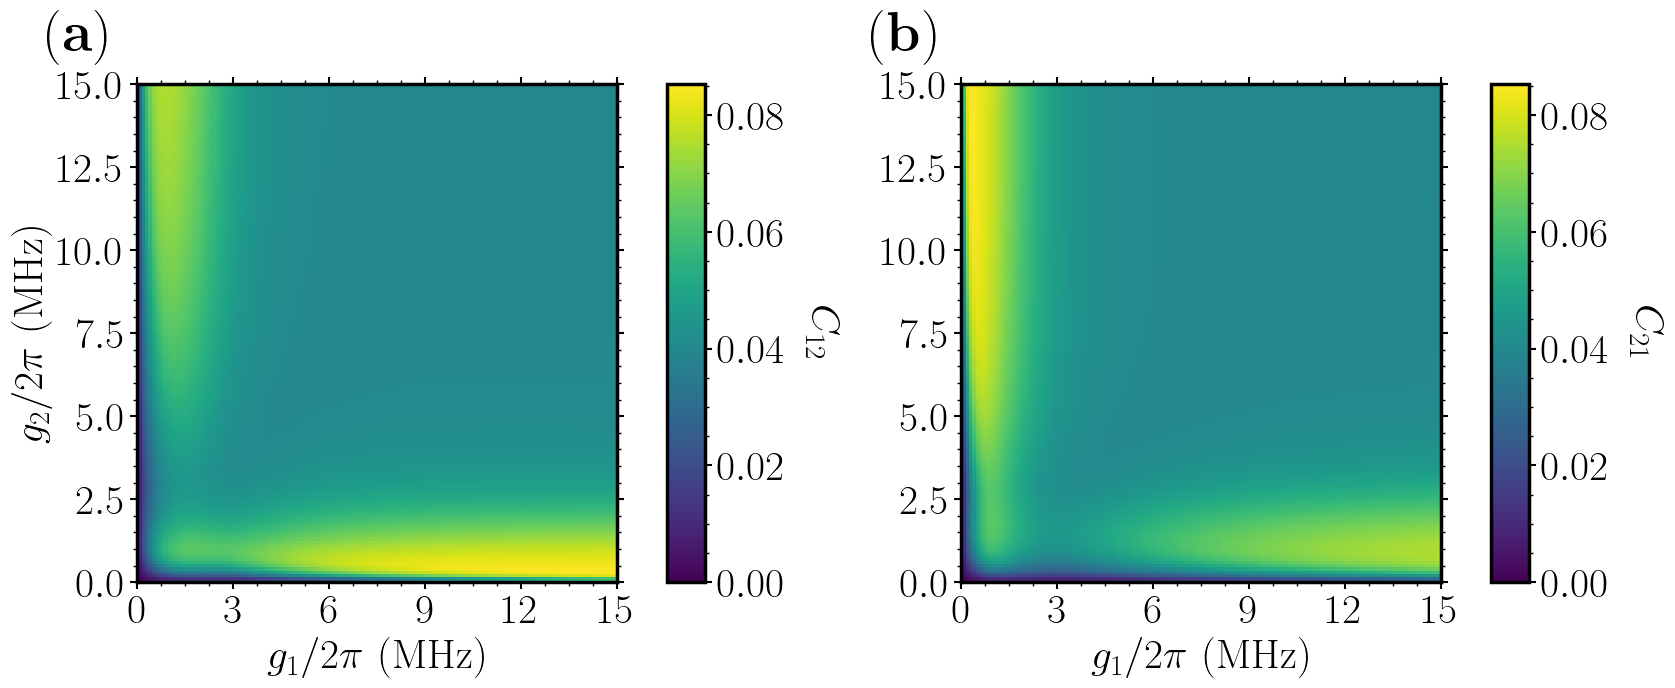

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
##############################################################
# ---- Heatmap ----
##############################################################
nrm1 = mpl.colors.Normalize(0, abs(C12_grid).max())

im1 = axes[0].pcolormesh(x_list_2, y_list_2, abs(C12_grid),
                         cmap=cm.viridis,
                         norm=nrm1,
                         shading='auto')

axes[0].set_xlabel(r'$g_1/2\pi$ (MHz)')
axes[0].set_ylabel(r'$g_2/2\pi$ (MHz)')

axes[0].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[0].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[0].set_xlim(x0, xf)
axes[0].set_ylim(y0, yf)

axes[0].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=6))

axes[0].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[0])

cax = divider.append_axes(
    "right",
    size="8%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label(r'$C_{12}$',
               rotation=270,
               labelpad=40)

cbar.ax.tick_params(which='both', direction='out')

##############################################################
# ---- Heatmap 2 ----
##############################################################
nrm2 = mpl.colors.Normalize(0, abs(C21_grid).max())

im2 = axes[1].pcolormesh(x_list_2, y_list_2, abs(C21_grid),
                         cmap=cm.viridis,
                         norm=nrm2,
                         shading='auto')

axes[1].set_xlabel(r'$g_1/2\pi$ (MHz)')

axes[1].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[1].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[1].set_xlim(x0, xf)
axes[1].set_ylim(y0, yf)

axes[1].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=6))

axes[1].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[1])

cax = divider.append_axes(
    "right",
    size="8%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im2, cax=cax)

cbar.set_label(r'$C_{21}$',
               rotation=270,
               labelpad=40)

cbar.ax.tick_params(which='both', direction='out')

#############################################################
# Panel labels
#############################################################
panel_labels = [r'$\mathbf{(a)}$',r'$\mathbf{(b)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.19,
        1.15,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )
##############################################################
# ---- Global spacing ----
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.95,
    wspace=0.45   # spacing between the TWO plots only
)

save_figure(fig, "Thesis_Figures", "chap4_sim2_connected_correlations_part1", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

### 6) Comparison between $C_\text{sym}$ and the negativity between cavity 1 and cavity 2


Saved:
Thesis_Figures\chap4_sim2_connected_correlations_part2.pdf


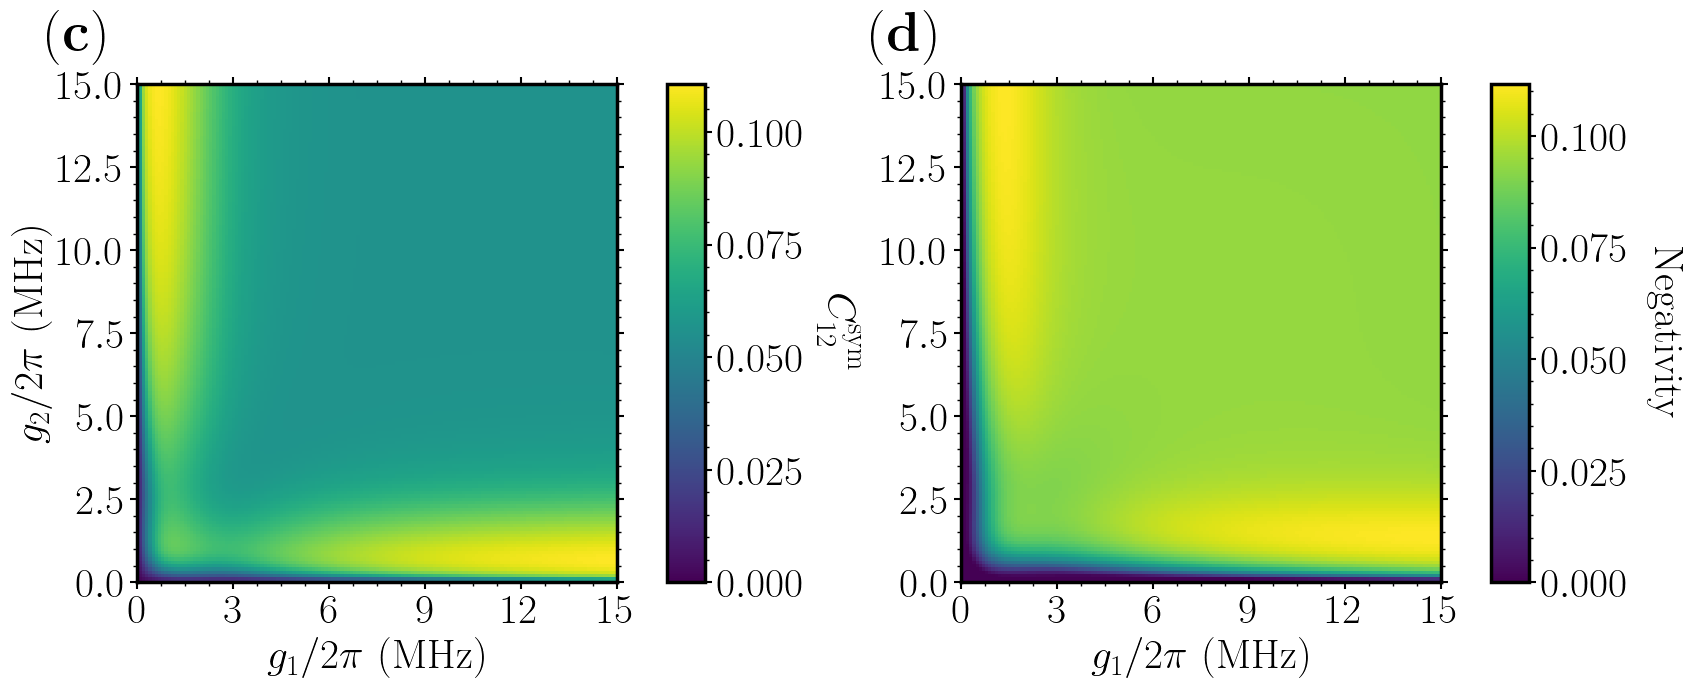

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
##############################################################
# ---- Heatmap ----
##############################################################
nrm1 = mpl.colors.Normalize(0, abs(Csym_grid).max())

im1 = axes[0].pcolormesh(x_list_2, y_list_2, abs(Csym_grid),
                         cmap=cm.viridis,
                         norm=nrm1,
                         shading='auto')

axes[0].set_xlabel(r'$g_1/2\pi$ (MHz)')
axes[0].set_ylabel(r'$g_2/2\pi$ (MHz)')

axes[0].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[0].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[0].set_xlim(x0, xf)
axes[0].set_ylim(y0, yf)

axes[0].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=6))

axes[0].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[0])

cax = divider.append_axes(
    "right",
    size="8%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label(r'$C^{\rm sym}_{12}$',
               rotation=270,
               labelpad=40)

cbar.ax.tick_params(which='both', direction='out')

##############################################################
# ---- Heatmap 2 ----
##############################################################
nrm2 = mpl.colors.Normalize(0, abs(negativity_grid).max())

im2 = axes[1].pcolormesh(x_list_2, y_list_2, abs(negativity_grid),
                         cmap=cm.viridis,
                         norm=nrm2,
                         shading='auto')

axes[1].set_xlabel(r'$g_1/2\pi$ (MHz)')

axes[1].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[1].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[1].set_xlim(x0, xf)
axes[1].set_ylim(y0, yf)

axes[1].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=6))

axes[1].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[1])

cax = divider.append_axes(
    "right",
    size="8%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im2, cax=cax)

cbar.set_label(r'Negativity',
               rotation=270,
               labelpad=40)

cbar.ax.tick_params(which='both', direction='out')

#############################################################
# Panel labels
#############################################################
panel_labels = [r'$\mathbf{(c)}$',r'$\mathbf{(d)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.19,
        1.15,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )
##############################################################
# ---- Global spacing ----
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.95,
    wspace=0.45   # spacing between the TWO plots only
)

save_figure(fig, "Thesis_Figures", "chap4_sim2_connected_correlations_part2", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

### 7) HZ Criterias


Saved:
Thesis_Figures\chap4_sim2_HZ_criteria.pdf


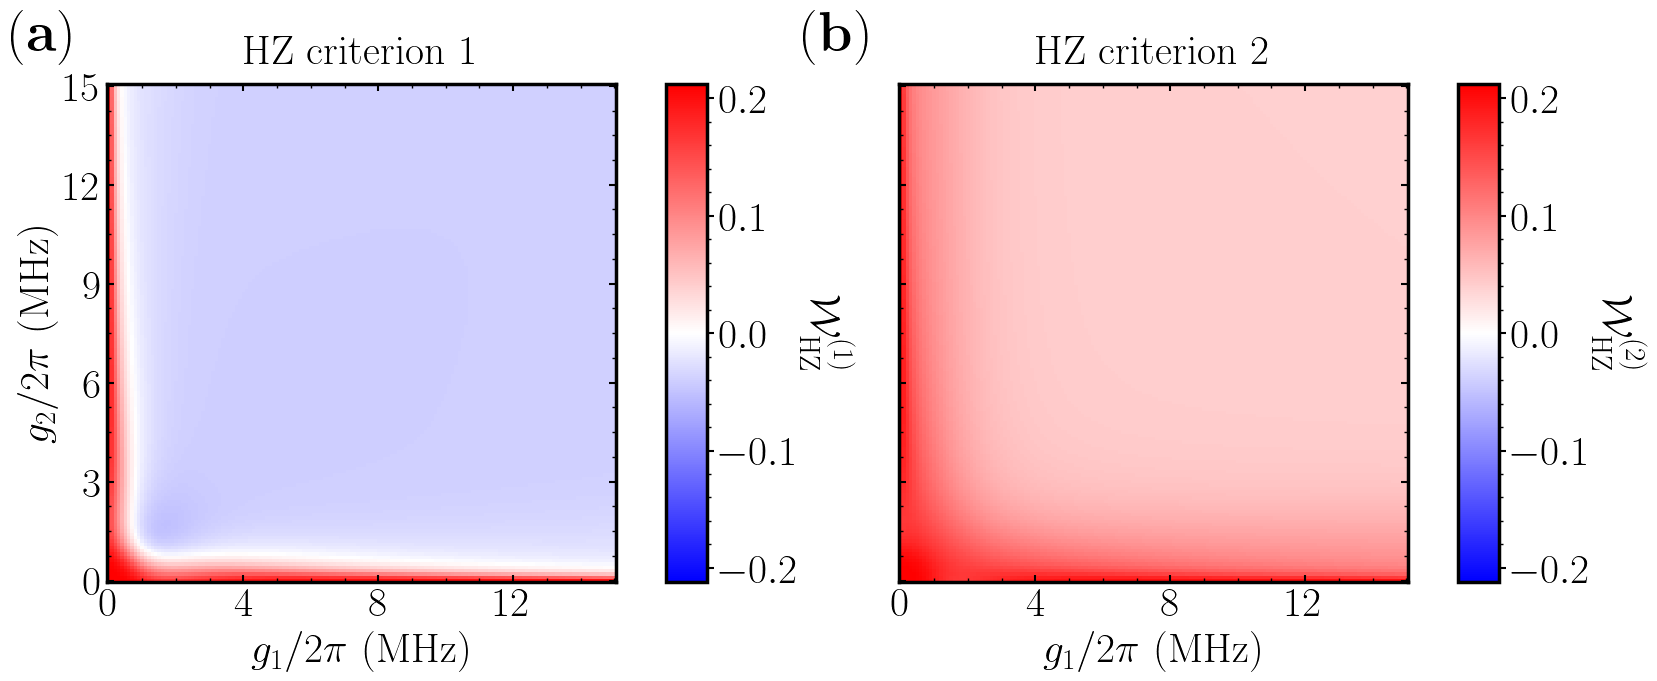

In [134]:
##############################################################
# Hillery-Zubairy criteria
##############################################################
HZ1_lim = nanmax(abs(HZ1_grid))
HZ2_lim = nanmax(abs(HZ2_grid))

if HZ1_lim == 0:
    HZ1_lim = 1

if HZ2_lim == 0:
    HZ2_lim = 1

nrm_HZ1 = mpl.colors.TwoSlopeNorm(vmin=-HZ1_lim,vcenter=0,vmax=HZ1_lim)
nrm_HZ2 = mpl.colors.TwoSlopeNorm(vmin=-HZ2_lim,vcenter=0,vmax=HZ2_lim)

fig, axes = plt.subplots(1,2,figsize=(16, 6),sharey=True)

##############################################################
# HZ criterion 1
##############################################################
im0 = axes[0].pcolormesh(x_list_2, y_list_2, HZ1_grid, shading="auto",  cmap="bwr", norm=nrm_HZ1)

axes[0].set_title(r"HZ criterion 1", pad=15)
axes[0].set_xlabel(r'$g_1/2\pi$ (MHz)')
axes[0].set_ylabel(r"$g_2/2\pi$ (MHz)")

axes[0].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=6))

axes[0].tick_params(axis='both', which='both', direction='in')

##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[0])

cax = divider.append_axes(
    "right",
    size="8%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im0, cax=cax)

cbar.set_label(r"$\mathcal{W}_{\mathrm{HZ}}^{(1)}$",
               rotation=270,
               labelpad=40)

cbar.ax.tick_params(which='both', direction='out')

##############################################################
# HZ criterion 2
##############################################################
im1 = axes[1].pcolormesh(x_list_2,y_list_2,HZ2_grid,shading="auto",cmap="bwr",norm=nrm_HZ2)

if nanmin(HZ2_grid) < 0 and nanmax(HZ2_grid) > 0:
    axes[1].contour(x_list_2,y_list_2,HZ2_grid,levels=[0],colors="black",linewidths=2)

axes[1].set_title(r"HZ criterion 2",pad=15)
axes[1].set_xlabel(r'$g_1/2\pi$ (MHz)')

axes[1].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=6))

axes[1].tick_params(axis='both', which='both', direction='in')

##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[1])

cax = divider.append_axes(
    "right",
    size="8%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label(r"$\mathcal{W}_{\mathrm{HZ}}^{(2)}$",
               rotation=270,
               labelpad=40)

cbar.ax.tick_params(which='both', direction='out')

#############################################################
# Panel labels
#############################################################
panel_labels = [r'$\mathbf{(a)}$',r'$\mathbf{(b)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.19,
        1.15,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )
    
##############################################################
# ---- Global spacing ----
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.95,
    wspace=0.32   # spacing between the TWO plots only
)

save_figure(fig, "Thesis_Figures", "chap4_sim2_HZ_criteria", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

## Simulation 3

In [145]:
folder_3 = "Results\Sim3_DeltaA_vs_DeltaB"

data_3 = load_result(folder_3)

time_index = datetime.datetime.now().strftime("_[%Y-%m-%d]_[%Hh%Mm]")
date_index = datetime.datetime.now().strftime("_[%Y-%m-%d]")

x_list_3 = data_3[0]    # Delta_a_list
rho_grid = data_3[2]    # rho_ss grid
y_list_3 = data_3[1]    # Delta_b_list

N_a = data_3[3]         # Fock dimension Mode 1/A
N_b = data_3[4]         # Fock dimension Mode 2/B
N_r = data_3[5]         # Fock dimension Mechanical Mode/R
wr  = data_3[6]         # Mechanical Frequency

computation_time = data_3[7]

print(f"Computation time: {computation_time:.2f} seconds")
print(f"Computation time: {computation_time/60:.2f} minutes")
print(f"Computation time: {computation_time/3600:.2f} hours")

##############################################################
x0 =  x_list_3[0].round()
xf = x_list_3[-1].round()
y0 =  y_list_3[0].round()
yf = y_list_3[-1].round()
delta_x = xf - x0
delta_y = yf - y0
Ny = len(y_list_3)
Nx = len(x_list_3)
##############################################################
a = tensor(destroy(N_a), qeye(N_b), qeye(N_r))
b = tensor(qeye(N_a), destroy(N_b), qeye(N_r))
r = tensor(qeye(N_a), qeye(N_b), destroy(N_r))

Nop_A1 = a.dag()*a
Nop_A2 = b.dag()*b

fieldAmp_A1 = empty((Ny, Nx), dtype=float)
fieldAmp_A2 = empty((Ny, Nx), dtype=float)

for i in range(Ny):
    for j in range(Nx):

        fieldAmp_A1[i, j] = abs(expect(a, rho_grid[i, j]))
        fieldAmp_A2[i, j] = abs(expect(b, rho_grid[i, j]))


Available files:
[0] Results_[2026-08-11]_[12h03m].npy
[1] Results_[2026-07-21]_[20h38m].npy
[2] Results_[2026-07-21]_[17h00m].npy

Loading: Results\Sim3_DeltaA_vs_DeltaB\Results_[2026-08-11]_[12h03m].npy

Computation time: 32777.41 seconds
Computation time: 546.29 minutes
Computation time: 9.10 hours


### 1) Colormap for cavity 1 and 2 average field amplitude $\Delta_1 \times \Delta_2 \times \langle\hat{a}_k\rangle_{ss}$


Saved:
Thesis_Figures\chap4_sim3_averagefield_amp_ss_part1.pdf


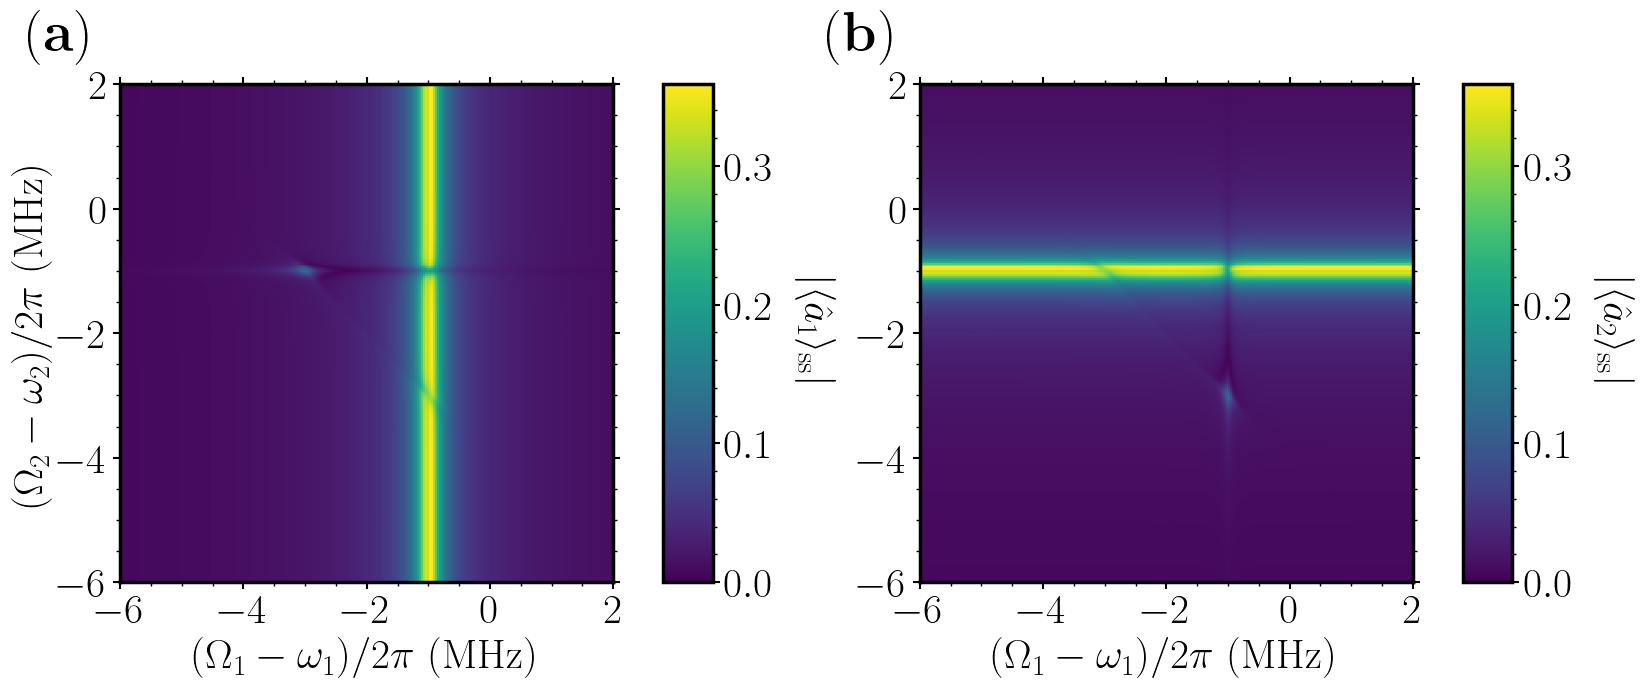

In [153]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
##############################################################
# ---- Heatmap ----
##############################################################
nrm1 = mpl.colors.Normalize(0, fieldAmp_A1.max())

im1 = axes[0].pcolormesh(x_list_3, y_list_3, fieldAmp_A1,
                         cmap=cm.viridis,
                         norm=nrm1,
                         shading='auto')

axes[0].set_xlabel(r'$(\Omega_1 - \omega_1)/2\pi$ (MHz)')
axes[0].set_ylabel(r'$(\Omega_2 - \omega_2)/2\pi$ (MHz)')

axes[0].set_xlim(x0, xf)
axes[0].set_ylim(y0, yf)

axes[0].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[0].xaxis.set_minor_locator(AutoMinorLocator(4))
axes[0].yaxis.set_minor_locator(AutoMinorLocator(4))

axes[0].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[0])

cax = divider.append_axes(
    "right",
    size="10%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label(r'$\vert\langle \hat a_1\rangle_{\rm ss}\vert$',
               rotation=270,
               labelpad=45)

cbar.ax.tick_params(which='both', direction='out')

##############################################################
# ---- Heatmap 2 ----
##############################################################
nrm2 = mpl.colors.Normalize(0, fieldAmp_A2.max())

im2 = axes[1].pcolormesh(x_list_3, y_list_3, fieldAmp_A2,
                         cmap=cm.viridis,
                         norm=nrm2,
                         shading='auto')

axes[1].set_xlabel(r'$(\Omega_1 - \omega_1)/2\pi$ (MHz)')

axes[1].set_xlim(x0, xf)
axes[1].set_ylim(y0, yf)

axes[1].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[1].xaxis.set_minor_locator(AutoMinorLocator(4))
axes[1].yaxis.set_minor_locator(AutoMinorLocator(4))

axes[1].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[1])

cax = divider.append_axes(
    "right",
    size="10%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im2, cax=cax)

cbar.set_label(r'$\vert\langle \hat a_2\rangle_{\rm ss}\vert$',
               rotation=270,
               labelpad=45)

cbar.ax.tick_params(which='both', direction='out')

#############################################################
# Panel labels
#############################################################
panel_labels = [r'$\mathbf{(a)}$',r'$\mathbf{(b)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.19,
        1.15,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )
##############################################################
# ---- Global spacing ----
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.95,
    wspace=0.35   # spacing between the TWO plots only
)

save_figure(fig,"Thesis_Figures", "chap4_sim3_averagefield_amp_ss_part1", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

### 2) Average photon numbers $\langle \hat{N}_k \rangle_{ss} $ for cavity 1 and 2

In [147]:
mean_N1 = empty((Ny, Nx), dtype=float)
mean_N2 = empty((Ny, Nx), dtype=float)

for i in range(Ny):
    for j in range(Nx):
        mean_N1[i, j] = abs(expect(a.dag() * a, rho_grid[i, j]))
        mean_N2[i, j] = abs(expect(b.dag() * b, rho_grid[i, j]))


Saved:
Thesis_Figures\chap4_sim3_avg_number_photons.pdf


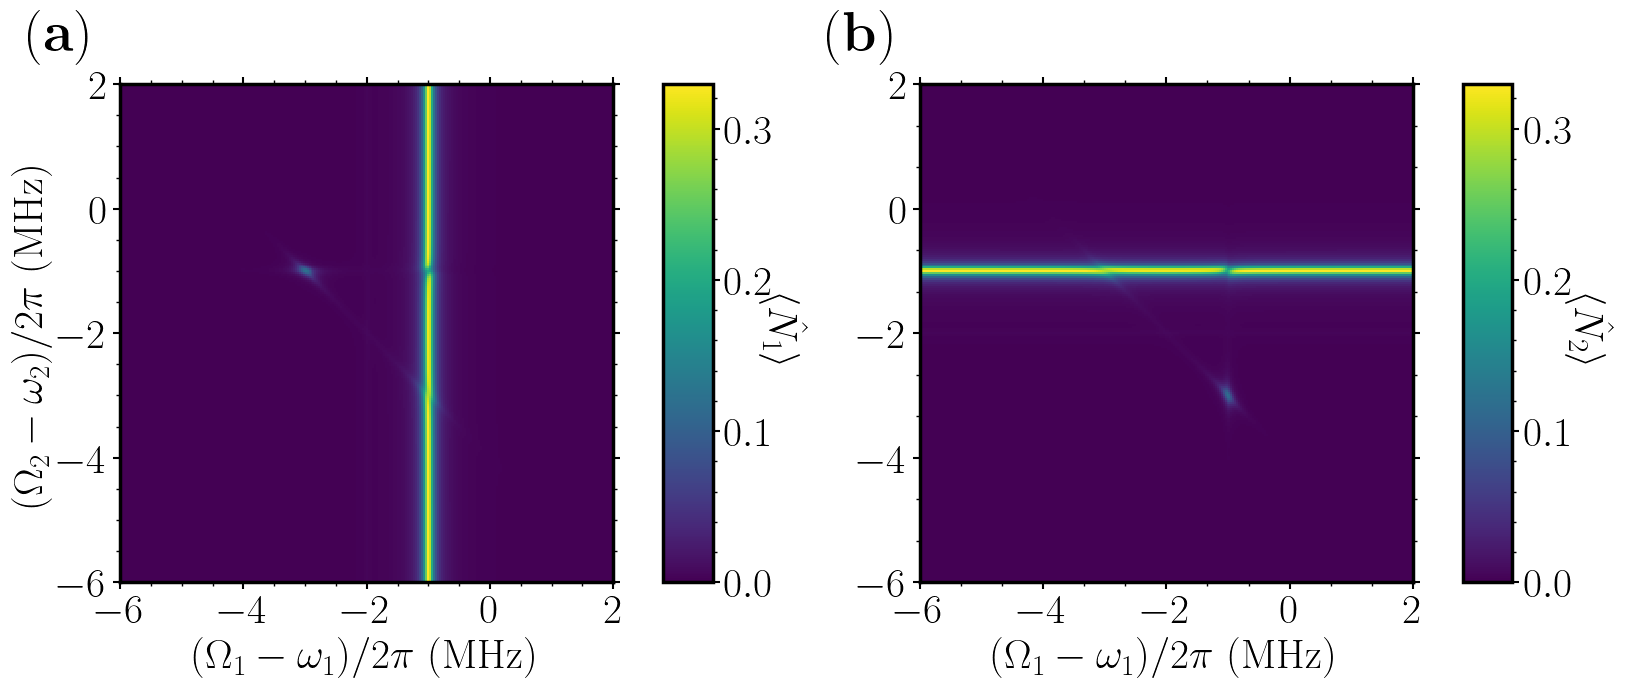

In [154]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
##############################################################
# ---- Heatmap ----
##############################################################
nrm1 = mpl.colors.Normalize(0, mean_N1.max())

im1 = axes[0].pcolormesh(x_list_3, y_list_3, mean_N1,
                         cmap=cm.viridis,
                         norm=nrm1,
                         shading='auto')

axes[0].set_xlabel(r'$(\Omega_1 - \omega_1)/2\pi$ (MHz)')
axes[0].set_ylabel(r'$(\Omega_2 - \omega_2)/2\pi$ (MHz)')

axes[0].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[0].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[0].set_xlim(x0, xf)
axes[0].set_ylim(y0, yf)

axes[0].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[0].xaxis.set_minor_locator(AutoMinorLocator(4))
axes[0].yaxis.set_minor_locator(AutoMinorLocator(4))

axes[0].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[0])

cax = divider.append_axes(
    "right",
    size="10%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label(r'$\langle \hat N_1\rangle$',
               rotation=270,
               labelpad=25)

cbar.ax.tick_params(which='both', direction='out')

##############################################################
# ---- Heatmap 2 ----
##############################################################
nrm2 = mpl.colors.Normalize(0, mean_N2.max())

im2 = axes[1].pcolormesh(x_list_3, y_list_3, mean_N2,
                         cmap=cm.viridis,
                         norm=nrm2,
                         shading='auto')

axes[1].set_xlabel(r'$(\Omega_1 - \omega_1)/2\pi$ (MHz)')

axes[1].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[1].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[1].set_xlim(x0, xf)
axes[1].set_ylim(y0, yf)

axes[1].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[1].xaxis.set_minor_locator(AutoMinorLocator(3))
axes[1].yaxis.set_minor_locator(AutoMinorLocator(3))

axes[1].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[1])

cax = divider.append_axes(
    "right",
    size="10%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im2, cax=cax)

cbar.set_label(r'$\langle \hat N_2\rangle$',
               rotation=270,
               labelpad=30)

cbar.ax.tick_params(which='both', direction='out')

#############################################################
# Panel labels
#############################################################
panel_labels = [r'$\mathbf{(a)}$',r'$\mathbf{(b)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.19,
        1.15,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )
##############################################################
# ---- Global spacing ----
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.95,
    wspace=0.35   # spacing between the TWO plots only
)

save_figure(fig,"Thesis_Figures", "chap4_sim3_avg_number_photons", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

In [149]:
## Correlations 
N1_grid = empty((Ny, Nx), dtype=float)
N2_grid = empty((Ny, Nx), dtype=float)
N12_grid = empty((Ny, Nx), dtype=float)

C12_grid = empty((Ny, Nx), dtype=complex)
C21_grid = empty((Ny, Nx), dtype=complex)
Csym_grid = empty((Ny, Nx), dtype=float)

X1_grid = empty((Ny, Nx), dtype=complex)
X2_grid = empty((Ny, Nx), dtype=complex)

negativity_grid = empty((Ny, Nx), dtype=float)

HZ1_grid = empty((Ny, Nx), dtype=float)
HZ2_grid = empty((Ny, Nx), dtype=float)

ga_i = 10
gb_j = 10

for i in range(Ny):
    for j in range(Nx):
        rho_ss = rho_grid[i, j]

        N1_grid[i, j] = real(expect(Nop_A1, rho_ss))
        N2_grid[i, j] = real(expect(Nop_A2, rho_ss))
        N12_grid[i, j] = real(expect(Nop_A1 * Nop_A2, rho_ss))

        C12_grid[i, j] = (expect(a*Nop_A2, rho_ss) - expect(a, rho_ss) * expect(Nop_A2, rho_ss))

        C21_grid[i, j] = (expect(b * Nop_A1, rho_ss) - expect(b, rho_ss) * expect(Nop_A1, rho_ss))

        Csym_grid[i, j] = sqrt(abs(C12_grid[i, j])**2 + abs(C21_grid[i, j])**2)

        X1_grid[i, j] = ((2 * ga_i * gb_j / wr) * C12_grid[i, j])

        X2_grid[i, j] = ((2 * ga_i * gb_j / wr) * C21_grid[i, j])

        ##############################################################
        # Two-mode negativity
        ##############################################################
        rho_AB = ptrace(rho_ss, [0, 1])

        neg_aux = real(negativity(rho_AB, 0, method='eigenvalues'))

        if neg_aux > 0:
            negativity_grid[i, j] = neg_aux
        else:
            negativity_grid[i, j] = 0.0

        ##############################################################
        # Hillery-Zubairy criteria
        ##############################################################
        HZ1_grid[i, j] = real(expect(Nop_A1 * Nop_A2, rho_ss)- abs(expect(a * b.dag(), rho_ss))**2)

        HZ2_grid[i, j] = real(expect(Nop_A1, rho_ss) * expect(Nop_A2, rho_ss) - abs(expect(a * b, rho_ss))**2)

### 3) Covariance parameters $C_{12}$ and $C_{21}$


Saved:
Thesis_Figures\chap4_sim3_connected_correlations_part1.pdf


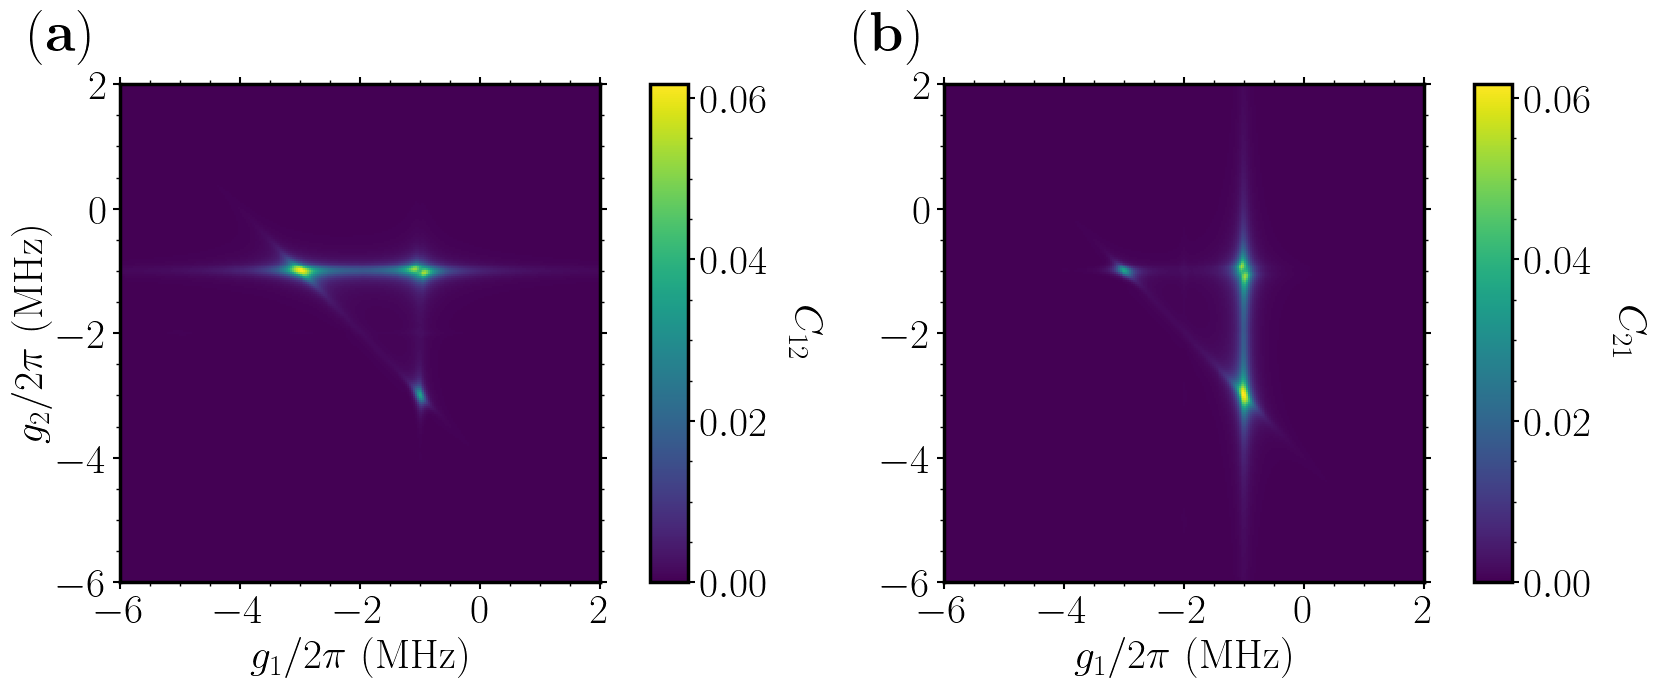

In [155]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
##############################################################
# ---- Heatmap ----
##############################################################
nrm1 = mpl.colors.Normalize(0, abs(C12_grid).max())

im1 = axes[0].pcolormesh(x_list_3, y_list_3, abs(C12_grid),
                         cmap=cm.viridis,
                         norm=nrm1,
                         shading='auto')

axes[0].set_xlabel(r'$g_1/2\pi$ (MHz)')
axes[0].set_ylabel(r'$g_2/2\pi$ (MHz)')

axes[0].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[0].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[0].set_xlim(x0, xf)
axes[0].set_ylim(y0, yf)

axes[0].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[0].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[0])

cax = divider.append_axes(
    "right",
    size="8%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label(r'$C_{12}$',
               rotation=270,
               labelpad=40)

cbar.ax.tick_params(which='both', direction='out')

##############################################################
# ---- Heatmap 2 ----
##############################################################
nrm2 = mpl.colors.Normalize(0, abs(C21_grid).max())

im2 = axes[1].pcolormesh(x_list_3, y_list_3, abs(C21_grid),
                         cmap=cm.viridis,
                         norm=nrm2,
                         shading='auto')

axes[1].set_xlabel(r'$g_1/2\pi$ (MHz)')

axes[1].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[1].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[1].set_xlim(x0, xf)
axes[1].set_ylim(y0, yf)

axes[1].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[1].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[1])

cax = divider.append_axes(
    "right",
    size="8%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im2, cax=cax)

cbar.set_label(r'$C_{21}$',
               rotation=270,
               labelpad=40)

cbar.ax.tick_params(which='both', direction='out')

#############################################################
# Panel labels
#############################################################
panel_labels = [r'$\mathbf{(a)}$',r'$\mathbf{(b)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.19,
        1.15,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )
##############################################################
# ---- Global spacing ----
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.95,
    wspace=0.45   # spacing between the TWO plots only
)

save_figure(fig, "Thesis_Figures", "chap4_sim3_connected_correlations_part1", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

### 4) Comparison between $C_\text{sym}$ and the negativity between cavity 1 and cavity 2


Saved:
Thesis_Figures\chap4_sim3_connected_correlations_part2.pdf


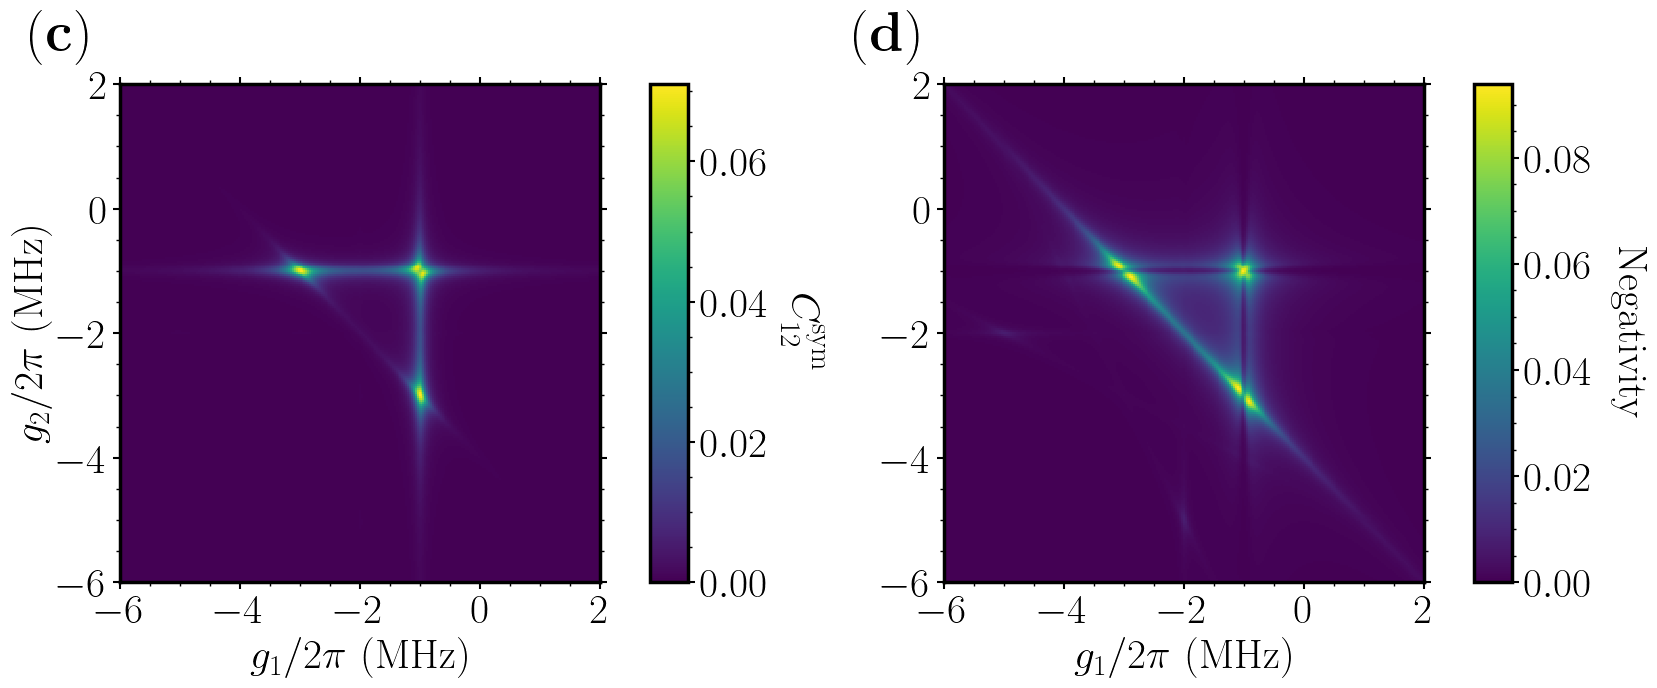

In [156]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
##############################################################
# ---- Heatmap ----
##############################################################
nrm1 = mpl.colors.Normalize(0, abs(Csym_grid).max())

im1 = axes[0].pcolormesh(x_list_3, y_list_3, abs(Csym_grid),
                         cmap=cm.viridis,
                         norm=nrm1,
                         shading='auto')

axes[0].set_xlabel(r'$g_1/2\pi$ (MHz)')
axes[0].set_ylabel(r'$g_2/2\pi$ (MHz)')

axes[0].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[0].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[0].set_xlim(x0, xf)
axes[0].set_ylim(y0, yf)

axes[0].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[0].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[0])

cax = divider.append_axes(
    "right",
    size="8%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label(r'$C^{\rm sym}_{12}$',
               rotation=270,
               labelpad=40)

cbar.ax.tick_params(which='both', direction='out')

##############################################################
# ---- Heatmap 2 ----
##############################################################
nrm2 = mpl.colors.Normalize(0, abs(negativity_grid).max())

im2 = axes[1].pcolormesh(x_list_3, y_list_3, abs(negativity_grid),
                         cmap=cm.viridis,
                         norm=nrm2,
                         shading='auto')

axes[1].set_xlabel(r'$g_1/2\pi$ (MHz)')

axes[1].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[1].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

axes[1].set_xlim(x0, xf)
axes[1].set_ylim(y0, yf)

axes[1].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[1].tick_params(axis='both', which='both', direction='out')
##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[1])

cax = divider.append_axes(
    "right",
    size="8%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im2, cax=cax)

cbar.set_label(r'Negativity',
               rotation=270,
               labelpad=40)

cbar.ax.tick_params(which='both', direction='out')

#############################################################
# Panel labels
#############################################################
panel_labels = [r'$\mathbf{(c)}$',r'$\mathbf{(d)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.19,
        1.15,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )
##############################################################
# ---- Global spacing ----
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.95,
    wspace=0.45   # spacing between the TWO plots only
)

save_figure(fig, "Thesis_Figures", "chap4_sim3_connected_correlations_part2", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

### 5) HZ Criterias


Saved:
Thesis_Figures\chap4_sim3_HZ_criteria.pdf


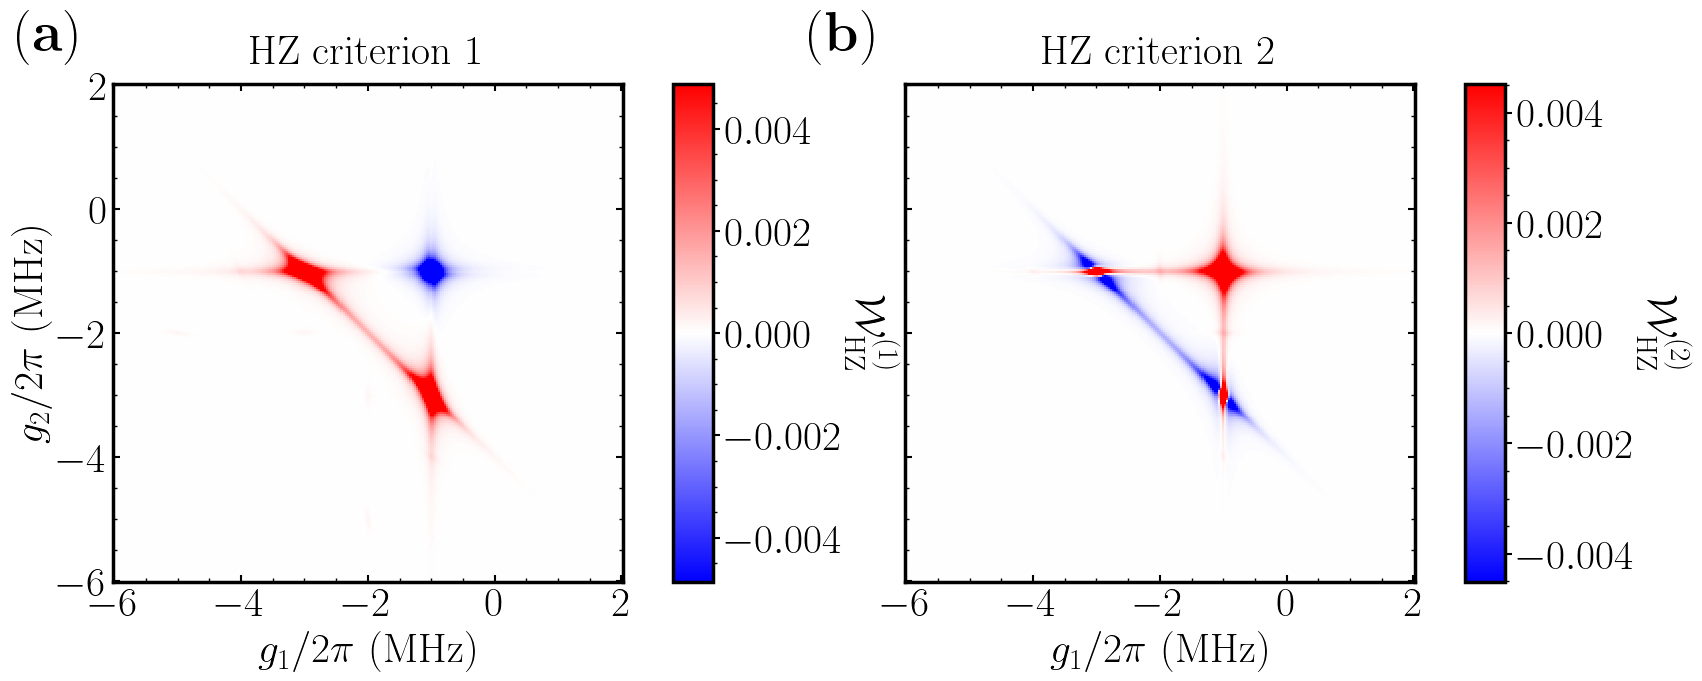

In [157]:
##############################################################
# Hillery-Zubairy criteria
##############################################################
HZ1_lim = 0.1 * nanmax(abs(HZ1_grid))
HZ2_lim = 0.1 * nanmax(abs(HZ2_grid))

if HZ1_lim == 0:
    HZ1_lim = 1

if HZ2_lim == 0:
    HZ2_lim = 1

nrm_HZ1 = mpl.colors.TwoSlopeNorm(vmin=-HZ1_lim,vcenter=0,vmax=HZ1_lim)
nrm_HZ2 = mpl.colors.TwoSlopeNorm(vmin=-HZ2_lim,vcenter=0,vmax=HZ2_lim)

fig, axes = plt.subplots(1,2,figsize=(16, 6),sharey=True)

##############################################################
# HZ criterion 1
##############################################################
im0 = axes[0].pcolormesh(x_list_3, y_list_3, HZ1_grid, shading="auto",  cmap="bwr", norm=nrm_HZ1)

axes[0].set_title(r"HZ criterion 1", pad=15)
axes[0].set_xlabel(r'$g_1/2\pi$ (MHz)')
axes[0].set_ylabel(r"$g_2/2\pi$ (MHz)")

axes[0].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[0].tick_params(axis='both', which='both', direction='in')

##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[0])

cax = divider.append_axes(
    "right",
    size="8%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im0, cax=cax)

cbar.set_label(r"$\mathcal{W}_{\mathrm{HZ}}^{(1)}$",
               rotation=270,
               labelpad=40)

cbar.ax.tick_params(which='both', direction='out')

##############################################################
# HZ criterion 2
##############################################################
im1 = axes[1].pcolormesh(x_list_3,y_list_3,HZ2_grid,shading="auto",cmap="bwr",norm=nrm_HZ2)

#if nanmin(HZ2_grid) < 0 and nanmax(HZ2_grid) > 0:
#    axes[1].contour(x_list_3,y_list_3,HZ2_grid,levels=[0],colors="black",linewidths=1,alpha=0.8,linestyles="--")

axes[1].set_title(r"HZ criterion 2",pad=15)
axes[1].set_xlabel(r'$g_1/2\pi$ (MHz)')

axes[1].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[1].tick_params(axis='both', which='both', direction='in')

##############################################################
#  ---- Colorbar settings ----
##############################################################
divider = make_axes_locatable(axes[1])

cax = divider.append_axes(
    "right",
    size="8%",  # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label(r"$\mathcal{W}_{\mathrm{HZ}}^{(2)}$",
               rotation=270,
               labelpad=40)

cbar.ax.tick_params(which='both', direction='out')

#############################################################
# Panel labels
#############################################################
panel_labels = [r'$\mathbf{(a)}$',r'$\mathbf{(b)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.19,
        1.15,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )
    
##############################################################
# ---- Global spacing ----
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.95,
    wspace=0.32   # spacing between the TWO plots only
)

save_figure(fig, "Thesis_Figures", "chap4_sim3_HZ_criteria", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

## Simulation 4

In [99]:
folder_4 = "Results\Sim4_DeltaA_vs_Ea"

data_4 = load_result(folder_4)

time_index = datetime.datetime.now().strftime("_[%Y-%m-%d]_[%Hh%Mm]")
date_index = datetime.datetime.now().strftime("_[%Y-%m-%d]")

x_list_4 = array(data_4[0])           # Delta_a_list (in MHz)
y_list_4 = array(data_4[1]) * 1e3     # E_alist (in MHz, but multiplied for 1e3 to convert to kHz for better redability)
rho_grid = data_4[2]                  # rho_ss grid [Ea index, Delta_a index]

N_a = int(data_4[3])         # Fock dimension Mode 1/A
N_b = int(data_4[4])         # Fock dimension Mode 2/B
N_r = int(data_4[5])         # Fock dimension Mechanical Mode/R
wr = data_4[6]               # Mechanical Frequency

computation_time = data_4[7]

print(f"Computation time: {computation_time:.2f} seconds")
print(f"Computation time: {computation_time/60:.2f} minutes")
print(f"Computation time: {computation_time/3600:.2f} hours")

##############################################################
Ny = len(y_list_4)
Nx = len(x_list_4)
##############################################################
a = tensor(destroy(N_a), qeye(N_b), qeye(N_r))
b = tensor(qeye(N_a), destroy(N_b), qeye(N_r))
r = tensor(qeye(N_a), qeye(N_b), destroy(N_r))
Na = a.dag() * a
Nb = b.dag() * b
NaNb = Na * Nb

#Results_ga10_gb10_[2026-07-13]_[21h49m].npy
#Results_ga10_gb3_[2026-07-14]_[10h23m].npy
#Results_ga10_gb3_[2026-07-14]_[19h05m].npy N = 5 4 5


Available files:
[0] Results_ga10_gb3_[2026-07-14]_[19h05m].npy
[1] Results_ga10_gb3_[2026-07-14]_[10h23m].npy
[2] Results_ga3_gb10_[2026-07-14]_[05h34m].npy
[3] Results_ga10_gb10_[2026-07-13]_[21h49m].npy
[4] Results_ga10_gb10_[2026-07-13]_[16h48m].npy
[5] Results_ga10_gb10_[2026-07-13]_[15h49m].npy
[6] Results_ga10_gb10_[2026-07-13]_[15h30m].npy
[7] Results_ga10_gb3_[2026-07-13]_[15h00m].npy
[8] Results_ga3_gb10_[2026-07-13]_[13h54m].npy
[9] Results_ga3_gb10_[2026-07-13]_[13h13m].npy
[10] Results_ga10_gb10_[2026-07-13]_[11h58m].npy
[11] Results_ga5_gb5_[2026-07-13]_[11h45m].npy
[12] Results_ga3_gb3_[2026-07-13]_[11h32m].npy
[13] Results_ga10_gb3_[2026-07-13]_[11h19m].npy
[14] Results_ga3_gb10_[2026-07-13]_[11h06m].npy
[15] Results_[2026-07-10]_[03h16m].npy
[16] Results_[2026-07-09]_[18h14m].npy
[17] Results_[2026-07-09]_[17h13m].npy
[18] Results_[2026-07-09]_[02h18m].npy

Loading: Results\Sim4_DeltaA_vs_Ea\Results_ga10_gb3_[2026-07-14]_[10h23m].npy

Computation time: 17346.74 second

### 1) Second-order correlation function dependence with drive strength and detuning

In [100]:
##############################################################
# Compute g_a^(2)(0)
##############################################################
g2A_grid = empty((Ny, Nx), dtype=float)
na_grid  = empty((Ny, Nx), dtype=float)

n_threshold = 1e-12  # To avoid division by very small photon number

a2_corr = a.dag() * a.dag() * a * a

for i in range(Ny):          # E_a index
    for j in range(Nx):      # Delta_a index

        rho = rho_grid[i, j]

        na = real_if_close(expect(Na, rho))
        numerator = real_if_close(expect(a2_corr, rho))

        na_grid[i, j] = na

        if na > n_threshold:
            g2A_grid[i, j] = numerator / na**2
        else:
            g2A_grid[i, j] = nan

z_plot_g2A = ma.masked_invalid(g2A_grid)

g2_min = nanmin(g2A_grid)
g2_max = nanmax(g2A_grid)

print(f"Minimum g_a^(2)(0): {g2_min:.4g}")
print(f"Maximum g_a^(2)(0): {g2_max:.4g}")

Minimum g_a^(2)(0): 0.005056
Maximum g_a^(2)(0): 101.2



Saved:
Thesis_Figures\chap4_g2A_DeltaA_vs_Ea_part1.pdf


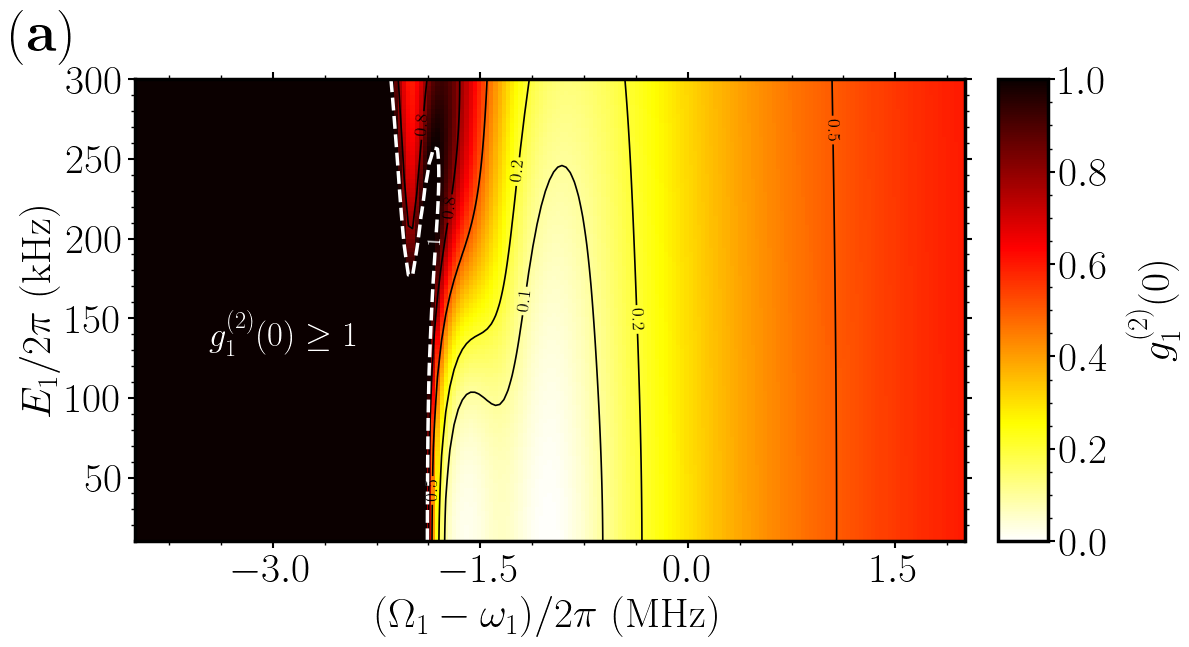

In [105]:
##############################################################
# Plot
##############################################################
fig, ax = plt.subplots(figsize=(10, 7))

cmap = mpl.colormaps["hot_r"].copy() #  "hot_r" or "viridis" for alt color
cmap.set_bad(color="lightgray")

im = ax.pcolormesh(x_list_4,y_list_4,z_plot_g2A,shading="auto",cmap=cmap,
                   vmin=0,vmax=1)

##############################################################
# Contour lines
##############################################################
levels_black = [0.1, 0.2, 0.5, 0.8] # Levels
levels_black = [lv for lv in levels_black if g2_min <= lv <= g2_max]

# Black contour for g_1^(2)(0) < 1 levels
if len(levels_black) > 0:
    contour_black = ax.contour(x_list_4, y_list_4, g2A_grid,
                               levels=levels_black,colors='black',linewidths=1.2,linestyles='solid')

    ax.clabel(contour_black,inline=True,fontsize=13,fmt='%0.1f')

# White dashed contour for g_1^(2)(0) = 1
if g2_min <= 1 <= g2_max:
    contour_white = ax.contour(x_list_4, y_list_4, g2A_grid,
                               levels=[1],colors='white',linewidths=2.5,linestyles='dashed')

    ax.clabel(contour_white,inline=True,fontsize=14,fmt={1: r'$1$'})

else:
    print("No g_1^(2)(0) = 1 contour found in this parameter range.")

##############################################################
# Labels and style
##############################################################
ax.set_xlabel(r"$(\Omega_1 - \omega_1)/2\pi$ (MHz)")
ax.set_ylabel(r"$E_1/2\pi$ (kHz)")

ax.set_xlim(-4, x_list_4[-1])
ax.set_ylim(y_list_4[0], y_list_4[-1])

ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

ax.tick_params(axis='both', which='both', direction='out')

#=====================================================
# Top colorbar without changing heatmap frame size
#=====================================================
#cax = ax.inset_axes([0.0, 1.06, 1.0, 0.1])  #[left position, bottom position, thickness, height]
cax = ax.inset_axes([1.04, 0.0, 0.06, 1.0]) # vertical

#cbar = fig.colorbar(im,cax=cax, orientation='horizontal') #horizontal
cbar = fig.colorbar(im,cax=cax, orientation='vertical') #vertical

cbar.set_label(r'$g_1^{(2)}(0)$',labelpad=12)

#cbar.ax.xaxis.set_ticks_position('top')      # horizontal
#cbar.ax.xaxis.set_label_position('top')      # horizontal
cbar.ax.yaxis.set_ticks_position('right')     # vertical  
cbar.ax.yaxis.set_label_position('right')     # vertical

cbar.ax.tick_params(axis='x', which='both', direction='out')    # horizontal
cbar.ax.tick_params(axis='y', which='both', direction='out')    # vertical

#=====================================================
# Overlay label
#=====================================================
ax.text(0.09, 0.5, r'$g_1^{(2)}(0) \geq 1$',transform=ax.transAxes,ha='left',va='top',fontsize=25,color='white')

ax.text(-0.15, 1.15, r'$\mathbf{(a)}$',transform=ax.transAxes,ha='left',va='top',fontsize=40,color='black')
#=====================================================
# Global spacing
#=====================================================
plt.subplots_adjust(
    left=0.12,
    right=0.95,
    bottom=0.12,
    top=0.78
)
##############################################################
# Save figure
##############################################################
# Thesis figures at loc ='Thesis_Figures'
# others at loc = folder_4 + "\Figures"
save_figure(fig, 'Thesis_Figures', 'chap4_g2A_DeltaA_vs_Ea_part1', formats=["pdf"], time_stamp=False, dpi=300)

plt.show()


In [106]:
##############################################################
# Compute cross-correlation g_12^(2)(0)
##############################################################
g2AB_grid = empty((Ny, Nx), dtype=float)

na_grid = empty((Ny, Nx), dtype=float)
nb_grid = empty((Ny, Nx), dtype=float)
nanb_grid = empty((Ny, Nx), dtype=float)

n_threshold = 1e-12

for i in range(Ny):
    for j in range(Nx):

        rho = rho_grid[i, j]

        na = expect(Na, rho)
        nb = expect(Nb, rho)
        nanb = expect(NaNb, rho)

        na = real_if_close(na)
        nb = real_if_close(nb)
        nanb = real_if_close(nanb)

        na_grid[i, j] = na
        nb_grid[i, j] = nb
        nanb_grid[i, j] = nanb

        if na > n_threshold and nb > n_threshold:
            g2AB_grid[i, j] = nanb / (na * nb)
        else:
            g2AB_grid[i, j] = nan

z_plot_g2AB = ma.masked_invalid(g2AB_grid)

g2AB_min = nanmin(g2AB_grid)
g2AB_max = nanmax(g2AB_grid)

print(f"Minimum g_ab^(2)(0): {g2AB_min:.4g}")
print(f"Maximum g_ab^(2)(0): {g2AB_max:.4g}")

Minimum g_ab^(2)(0): 0.03895
Maximum g_ab^(2)(0): 2.853



Saved:
Thesis_Figures\chap4_g2A_DeltaA_vs_Ea_part2.pdf


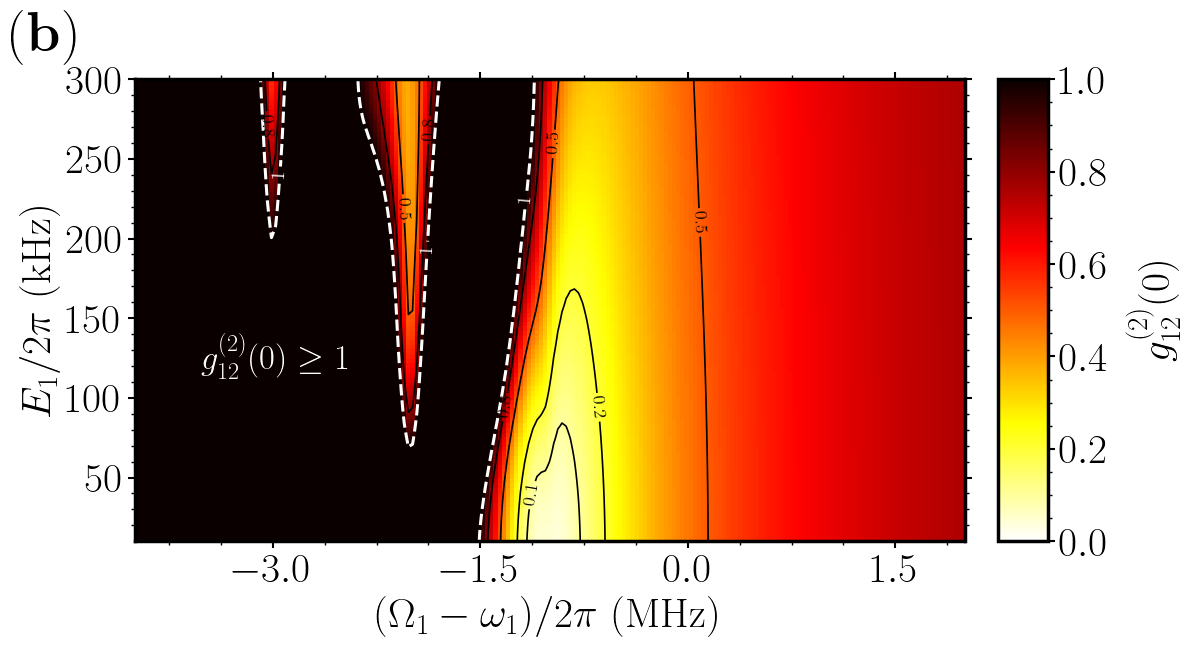

In [107]:
##############################################################
# Plot
##############################################################
fig, ax = plt.subplots(figsize=(10, 7))

cmap = mpl.colormaps["hot_r"].copy() #  "hot_r" or "viridis" for alt color
cmap.set_bad(color="lightgray")

im = ax.pcolormesh(x_list_4,y_list_4,z_plot_g2AB,shading="auto",cmap=cmap,
                   vmin=0,vmax=1)

##############################################################
# Contour lines
##############################################################
levels_black = [0.1, 0.2, 0.5, 0.8] # Levels
levels_black = [lv for lv in levels_black if g2AB_min <= lv <= g2AB_max]

# Black contour for g_1^(2)(0) < 1 levels
if len(levels_black) > 0:
    contour_black = ax.contour(x_list_4, y_list_4, g2AB_grid,
                               levels=levels_black,colors='black',linewidths=1.2,linestyles='solid')

    ax.clabel(contour_black,inline=True,fontsize=13,fmt='%0.1f')

# White dashed contour for g_1^(2)(0) = 1
if g2AB_min <= 1 <= g2AB_max:
    contour_white = ax.contour(x_list_4, y_list_4, g2AB_grid,
                               levels=[1],colors='white',linewidths=2.2,linestyles='dashed')

    ax.clabel(contour_white,inline=True,fontsize=14,fmt={1: r'$1$'})

else:
    print("No g_12^(2)(0) = 1 contour found in this parameter range.")

##############################################################
# Labels and style
##############################################################
ax.set_xlabel(r"$(\Omega_1 - \omega_1)/2\pi$ (MHz)")
ax.set_ylabel(r"$E_1/2\pi$ (kHz)")

ax.set_xlim(-4, x_list_4[-1])
ax.set_ylim(y_list_4[0], y_list_4[-1])

ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

ax.tick_params(axis='both', which='both', direction='out')

#=====================================================
# Top colorbar without changing heatmap frame size
#=====================================================
#cax = ax.inset_axes([0.0, 1.06, 1.0, 0.1])  #[left position, bottom position, thickness, height]
cax = ax.inset_axes([1.04, 0.0, 0.06, 1.0]) # vertical

#cbar = fig.colorbar(im,cax=cax, orientation='horizontal') #horizontal
cbar = fig.colorbar(im,cax=cax, orientation='vertical') #vertical

cbar.set_label(r'$g_{12}^{(2)}(0)$',labelpad=12)

#cbar.ax.xaxis.set_ticks_position('top')      # horizontal
#cbar.ax.xaxis.set_label_position('top')      # horizontal
cbar.ax.yaxis.set_ticks_position('right')     # vertical  
cbar.ax.yaxis.set_label_position('right')     # vertical

cbar.ax.tick_params(axis='x', which='both', direction='out')    # horizontal
cbar.ax.tick_params(axis='y', which='both', direction='out')    # vertical

#=====================================================
# Overlay label
#=====================================================
ax.text(0.08, 0.45, r'$g_{12}^{(2)}(0) \geq 1$',transform=ax.transAxes,ha='left',va='top',fontsize=25,color='white')

ax.text(-0.15, 1.15, r'$\mathbf{(b)}$',transform=ax.transAxes,ha='left',va='top',fontsize=40,color='black')
#=====================================================
# Global spacing
#=====================================================
plt.subplots_adjust(
    left=0.12,
    right=0.95,
    bottom=0.12,
    top=0.78
)
##############################################################
# Save figure
##############################################################
# Thesis figures at loc ='Thesis_Figures'
# others at loc = folder_4 + "\Figures"
save_figure(fig,'Thesis_Figures','chap4_g2A_DeltaA_vs_Ea_part2', formats=["pdf"], time_stamp=False, dpi=300)

plt.show()


#### 1.A) Population for the highest cutoff energy level

In [166]:
##############################################################
# Population of the last Fock level for A, B, and R
##############################################################
# Grids to store the last-level populations
pA_last_grid = empty((Ny, Nx), dtype=float)
pB_last_grid = empty((Ny, Nx), dtype=float)
pR_last_grid = empty((Ny, Nx), dtype=float)

for i in range(Ny):
    for j in range(Nx):
        rho = rho_grid[i, j]

        # Population of the highest level
        pA_last_grid[i, j] = real_if_close(rho.ptrace(0).diag()[-1])
        pB_last_grid[i, j] = real_if_close(rho.ptrace(1).diag()[-1])
        pR_last_grid[i, j] = real_if_close(rho.ptrace(2).diag()[-1])

##############################################################
# Use same color scale for all three panels
##############################################################
all_max = nanmax([
    nanmax(pA_last_grid),
    nanmax(pB_last_grid),
    nanmax(pR_last_grid)
])

vmin = 0
vmax = all_max

print(f"Max last-level population across all panels: {all_max:.4g}")

Max last-level population across all panels: 0.03508


Figure not saved.


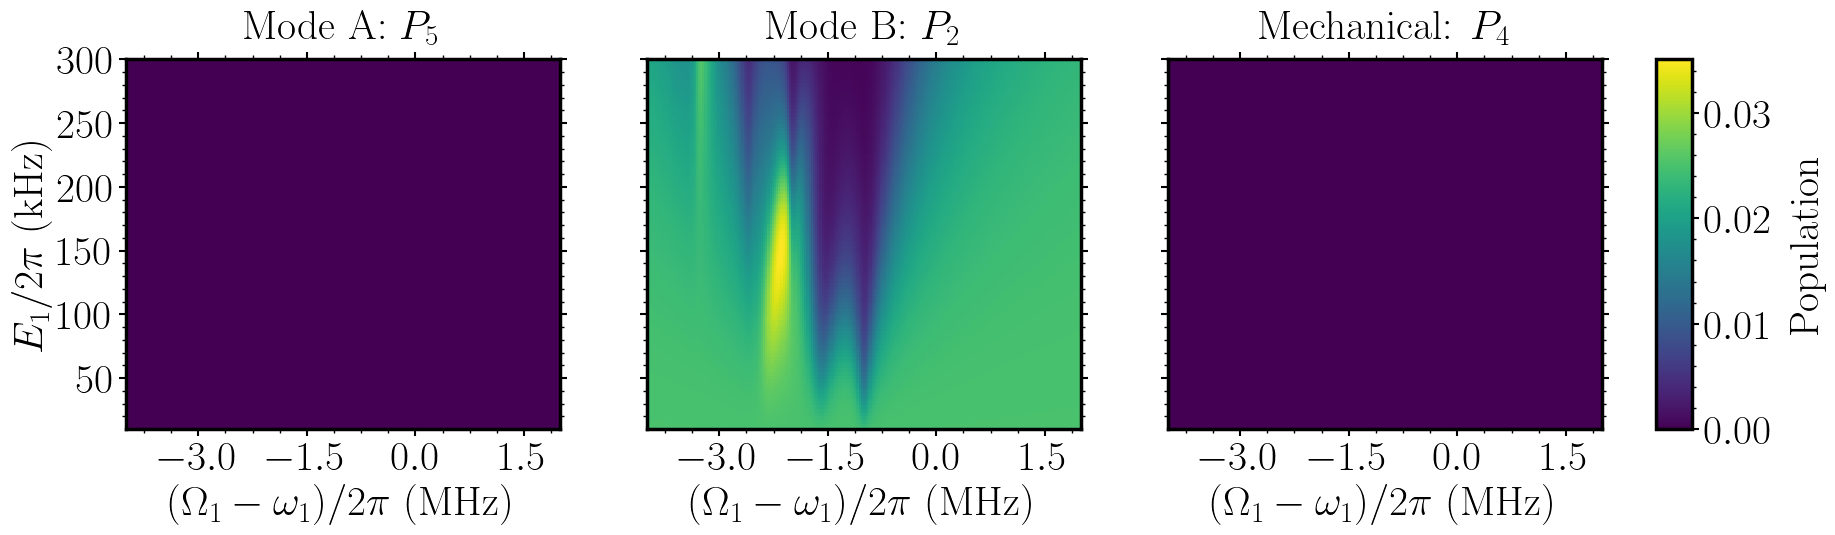

In [ ]:
##############################################################
# Plot
##############################################################
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

cmap = mpl.colormaps["viridis"].copy()

im0 = axes[0].pcolormesh(x_list_4, y_list_4, pA_last_grid,
                         shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)

im1 = axes[1].pcolormesh(x_list_4, y_list_4, pB_last_grid,
                         shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)

im2 = axes[2].pcolormesh(x_list_4, y_list_4, pR_last_grid,
                         shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)

##############################################################
# Labels and style
##############################################################
axes[0].set_title(rf"Mode A: $P_{N_a-1}$", pad = 15)
axes[1].set_title(rf"Mode B: $P_{N_b-1}$", pad = 15)
axes[2].set_title(rf"Mechanical: $P_{N_r-1}$", pad = 15)

for ax in axes:
    ax.set_xlabel(r"$(\Omega_1 - \omega_1)/2\pi$ (MHz)")
    ax.set_xlim(x_list_4[0], x_list_4[-1])

    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

    ax.tick_params(axis='both', which='both', direction='out')

axes[0].set_ylabel(r"$E_1/2\pi$ (kHz)")
axes[0].set_ylim(y_list_4[0], y_list_4[-1])

##############################################################
# One shared colorbar for all three plots
##############################################################
cax = fig.add_axes([0.93, 0.14, 0.020, 0.74])
#                 [left, bottom, width, height]

cbar = fig.colorbar(
    im2,
    cax=cax,
    orientation='vertical'
)

cbar.set_label("Population", labelpad=12)
cbar.ax.tick_params(which='both', direction='out')

##############################################################
# Global spacing
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.90,
    bottom=0.14,
    top=0.88,
    wspace=0.20
)
##############################################################
# Save figure
##############################################################
save_figure(fig, folder_4 + "\Figures", "LastLevelPopulations_ABR", formats=["pdf"], time_stamp=False, dpi=300) # Not in the thesis figures, only in the simulation folder

plt.show()

## Simulation 5

In [89]:
folder_5 = "Results\Sim5_ReconstructedField"

data_5 = load_result(folder_5)

time_index = datetime.datetime.now().strftime("_[%Y-%m-%d]_[%Hh%Mm]")
date_index = datetime.datetime.now().strftime("_[%Y-%m-%d]")

x_list_5 =         data_5[0]         # Delta_a_list
y_list_5 =         data_5[1] * 1e3   # E_a_list
a1_ss_grid =       data_5[2]         # a1_ss grid
a1_rec_grid =      data_5[3]         # a1_rec grid
V1_grid =          data_5[4]         # voltage grid
abs_err_grid =     data_5[5]
rel_err_grid =     data_5[6]
N_a =              data_5[7]         # Fock dimension Mode 1/A
N_b =              data_5[8]         # Fock dimension Mode 2/B
N_r =              data_5[9]         # Fock dimension Mechanical Mode/R
wr  =              data_5[10]        # Mechanical Frequency
kappa_ex_a =       data_5[11]
G_a =              data_5[12]
Ns =               data_5[13]
noise_sigma =      data_5[14]
computation_time = data_5[15]

abs_ss_grid = abs(a1_ss_grid)
abs_rec_grid = abs(a1_rec_grid)

print(f"Computation time: {computation_time:.2f} seconds")
print(f"Computation time: {computation_time/60:.2f} minutes")
print(f"Computation time: {computation_time/3600:.2f} hours")


Available files:
[0] VoltageReconstruction_a1_ga10_gb10_[2026-07-17]_[09h44m].npy
[1] VoltageReconstruction_a1_ga10_gb10_[2026-07-17]_[09h38m].npy
[2] VoltageReconstruction_a1_ga10_gb10_[2026-07-17]_[09h33m].npy
[3] VoltageReconstruction_a1_ga10_gb10_[2026-07-16]_[09h23m].npy



Loading: Results\Sim5_ReconstructedField\VoltageReconstruction_a1_ga10_gb10_[2026-07-17]_[09h44m].npy

Computation time: 130.82 seconds
Computation time: 2.18 minutes
Computation time: 0.04 hours



Saved:
Thesis_Figures\chap4_a1_field_reconstruction_part1.pdf


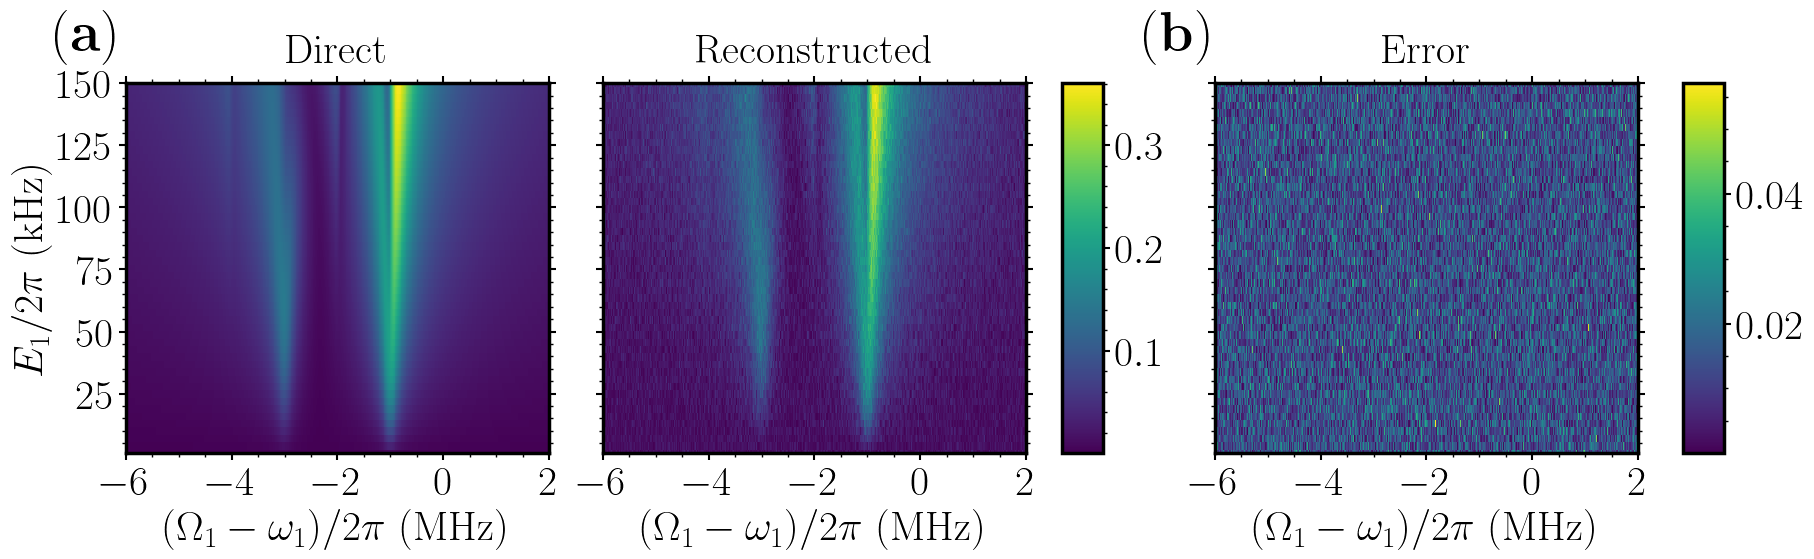

In [96]:
#========================================
# Plots
#========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

cmap = mpl.colormaps["viridis"].copy()

im0 = axes[0].pcolormesh(x_list_5, y_list_5, abs_ss_grid,
                         shading="auto", cmap=cmap)

im1 = axes[1].pcolormesh(x_list_5, y_list_5, abs_rec_grid,
                         shading="auto", cmap=cmap)

im2 = axes[2].pcolormesh(x_list_5, y_list_5, abs_err_grid,
                         shading="auto", cmap=cmap)

#========================================
# Labels and style
#========================================
axes[0].set_title(rf"Direct", pad = 15)
axes[1].set_title(rf"Reconstructed", pad = 15)
axes[2].set_title(rf"Error", pad = 15)

for ax in axes:
    ax.set_xlabel(r"$(\Omega_1 - \omega_1)/2\pi$ (MHz)")
    ax.set_xlim(x_list_5[0], x_list_5[-1])

    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

    ax.tick_params(axis='both', which='both', direction='out')

axes[0].set_ylabel(r"$E_1/2\pi$ (kHz)")
axes[0].set_ylim(y_list_5[0], y_list_5[-1])

#========================================
# One shared colorbar for first two plots
#========================================
cax1 = fig.add_axes([0.6, 0.14, 0.023, 0.74])
#                   [left, bottom, width, height]

cbar1 = fig.colorbar(im1, cax=cax1, orientation='vertical')

cbar1.ax.tick_params(which='both', direction='out')
#========================================
# Second colorbar
#========================================
cax2 = fig.add_axes([0.945, 0.14, 0.023, 0.74])
#                   [left, bottom, width, height]

cbar2 = fig.colorbar(im2, cax=cax2, orientation='vertical')

cbar2.ax.tick_params(which='both', direction='out')
#========================================
# Global spacing
#========================================
plt.subplots_adjust(
    left=0.08,
    right=0.92,
    bottom=0.14,
    top=0.88,
    wspace=0.21
)

axes[0].set_position([0.080, 0.14, 0.235, 0.74])
axes[1].set_position([0.345, 0.14, 0.235, 0.74])
axes[2].set_position([0.685, 0.14, 0.235, 0.74])

#=====================================================
# Overlay labels
#=====================================================
panel_labels = [r'$\mathbf{(a)}$','',r'$\mathbf{(b)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.17,
        1.2,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )
#========================================
# Save figure
#========================================
# Thesis figures at loc ='Thesis_Figures'
# others at loc = folder_5 + "\Figures"
save_figure(fig, 'Thesis_Figures', "chap4_a1_field_reconstruction_part1", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

In [97]:
#=====================================================
# Quadratures of the intracavity field
#=====================================================
I_ss  = real(a1_ss_grid)
Q_ss  = imag(a1_ss_grid)

I_rec = real(a1_rec_grid)
Q_rec = imag(a1_rec_grid)

I_err = I_rec - I_ss
Q_err = Q_rec - Q_ss

##############################################################
# Reconstructed I/Q quadratures: heatmaps + cuts
##############################################################
I_rec = real(a1_rec_grid)
Q_rec = imag(a1_rec_grid)



Saved:
Thesis_Figures\chap4_a1_field_reconstruction_part2.pdf


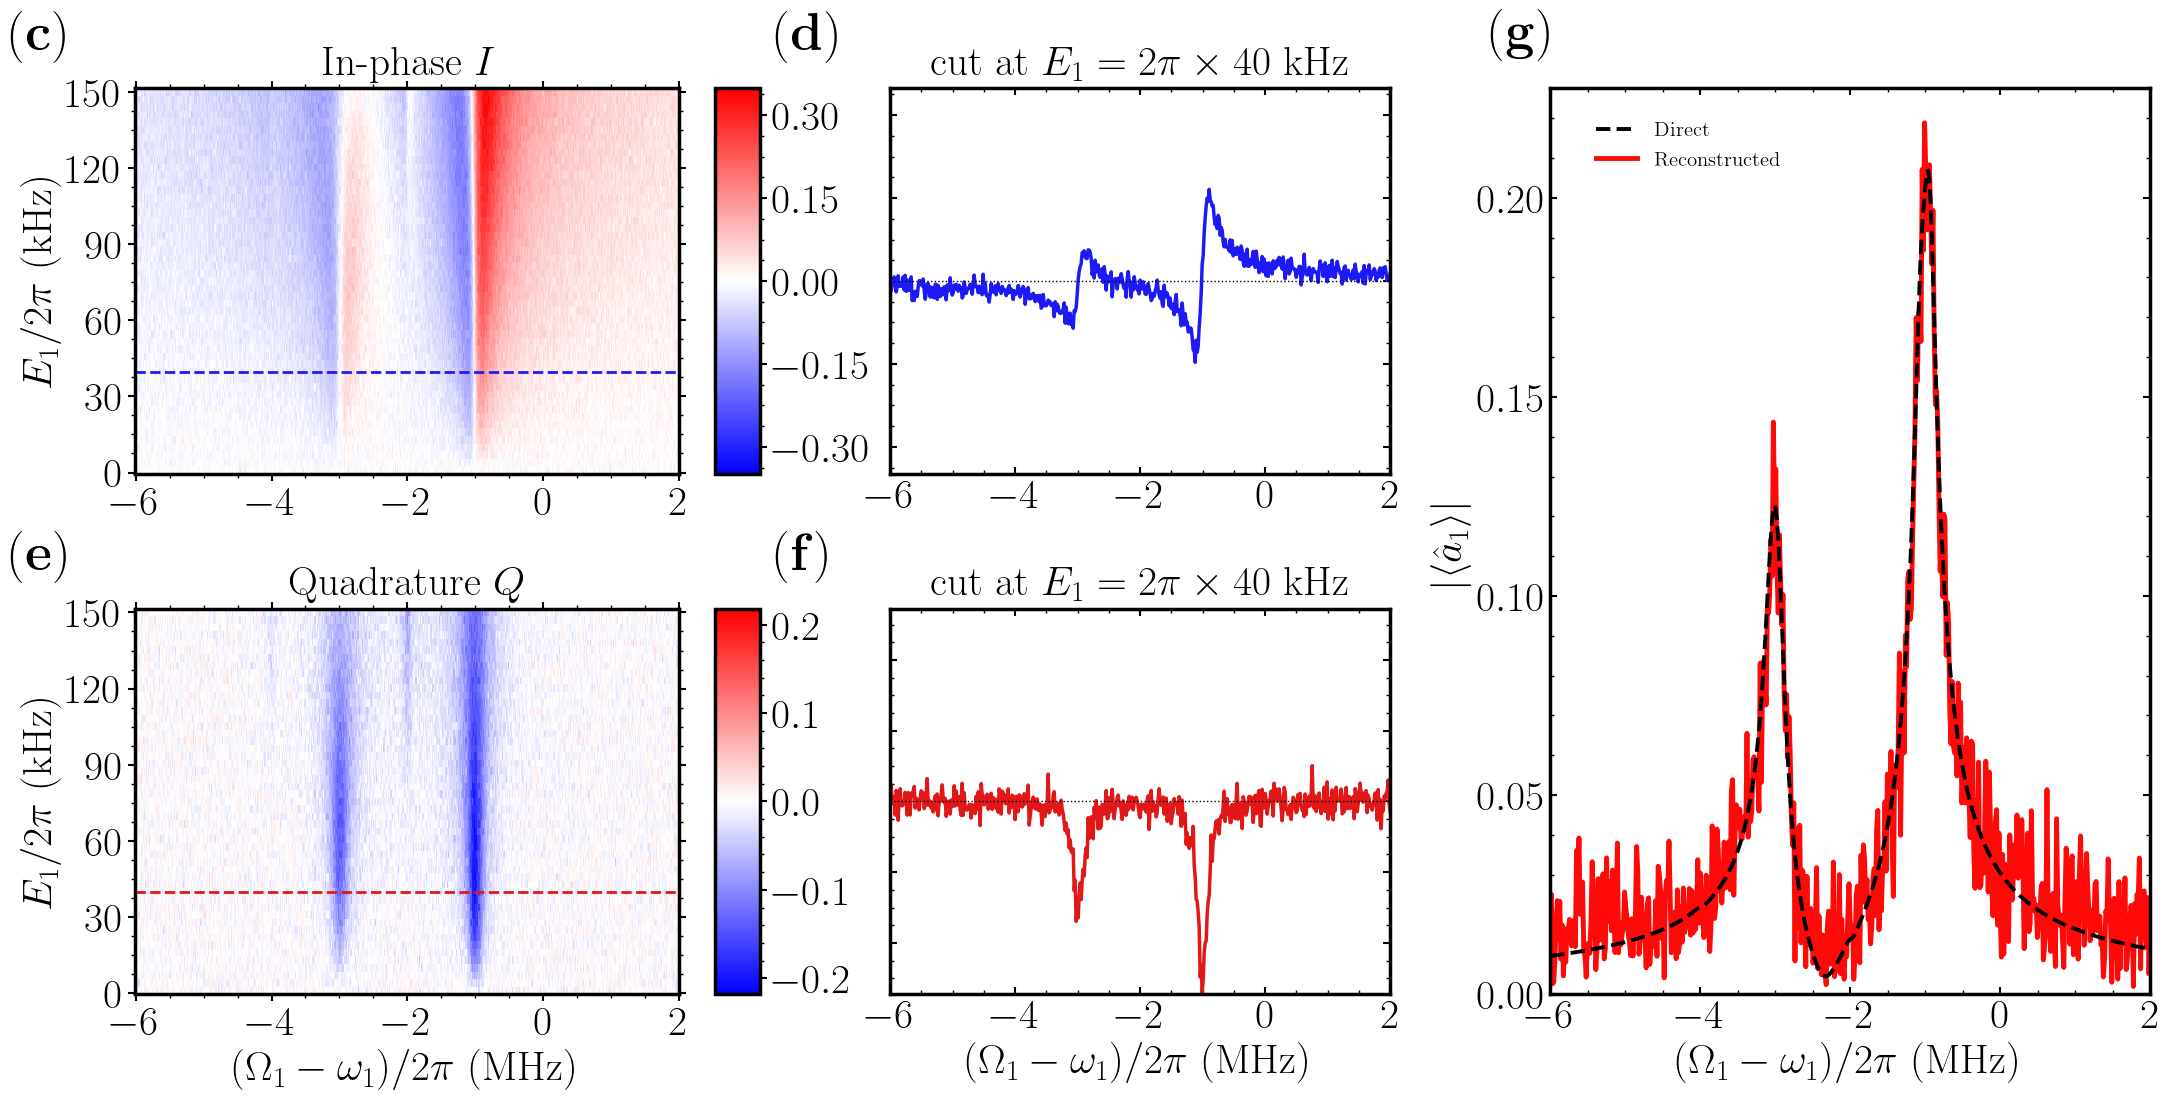

In [98]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
E_a_cut = 40

if E_a_cut < min(y_list_5) or E_a_cut > max(y_list_5):
    E_a_cut = y_list_5[len(y_list_5)//2]

i_cut = argmin(abs(y_list_5 - E_a_cut))
E_a_cut_used = y_list_5[i_cut]
#=====================================================
# Symmetric limits for colorbar and cut y-axis
#=====================================================
I_lim = max(abs(nanmin(I_rec)), abs(nanmax(I_rec)))
Q_lim = max(abs(nanmin(Q_rec)), abs(nanmax(Q_rec)))

norm_I = mpl.colors.Normalize(vmin=-I_lim, vmax=I_lim)
norm_Q = mpl.colors.Normalize(vmin=-Q_lim, vmax=Q_lim)

color_I = "#1E1AF7"
color_Q = "#E21717"

##############################################################
# Plot layout
##############################################################
fig = plt.figure(figsize=(26, 12))

gs = GridSpec(
    2, 4,
    figure=fig,
    width_ratios=[1.25, 1., -0.2, 1.20], #width_ratios=[1.25, 1.15, 0.12, 1.30],
    height_ratios=[1, 1],
    wspace=0.32,
    hspace=0.35
)

gsI = GridSpecFromSubplotSpec(
    1, 2,
    subplot_spec=gs[0, 0],
    width_ratios=[0.6, 0.05],
    wspace=0.12
)

gsQ = GridSpecFromSubplotSpec(
    1, 2,
    subplot_spec=gs[1, 0],
    width_ratios=[0.6, 0.05],
    wspace=0.12
)

axI    = fig.add_subplot(gsI[0, 0])
caxI   = fig.add_subplot(gsI[0, 1])

axQ    = fig.add_subplot(gsQ[0, 0])
caxQ   = fig.add_subplot(gsQ[0, 1])

axIcut = fig.add_subplot(gs[0, 1])
axQcut = fig.add_subplot(gs[1, 1])

axComp = fig.add_subplot(gs[:, 3])

##############################################################
#  I & Q heatmaps
##############################################################
imI = axI.pcolormesh(x_list_5, y_list_5, I_rec,
                     cmap = 'bwr',
                     shading="auto",
                     norm=norm_I)

axI.axhline(y_list_5[i_cut], linestyle="--", linewidth=2, color=color_I)
axI.set_title(r'In-phase $I$', pad=10)
axI.set_ylabel(r"$E_1/2\pi$ (kHz)")
axI.xaxis.set_major_locator(MaxNLocator(nbins=5))
axI.yaxis.set_major_locator(MaxNLocator(nbins=6))
axI.tick_params(axis='both', which='both', direction='out')
###############
# Colorbar I
###############
cbarI = fig.colorbar(imI, cax=caxI, orientation='vertical')

cbarI.ax.yaxis.set_ticks_position('right')
cbarI.ax.yaxis.set_label_position('right')
cbarI.ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
cbarI.ax.tick_params(axis='y', which='both', direction='out')
##############################
imQ = axQ.pcolormesh(x_list_5, y_list_5, Q_rec,
                     cmap = 'bwr',
                     shading="auto",
                     norm=norm_Q)

axQ.axhline(y_list_5[i_cut], linestyle="--", linewidth=2, color=color_Q)
axQ.set_title(r'Quadrature $Q$', pad=10)
axQ.set_ylabel(r"$E_1/2\pi$ (kHz)")
axQ.set_xlabel(r"$(\Omega_1 - \omega_1)/2\pi$ (MHz)")
axQ.xaxis.set_major_locator(MaxNLocator(nbins=5))
axQ.yaxis.set_major_locator(MaxNLocator(nbins=6))
axQ.tick_params(axis='both', which='both', direction='out')
###############
# Colorbar Q
###############
cbarQ = fig.colorbar(imQ, cax=caxQ, orientation='vertical')
cbarQ.ax.yaxis.set_ticks_position('right')
cbarQ.ax.yaxis.set_label_position('right')
cbarQ.ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
cbarQ.ax.tick_params(axis='y', which='both', direction='out')
##############################################################
#  I Cut
##############################################################
axIcut.plot(x_list_5,I_rec[i_cut, :],
                linestyle="-",
                color=color_I)
axIcut.axhline(0, linestyle=":", linewidth=1, color='black')
axIcut.set_title(rf'cut at $E_1 = 2\pi\times{E_a_cut:.0f}$ kHz', pad=10)
axIcut.set_xlim(x_list_5[0], x_list_5[-1])
axIcut.set_ylim(-I_lim, I_lim)
axIcut.tick_params(axis='y', labelleft=False)
axIcut.xaxis.set_major_locator(MaxNLocator(nbins=5))
axIcut.yaxis.set_major_locator(MaxNLocator(nbins=6))
axIcut.tick_params(axis='both', which='both', direction='in')
##############################################################
#  Q cut
##############################################################
axQcut.plot(x_list_5, Q_rec[i_cut, :],
            linestyle="-",
            color=color_Q)

axQcut.axhline(0, linestyle=":", linewidth=1, color='black')

axQcut.set_xlabel(r"$(\Omega_1 - \omega_1)/2\pi$ (MHz)")
axQcut.set_title(rf'cut at $E_1 = 2\pi\times{E_a_cut:.0f}$ kHz', pad=10)
axQcut.set_xlim(x_list_5[0], x_list_5[-1])
axQcut.set_ylim(-Q_lim, Q_lim)
axQcut.tick_params(axis='y', labelleft=False)
axQcut.xaxis.set_major_locator(MaxNLocator(nbins=5))
axQcut.yaxis.set_major_locator(MaxNLocator(nbins=6))
axQcut.tick_params(axis='both', which='both', direction='in')

##############################################################
#  Comparison
##############################################################
color_2  = "#ff0909"
color_1  = "#000000"

linewidth_1 = 2.8
linewidth_2 = 3.5

axComp.plot(x_list_5, abs_ss_grid[i_cut, :],
             linewidth=linewidth_1,
             linestyle='--',
             color=color_1,
             label=r'Direct',
             zorder = 10)

axComp.plot(x_list_5, abs_rec_grid[i_cut, :],
             linewidth=linewidth_2,
             linestyle='-',
             color=color_2,
             label=r'Reconstructed')

axComp.set_xlabel(r"$(\Omega_1 - \omega_1)/2\pi$ (MHz)")
axComp.set_ylabel(r"$|\langle \hat{a}_1\rangle|$")

axComp.set_xlim(x_list_5[0], x_list_5[-1])
axComp.set_ylim(0, 1.1*max(abs_ss_grid[i_cut, :]))

axComp.tick_params(axis='both',which='both',direction='in')

axComp.legend(loc='lower center', bbox_to_anchor=(0.23, 0.89), ncol=1,frameon=False)


panel_labels = [r'$\mathbf{(c)}$', r'$\mathbf{(d)}$', r'$\mathbf{(e)}$',r'$\mathbf{(f)}$']

for ax, label in zip([axI,axIcut, axQ, axQcut], panel_labels):
    ax.text(-0.23, 1.2, label, transform=ax.transAxes, ha='left', va='top', fontsize=38,color='black')

ax.text(1.2, 2.554, r'$\mathbf{(g)}$', transform=ax.transAxes, ha='left', va='top', fontsize=38,color='black')

save_figure(fig,'Thesis_Figures','chap4_a1_field_reconstruction_part2',formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

## Simulation 6


Available files:
[0] BellState_[2026-08-12]_[19h24m].npy
[1] BellState_[2026-08-12]_[16h42m].npy
[2] BellState_[2026-08-12]_[13h29m].npy
[3] BellState_[2026-08-12]_[11h13m].npy
[4] BellState_[2026-08-12]_[09h02m].npy
[5] BellState_[2026-08-12]_[08h54m].npy
[6] BellState_[2026-08-12]_[08h22m].npy
[7] BellState_[2026-08-12]_[03h19m].npy
[8] BellState_[2026-08-11]_[19h44m].npy
[9] BellState_[2026-08-11]_[18h04m].npy
[10] BellState_[2026-08-11]_[17h02m].npy
[11] BellState_[2026-08-11]_[16h38m].npy
[12] BellState_[2026-08-11]_[16h16m].npy

Loading: Results\Sim6_BellState_E_vs_Delta\BellState_[2026-08-12]_[19h24m].npy

Computation time: 9652.14 seconds
Computation time: 160.87 minutes
Computation time: 2.68 hours


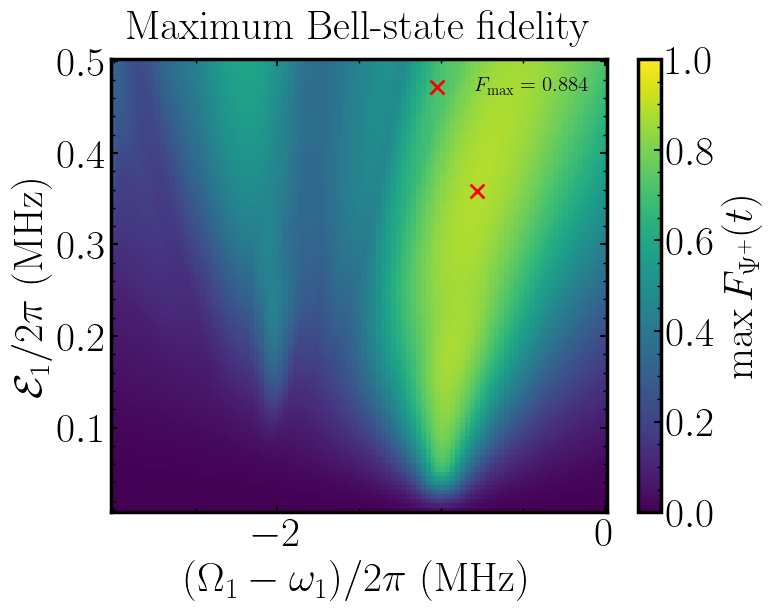

In [261]:
folder_6 = "Results\Sim6_BellState_E_vs_Delta"

data_6 = load_result(folder_6)

time_index = datetime.datetime.now().strftime("_[%Y-%m-%d]_[%Hh%Mm]")
date_index = datetime.datetime.now().strftime("_[%Y-%m-%d]")

N_a = int(data_6[10])         # Fock dimension Mode 1/A
N_b = int(data_6[11])         # Fock dimension Mode 2/B
N_r = int(data_6[12])         # Fock dimension Mechanical Mode/R
wr = data_6[15]               # Mechanical Frequency

delta_list = data_6[0]      # x_list
E_list     = data_6[1]      # y_list

Fmax_grid  = data_6[2]
tBell_grid = data_6[3]

leakage_grid = data_6[4]
HZ_grid      = data_6[5]

P11_grid = data_6[6]
P20_grid = data_6[7]
P02_grid = data_6[8]

best_trajectory = data_6[9]

computation_time = data_6[22]

print(f"Computation time: {computation_time:.2f} seconds")
print(f"Computation time: {computation_time/60:.2f} minutes")
print(f"Computation time: {computation_time/3600:.2f} hours")

#====================================
# Finds the best point
k_best = unravel_index(argmax(Fmax_grid),Fmax_grid.shape)

E_best     = E_list[k_best[0]]
delta_best = delta_list[k_best[1]]

F_best = Fmax_grid[k_best]

#====================================
# Plot
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.pcolormesh(delta_list, E_list, Fmax_grid, shading="auto", cmap="viridis", vmin=0, vmax=1)

ax.scatter(delta_best,E_best,marker="x",s=100,color="red", linewidth=2, label=rf"$F_{{\max}}={F_best:.3f}$")

ax.set_xlabel(r"$(\Omega_1-\omega_1)/2\pi$ (MHz)")
ax.set_ylabel(r"$\mathcal{E}_1/2\pi$ (MHz)")

ax.set_title(r"Maximum Bell-state fidelity", pad = 15)

ax.legend()

cbar = fig.colorbar(im,ax=ax)

cbar.set_label(r"$\max F_{\Psi^+}(t)$")

plt.show()

### 1) Max Bell-state fidelity heatmap comparison with and without losses - part 1


Saved:
Thesis_Figures\chap4_Bell_state_fidelity_part1.pdf


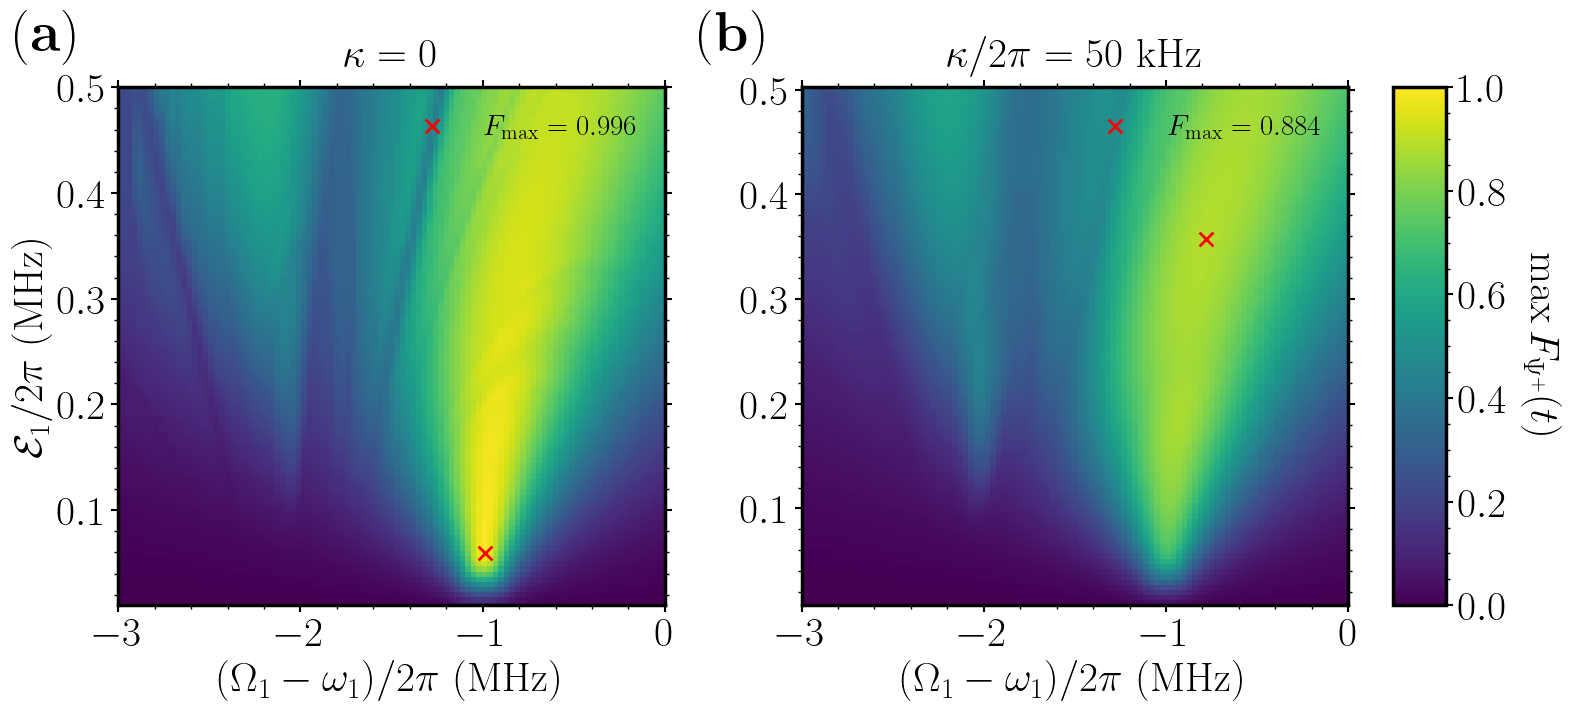

In [270]:
# loads
#  data without losses
# BellState_[2026-08-12]_[03h19m].npy
#BellState_[2026-08-12]_[16h42m].npy
data_6_lossless = load(r'Results\Sim6_BellState_E_vs_Delta\BellState_[2026-08-12]_[16h42m].npy',
                  allow_pickle=True)

# loads data with losses
# BellState_[2026-08-12]_[08h22m].npy --> kappa = 50 kHz
#BellState_[2026-08-12]_[19h24m].npy
data_6_lossy = load(r'Results\Sim6_BellState_E_vs_Delta\BellState_[2026-08-12]_[19h24m].npy',
                  allow_pickle=True)
#######
Fmax_grid_lossless  = data_6_lossless[2]
tBell_grid_lossless = data_6_lossless[3]

leakage_grid_lossless = data_6_lossless[4]
HZ_grid_lossless      = data_6_lossless[5]

P11_grid_lossless = data_6_lossless[6]
P20_grid_lossless = data_6_lossless[7]
P02_grid_lossless = data_6_lossless[8]

best_trajectory_lossless = data_6_lossless[9]
#######
Fmax_grid_lossy  = data_6_lossy[2]
tBell_grid_lossy = data_6_lossy[3]

leakage_grid_lossy = data_6_lossy[4]
HZ_grid_lossy      = data_6_lossy[5]

P11_grid_lossy = data_6_lossy[6]
P20_grid_lossy = data_6_lossy[7]
P02_grid_lossy = data_6_lossy[8]

best_trajectory_lossy = data_6_lossy[9]
#====================================
# Finds the best point 
k_best_lossless = unravel_index(argmax(Fmax_grid_lossless),Fmax_grid_lossless.shape)
k_best_lossy = unravel_index(argmax(Fmax_grid_lossy),Fmax_grid_lossy.shape)

E_best_lossless     = E_list[k_best_lossless[0]]
delta_best_lossless = delta_list[k_best_lossless[1]]
F_best_lossless = Fmax_grid_lossless[k_best_lossless]

E_best_lossy     = E_list[k_best_lossy[0]]
delta_best_lossy = delta_list[k_best_lossy[1]]
F_best_lossy = Fmax_grid_lossy[k_best_lossy]
#====================================
# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

im0 = axes[0].pcolormesh(delta_list, E_list, Fmax_grid_lossless,
                         shading="auto", cmap="viridis", vmin=0, vmax=1)

im1 = axes[1].pcolormesh(delta_list, E_list, Fmax_grid_lossy,
                         shading="auto", cmap="viridis", vmin=0, vmax=1)

axes[0].scatter(delta_best_lossless, E_best_lossless, marker="x", s=100, color="red", linewidth=2, label=rf"$F_{{\max}}={F_best_lossless:.3f}$")
axes[1].scatter(delta_best_lossy, E_best_lossy, marker="x", s=100, color="red", linewidth=2, label=rf"$F_{{\max}}={F_best_lossy:.3f}$")

##############################################################
# Labels and style
##############################################################
axes[0].set_title(rf"$\kappa = 0$", pad = 15)
axes[1].set_title(rf"$\kappa/2\pi = 50$ kHz", pad = 15)

for ax in axes:
    ax.set_xlabel(r"$(\Omega_1 - \omega_1)/2\pi$ (MHz)")
    ax.set_xlim(delta_list[0], delta_list[-1])

    ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

    ax.tick_params(axis='both', which='both', direction='out')

    ax.legend(fontsize=21)

axes[0].set_ylabel(r"$\mathcal{E}_1/2\pi$ (MHz)")
axes[0].set_ylim(E_list[0], E_list[-1])

##############################################################
# One shared colorbar for all three plots
##############################################################
cax = fig.add_axes([0.93, 0.14, 0.035, 0.74])
#                 [left, bottom, width, height]

cbar = fig.colorbar(
    im1,
    cax=cax,
    orientation='vertical'
)

cbar.set_label(r"$\max F_{\Psi^+}(t)$", rotation=270, labelpad=40)
cbar.ax.tick_params(which='both', direction='out')
#############################################################
# Panel labels
#############################################################
panel_labels = [r'$\mathbf{(a)}$',r'$\mathbf{(b)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.19,
        1.15,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )
##############################################################
# Global spacing
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.90,
    bottom=0.14,
    top=0.88,
    wspace=0.25
)
##############################################################
# Save figure
##############################################################
save_figure(fig, "Thesis_Figures", "chap4_Bell_state_fidelity_part1", formats=["pdf"], time_stamp=False, dpi=300) 

plt.show()

### 2) Time-evolution for populations, fidelity and entanglement witness HZ (without losses)


Saved:
Thesis_Figures\chap4_Bell_state_time_evolutions_lossless.pdf


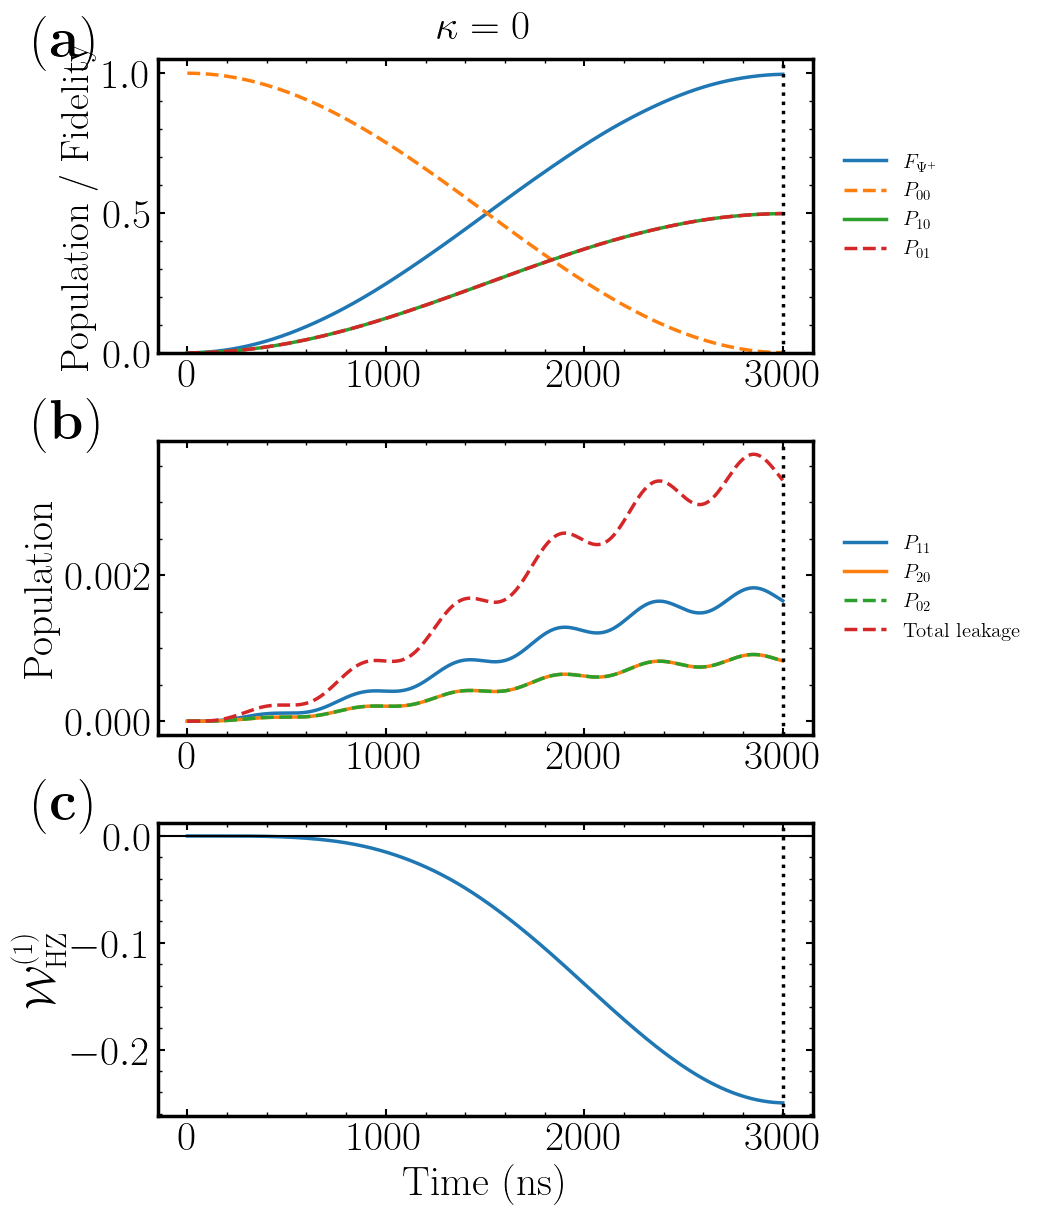

In [268]:
tlist = best_trajectory_lossless["tlist"]

fidelity = best_trajectory_lossless["fidelity"]

P00 = best_trajectory_lossless["P00_t"]
P10 = best_trajectory_lossless["P10_t"]
P01 = best_trajectory_lossless["P01_t"]

P11 = best_trajectory_lossless["P11_t"]
P20 = best_trajectory_lossless["P20_t"]
P02 = best_trajectory_lossless["P02_t"]

leakage = best_trajectory_lossless["leakage_t"]

coherence = best_trajectory_lossless["coherence_t"]

W_HZ = best_trajectory_lossless["W_HZ_t"]

##############################################################
# Plot
##############################################################
fig, axes = plt.subplots(3, 1, figsize=(10, 14), sharex=False)

fig.subplots_adjust(right=0.78, hspace=0.30)

##############################################################
# Desired-state dynamics
##############################################################
axes[0].plot(tlist, fidelity, linestyle='-', label=r"$F_{\Psi^+}$")

axes[0].plot(tlist, P00, linestyle='--', label=r"$P_{00}$")
axes[0].plot(tlist, P10, linestyle='-', label=r"$P_{10}$")
axes[0].plot(tlist, P01, linestyle='--', label=r"$P_{01}$")

axes[0].axvline(best_trajectory_lossless["t_max_fidelity"], linestyle=':', color='black')

axes[0].set_ylabel("Population / Fidelity", fontsize=28)

axes[0].set_ylim(0, 1.05)

axes[0].set_title(r"$\kappa = 0$", pad=15)

axes[0].legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)
##############################################################
# Blocked states
##############################################################
axes[1].plot(tlist, P11, linestyle='-', label=r"$P_{11}$")
axes[1].plot(tlist, P20, linestyle='-', label=r"$P_{20}$")
axes[1].plot(tlist, P02, linestyle='--', label=r"$P_{02}$")

axes[1].plot(tlist, leakage, linestyle='--', label="Total leakage")

axes[1].axvline(best_trajectory_lossless["t_max_fidelity"], linestyle=':', color='black')

axes[2].set_xlabel(r"Time (ns)")
axes[1].set_ylabel("Population")

axes[1].legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)


##############################################################
# HZ witness
##############################################################
axes[2].plot(tlist, W_HZ, linestyle='-')

axes[2].axhline(0, linestyle='-', color='black', linewidth=1.5)

axes[2].axvline(best_trajectory_lossless["t_max_fidelity"], linestyle=':', color='black')

axes[2].set_ylabel(r"$\mathcal{W}_{\rm HZ}^{(1)}$")


#############################################################
# Panel labels
#############################################################
panel_labels = [r'$\mathbf{(a)}$', r'$\mathbf{(b)}$', r'$\mathbf{(c)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.19,
        1.15,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )


##############################################################
# Save figure
##############################################################
save_figure(fig, "Thesis_Figures", "chap4_Bell_state_time_evolutions_lossless", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

### 3) Time-evolution for populations, fidelity and entanglement witness HZ (with losses)


Saved:
Thesis_Figures\chap4_Bell_state_time_evolutions_lossy.pdf


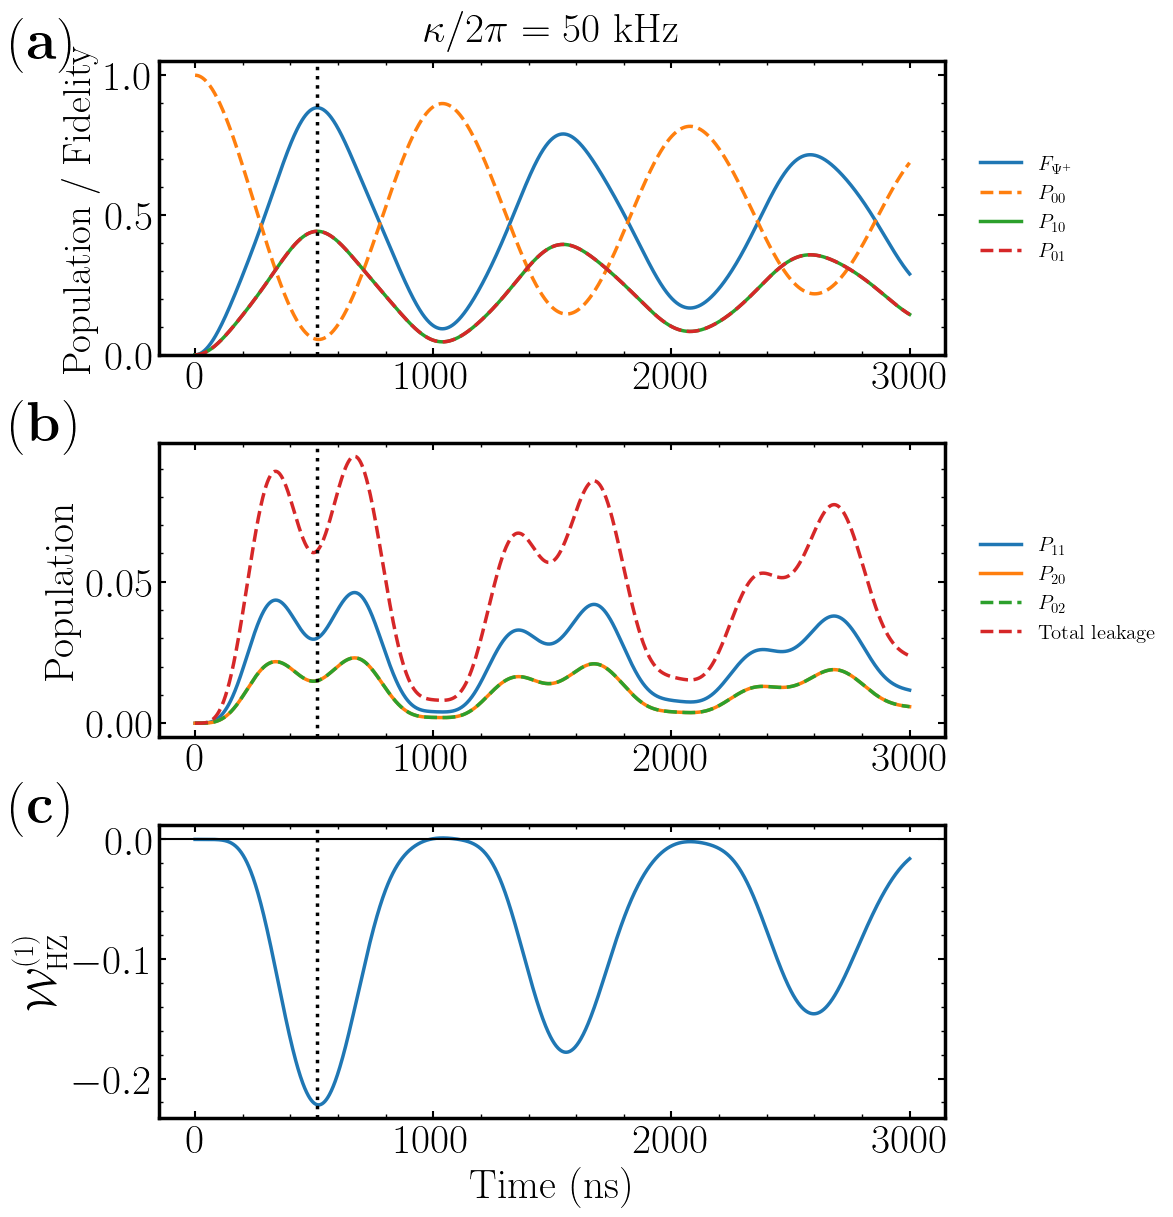

In [269]:
tlist = best_trajectory_lossy["tlist"]

fidelity = best_trajectory_lossy["fidelity"]

P00 = best_trajectory_lossy["P00_t"]
P10 = best_trajectory_lossy["P10_t"]
P01 = best_trajectory_lossy["P01_t"]

P11 = best_trajectory_lossy["P11_t"]
P20 = best_trajectory_lossy["P20_t"]
P02 = best_trajectory_lossy["P02_t"]

leakage = best_trajectory_lossy["leakage_t"]

coherence = best_trajectory_lossy["coherence_t"]

W_HZ = best_trajectory_lossy["W_HZ_t"]

##############################################################
# Plot
##############################################################
fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=False)

fig.subplots_adjust(right=0.78, hspace=0.30)

##############################################################
# Desired-state dynamics
##############################################################
axes[0].plot(tlist, fidelity, linestyle='-', label=r"$F_{\Psi^+}$")

axes[0].plot(tlist, P00, linestyle='--', label=r"$P_{00}$")
axes[0].plot(tlist, P10, linestyle='-', label=r"$P_{10}$")
axes[0].plot(tlist, P01, linestyle='--', label=r"$P_{01}$")

axes[0].axvline(best_trajectory_lossy["t_max_fidelity"], linestyle=':', color='black')

axes[0].set_ylabel("Population / Fidelity", fontsize=28)

axes[0].set_ylim(0, 1.05)

axes[0].set_title(r"$\kappa/2\pi = 50$ kHz", pad=15)

axes[0].legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)
##############################################################
# Blocked states
##############################################################
axes[1].plot(tlist, P11, linestyle='-', label=r"$P_{11}$")
axes[1].plot(tlist, P20, linestyle='-', label=r"$P_{20}$")
axes[1].plot(tlist, P02, linestyle='--', label=r"$P_{02}$")

axes[1].plot(tlist, leakage, linestyle='--', label="Total leakage")

axes[1].axvline(best_trajectory_lossy["t_max_fidelity"], linestyle=':', color='black')

axes[2].set_xlabel(r"Time (ns)")
axes[1].set_ylabel("Population")

axes[1].legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)


##############################################################
# HZ witness
##############################################################
axes[2].plot(tlist, W_HZ, linestyle='-')

axes[2].axhline(0, linestyle='-', color='black', linewidth=1.5)

axes[2].axvline(best_trajectory_lossy["t_max_fidelity"], linestyle=':', color='black')

axes[2].set_ylabel(r"$\mathcal{W}_{\rm HZ}^{(1)}$")


#############################################################
# Panel labels
#############################################################
panel_labels = [r'$\mathbf{(a)}$', r'$\mathbf{(b)}$', r'$\mathbf{(c)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.19,
        1.15,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )


##############################################################
# Save figure
##############################################################
save_figure(fig, "Thesis_Figures", "chap4_Bell_state_time_evolutions_lossy", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

### 4) Time-evolution for both cases


Saved:
Thesis_Figures\chap4_Bell_state_time_evolutions_both.pdf


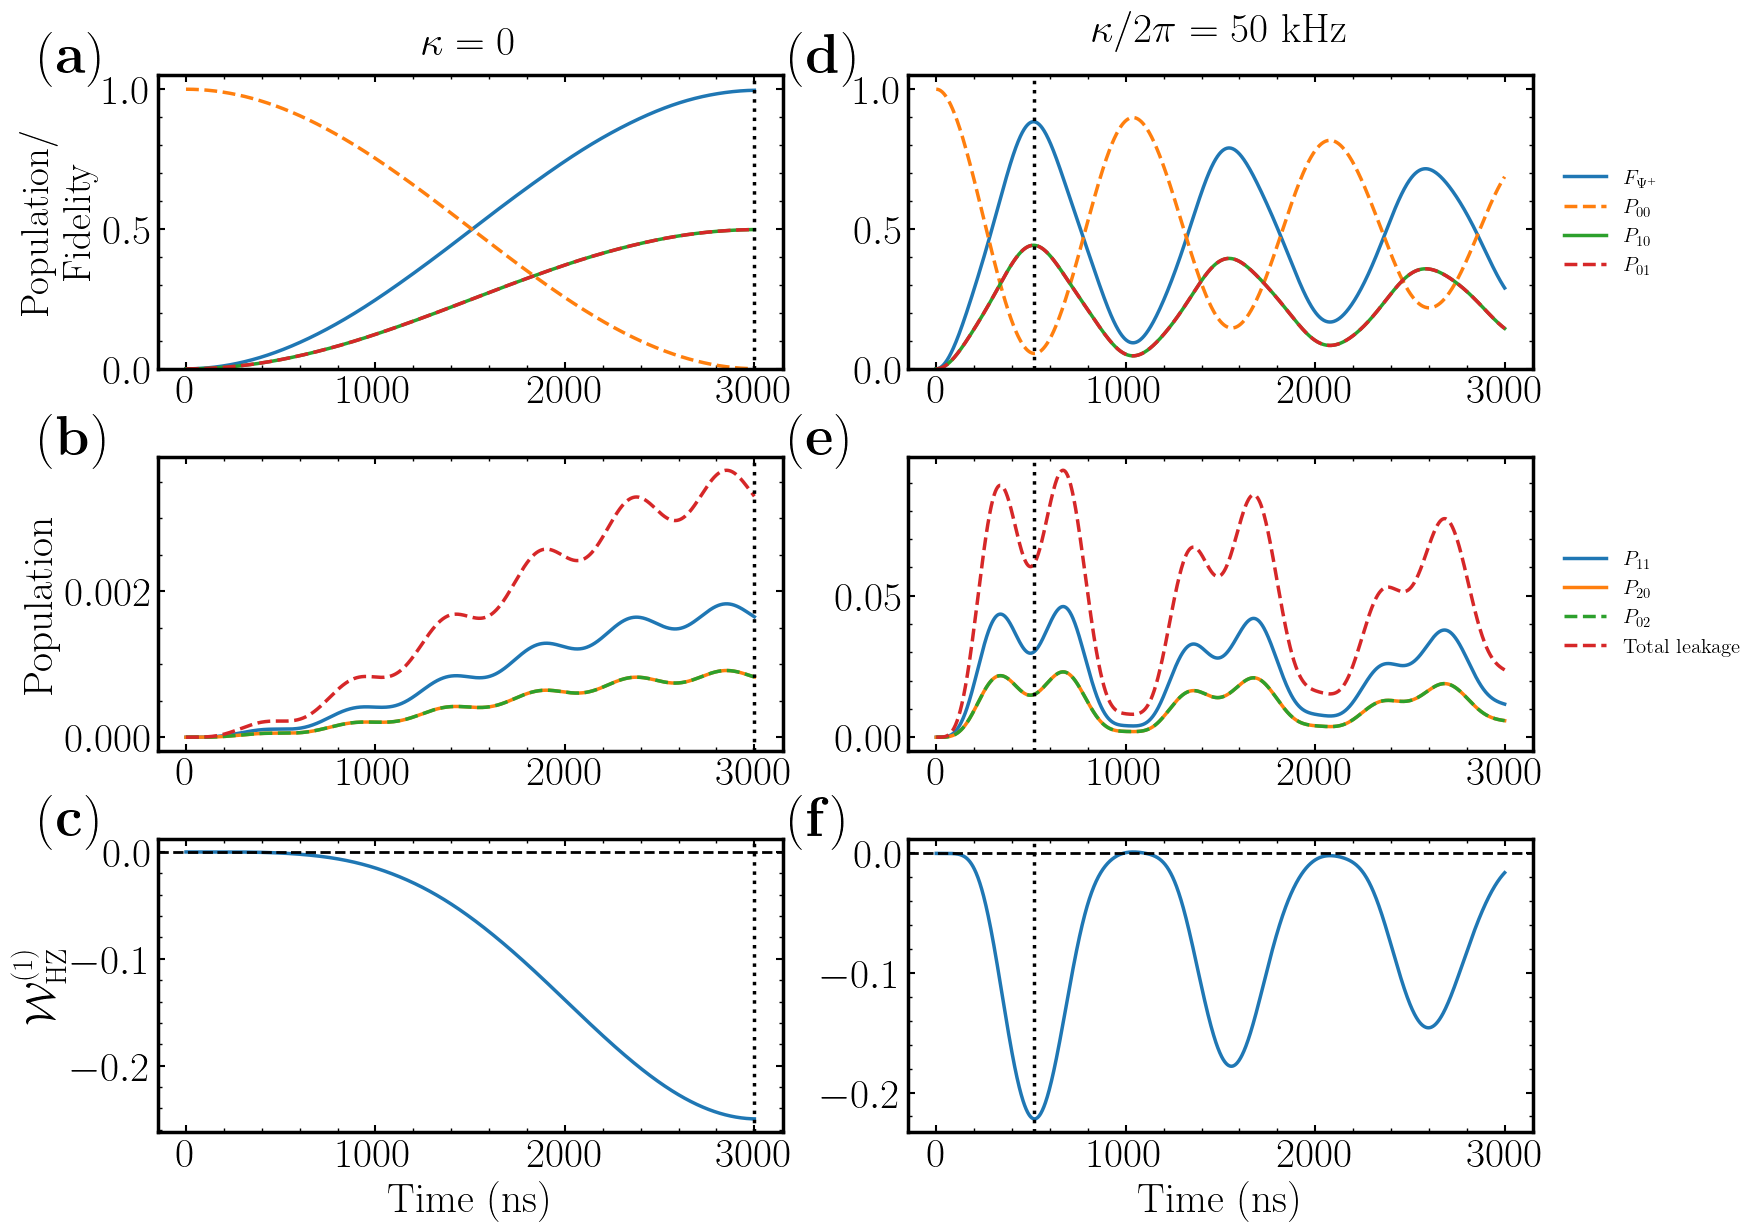

In [265]:
tlist = best_trajectory_lossless["tlist"]

fidelity = best_trajectory_lossless["fidelity"]

P00 = best_trajectory_lossless["P00_t"]
P10 = best_trajectory_lossless["P10_t"]
P01 = best_trajectory_lossless["P01_t"]

P11 = best_trajectory_lossless["P11_t"]
P20 = best_trajectory_lossless["P20_t"]
P02 = best_trajectory_lossless["P02_t"]

leakage = best_trajectory_lossless["leakage_t"]

coherence = best_trajectory_lossless["coherence_t"]

W_HZ = best_trajectory_lossless["W_HZ_t"]

##############################################################
# Plot
##############################################################
fig, axes = plt.subplots(3, 2, figsize=(21, 14), sharex=False)

colors = mpl.colormaps["tab10"].colors

fig.subplots_adjust(right=0.78, hspace=0.30)
##############################################################
# Desired-state dynamics
##############################################################
axes[0, 0].plot(tlist, fidelity, linestyle='-',color=colors[0], label=r"$F_{\Psi^+}$")

axes[0, 0].plot(tlist, P00, linestyle='--', color=colors[1], label=r"$P_{00}$")
axes[0, 0].plot(tlist, P10, linestyle='-', color=colors[2], label=r"$P_{10}$")
axes[0, 0].plot(tlist, P01, linestyle='--', color=colors[3], label=r"$P_{01}$")

axes[0, 0].axvline(best_trajectory_lossless["t_max_fidelity"], linestyle=':', color='black')

axes[0, 0].set_ylabel("Population/\nFidelity", fontsize=28)

axes[0, 0].set_ylim(0, 1.05)

axes[0, 0].set_title(r"$\kappa = 0$", pad=15)

#axes[0, 0].legend(loc='center left',bbox_to_anchor=(1.02, 0.5))

##############################################################
# Blocked states
##############################################################
axes[1, 0].plot(tlist, P11, linestyle='-', color=colors[0], label=r"$P_{11}$")
axes[1, 0].plot(tlist, P20, linestyle='-', color=colors[1], label=r"$P_{20}$")
axes[1, 0].plot(tlist, P02, linestyle='--', color=colors[2], label=r"$P_{02}$")

axes[1, 0].plot(tlist, leakage, linestyle='--', color=colors[3], label="Total leakage")

axes[1, 0].axvline(best_trajectory_lossless["t_max_fidelity"], linestyle=':', color='black')

axes[2, 0].set_xlabel(r"Time (ns)")
axes[1, 0].set_ylabel("Population")

#axes[1, 0].legend(loc='center left',bbox_to_anchor=(1.02, 0.5))
##############################################################
# HZ witness
##############################################################
axes[2, 0].plot(tlist, W_HZ, linestyle='-', color=colors[0])

axes[2, 0].axhline(0, linestyle='--', color='black', linewidth=2.0)

axes[2, 0].axvline(best_trajectory_lossless["t_max_fidelity"], linestyle=':', color='black')

axes[2, 0].set_ylabel(r"$\mathcal{W}_{\rm HZ}^{(1)}$")

tlist = best_trajectory_lossy["tlist"]
#############################################################

fidelity = best_trajectory_lossy["fidelity"]

P00 = best_trajectory_lossy["P00_t"]
P10 = best_trajectory_lossy["P10_t"]
P01 = best_trajectory_lossy["P01_t"]

P11 = best_trajectory_lossy["P11_t"]
P20 = best_trajectory_lossy["P20_t"]
P02 = best_trajectory_lossy["P02_t"]

leakage = best_trajectory_lossy["leakage_t"]

coherence = best_trajectory_lossy["coherence_t"]

W_HZ = best_trajectory_lossy["W_HZ_t"]

##############################################################
# Desired-state dynamics
##############################################################
axes[0,1].plot(tlist, fidelity, linestyle='-', color=colors[0], label=r"$F_{\Psi^+}$")

axes[0,1].plot(tlist, P00, linestyle='--', color=colors[1], label=r"$P_{00}$")
axes[0,1].plot(tlist, P10, linestyle='-', color=colors[2], label=r"$P_{10}$")
axes[0,1].plot(tlist, P01, linestyle='--', color=colors[3], label=r"$P_{01}$")

axes[0,1].axvline(best_trajectory_lossy["t_max_fidelity"], linestyle=':', color='black')

#axes[0,1].set_ylabel("Population / Fidelity", fontsize=28)

axes[0,1].set_ylim(0, 1.05)

axes[0,1].set_title(r"$\kappa/2\pi = 50$ kHz", pad=25)

axes[0,1].legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)
##############################################################
# Blocked states
##############################################################
axes[1,1].plot(tlist, P11, linestyle='-', color=colors[0], label=r"$P_{11}$")
axes[1,1].plot(tlist, P20, linestyle='-', color=colors[1], label=r"$P_{20}$")
axes[1,1].plot(tlist, P02, linestyle='--', color=colors[2], label=r"$P_{02}$")

axes[1,1].plot(tlist, leakage, linestyle='--', color=colors[3], label="Total leakage")

axes[1,1].axvline(best_trajectory_lossy["t_max_fidelity"], linestyle=':', color='black')

axes[2,1].set_xlabel(r"Time (ns)")
#axes[1,1].set_ylabel("Population")

axes[1,1].legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)
##############################################################
# HZ witness
##############################################################
axes[2,1].plot(tlist, W_HZ, linestyle='-', color=colors[0])

axes[2,1].axhline(0, linestyle='--', color='black', linewidth=2.0)

axes[2,1].axvline(best_trajectory_lossy["t_max_fidelity"], linestyle=':', color='black')

#axes[2,1].set_ylabel(r"$\mathcal{W}_{\rm HZ}^{(1)}$")

#############################################################
# Panel labels
#############################################################
panel_labels = [r'$\mathbf{(a)}$', r'$\mathbf{(d)}$', r'$\mathbf{(b)}$',r'$\mathbf{(e)}$', r'$\mathbf{(c)}$', r'$\mathbf{(f)}$']

for ax, label in zip(axes.flat, panel_labels):
    ax.text(
        -0.19,
        1.15,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )
##############################################################
# Save figure
##############################################################
save_figure(fig, "Thesis_Figures", "chap4_Bell_state_time_evolutions_both", formats=["pdf"], time_stamp=False, dpi=300)

plt.show()

### 5) Max Bell-state fidelity heatmap comparison with and without losses - part 2


Saved:
Thesis_Figures\chap4_Bell_state_fidelity_part2.pdf


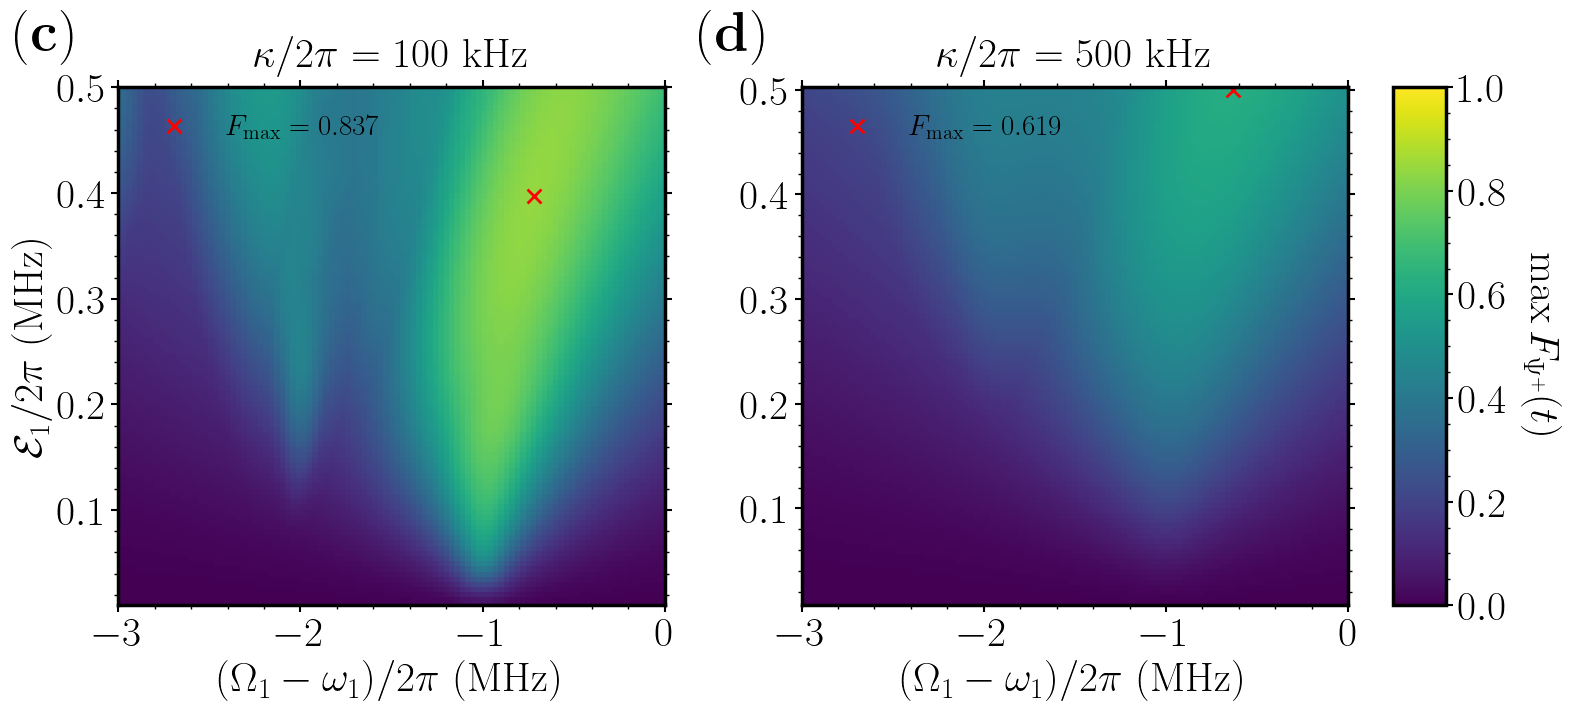

In [271]:
# load data with losses
# BellState_[2026-08-12]_[03h19m].npy --> kappa = 100 kHz
data_6_lossless = load(r'Results\Sim6_BellState_E_vs_Delta\BellState_[2026-08-12]_[13h29m].npy',
                  allow_pickle=True)

# loads data with losses
# BellState_[2026-08-12]_[11h13m].npy --> kappa = 500 kHz
data_6_lossy = load(r'Results\Sim6_BellState_E_vs_Delta\BellState_[2026-08-12]_[11h13m].npy',
                  allow_pickle=True)
#######
Fmax_grid_lossless  = data_6_lossless[2]
tBell_grid_lossless = data_6_lossless[3]

leakage_grid_lossless = data_6_lossless[4]
HZ_grid_lossless      = data_6_lossless[5]

P11_grid_lossless = data_6_lossless[6]
P20_grid_lossless = data_6_lossless[7]
P02_grid_lossless = data_6_lossless[8]

best_trajectory = data_6_lossless[9]
#######
Fmax_grid_lossy  = data_6_lossy[2]
tBell_grid_lossy = data_6_lossy[3]

leakage_grid_lossy = data_6_lossy[4]
HZ_grid_lossy      = data_6_lossy[5]

P11_grid_lossy = data_6_lossy[6]
P20_grid_lossy = data_6_lossy[7]
P02_grid_lossy = data_6_lossy[8]

best_trajectory = data_6_lossy[9]
#====================================
# Finds the best point 
k_best_lossless = unravel_index(argmax(Fmax_grid_lossless),Fmax_grid_lossless.shape)
k_best_lossy = unravel_index(argmax(Fmax_grid_lossy),Fmax_grid_lossy.shape)

E_best_lossless     = E_list[k_best_lossless[0]]
delta_best_lossless = delta_list[k_best_lossless[1]]
F_best_lossless = Fmax_grid_lossless[k_best_lossless]

E_best_lossy     = E_list[k_best_lossy[0]]
delta_best_lossy = delta_list[k_best_lossy[1]]
F_best_lossy = Fmax_grid_lossy[k_best_lossy]
#====================================
# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

im0 = axes[0].pcolormesh(delta_list, E_list, Fmax_grid_lossless,
                         shading="auto", cmap="viridis", vmin=0, vmax=1)

im1 = axes[1].pcolormesh(delta_list, E_list, Fmax_grid_lossy,
                         shading="auto", cmap="viridis", vmin=0, vmax=1)

axes[0].scatter(delta_best_lossless, E_best_lossless, marker="x", s=100, color="red", linewidth=2, label=rf"$F_{{\max}}={F_best_lossless:.3f}$")
axes[1].scatter(delta_best_lossy, E_best_lossy, marker="x", s=100, color="red", linewidth=2, label=rf"$F_{{\max}}={F_best_lossy:.3f}$")

##############################################################
# Labels and style
##############################################################
axes[0].set_title(rf"$\kappa/2\pi = 100$ kHz", pad = 15)
axes[1].set_title(rf"$\kappa/2\pi = 500$ kHz", pad = 15)

for ax in axes:
    ax.set_xlabel(r"$(\Omega_1 - \omega_1)/2\pi$ (MHz)")
    ax.set_xlim(delta_list[0], delta_list[-1])

    ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

    ax.tick_params(axis='both', which='both', direction='out')

    ax.legend(fontsize=21, loc='upper left')

axes[0].set_ylabel(r"$\mathcal{E}_1/2\pi$ (MHz)")
axes[0].set_ylim(E_list[0], E_list[-1])

##############################################################
# One shared colorbar for all three plots
##############################################################
cax = fig.add_axes([0.93, 0.14, 0.035, 0.74])
#                 [left, bottom, width, height]

cbar = fig.colorbar(
    im1,
    cax=cax,
    orientation='vertical'
)

cbar.set_label(r"$\max F_{\Psi^+}(t)$", rotation=270, labelpad=40)
cbar.ax.tick_params(which='both', direction='out')
#############################################################
# Panel labels
#############################################################
panel_labels = [r'$\mathbf{(c)}$',r'$\mathbf{(d)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.19,
        1.15,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )
##############################################################
# Global spacing
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.90,
    bottom=0.14,
    top=0.88,
    wspace=0.25
)
##############################################################
# Save figure
##############################################################
save_figure(fig, "Thesis_Figures", "chap4_Bell_state_fidelity_part2", formats=["pdf"], time_stamp=False, dpi=300) 

plt.show()

### End